In [1]:
%pip install numpy matplotlib
%pip install pandas
%pip install joblib
from collections import defaultdict
from typing import Dict, List, Tuple
from joblib import Parallel, delayed

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Задача контроля очереди

Рассматривается система обслуживания с очередью конечной ёмкости.  
На каждом шаге выбирается режим обслуживания, после чего происходит случайное обслуживание заявок и случайный приход новых.

## Постановка задачи

Состояние системы на шаге $t$ — длина очереди:
$$
s_t \in \mathcal{S} = \{0,1,\dots,N\},
$$
где $N$ — максимальная длина очереди.

На каждом шаге выбирается действие:
$$
a_t \in \mathcal{A} = \{\text{off}, \text{norm}, \text{fast}\},
$$
где:
- `off` — не обслуживать;
- `norm` — обычный режим;
- `fast` — ускоренный режим.

### Случайный приход заявок

Пусть за шаг может прийти либо 0, либо 1 заявка:
$$
X_t \in \{0,1\}, \qquad
\mathbb{P}(X_t=1)=\lambda, \qquad
\mathbb{P}(X_t=0)=1-\lambda.
$$

### Случайное обслуживание

Число заявок, которое сервер пытается обслужить за шаг, обозначим через $Y_t$.

Для разных режимов:
$$
Y_t =
\begin{cases}
0, & a_t=\text{off},\\
0 \text{ или } 1, & a_t=\text{norm},\\
0,1 \text{ или } 2, & a_t=\text{fast}.
\end{cases}
$$

При этом фактически обслуживается не больше заявок, чем есть в очереди:
$$
\min(s_t, Y_t).
$$

### Динамика очереди

Предполагается порядок событий:
$$
\text{обслуживание} \rightarrow \text{приход}.
$$

Тогда следующее состояние задаётся формулой:
$$
s_{t+1} = \min\bigl(N,\ s_t - \min(s_t,Y_t) + X_t \bigr).
$$

### Функция награды

Награда задаётся как отрицательный штраф:
$$
R(s,a) = -\alpha s - c(a),
$$
где:
- $\alpha > 0$ — штраф за длину очереди;
- $c(a)$ — стоимость выбранного режима обслуживания.

Например:
$$
c(\text{off}) = 0, \qquad
c(\text{norm}) = c_n, \qquad
c(\text{fast}) = c_f, \qquad c_f > c_n > 0.
$$

### Цель оптимизации

Требуется найти политику $\pi$, максимизирующую ожидаемую суммарную дисконтированную награду:
$$
J(\pi)=\mathbb{E}_\pi\left[\sum_{t=0}^{\infty}\gamma^t r(s_t,a_t)\right], \qquad 0<\gamma<1.
$$

## Задание параметров модели

На этом шаге фиксируются все основные параметры MDP:
- максимальная длина очереди;
- коэффициент дисконтирования;
- вероятности прихода и обслуживания;
- штрафы за длину очереди и стоимость режимов.

In [2]:
N = 50
gamma = 0.7

lambda_arrival = 0.8

mu = 0.7

p_fast_0 = 0.1
p_fast_1 = 0.3
p_fast_2 = 0.6

alpha = 1.0
c_off = 0.0
c_norm = 0.5
c_fast = 1.5

tol = 1e-6
max_iters = 1000

## Пространства состояний и действий

Состояния кодируются целыми числами от $0$ до $N$, где число означает текущую длину очереди.  
Действия задаются строковыми обозначениями режимов обслуживания.

In [3]:
State = int
Action = str

S: List[State] = list(range(N + 1))
A: List[Action] = ["off", "norm", "fast"]

## Распределения случайных величин

Для построения таблицы переходов отдельно задаются:
- распределение прихода новых заявок;
- распределение числа заявок, которое сервер пытается обслужить, для каждого режима.

In [4]:
arrival_probs = {
    0: 1 - lambda_arrival,
    1: lambda_arrival
}

service_probs = {
    "off": {0: 1.0},
    "norm": {0: 1 - mu, 1: mu},
    "fast": {0: p_fast_0, 1: p_fast_1, 2: p_fast_2}
}

## Построение таблицы переходов

Для каждой пары $(s,a)$ перебираются все возможные значения:
- прихода $X_t$;
- обслуживания $Y_t$.

После этого вычисляется новое состояние:
$$
s' = \min(N,\ s-\min(s,y)+x).
$$

Если в одно и то же состояние можно попасть разными способами, их вероятности суммируются.

Награда зависит от текущей длины очереди и выбранного режима обслуживания:
$$
R(s,a) = -\alpha s - c(a).
$$

In [5]:
P: Dict[Tuple[State, Action], List[Tuple[State, float]]] = {}

for s in S:
    for a in A:
        next_state_probs = defaultdict(float)

        for y, py in service_probs[a].items():
            for x, px in arrival_probs.items():
                served = min(s, y)
                s_next = min(N, s - served + x)
                next_state_probs[s_next] += py * px

        P[(s, a)] = list(next_state_probs.items())


for key, rows in P.items():
    total = sum(p for _, p in rows)
    if abs(total - 1.0) > 1e-9:
        raise ValueError(f"Probabilities for {key} sum to {total}, not 1.")
    

def R(s: State, a: Action) -> float:
    cost = {
        "off": c_off,
        "norm": c_norm,
        "fast": c_fast,
    }
    return -alpha * s - cost[a]

print(f"{'s':>2} | {'a':>4} | {'s_next':>6} | {'prob':>6} | {'R':>7}")
print("-" * 40)

for s in S:
    for a in A:
        for s_next, prob in sorted(P[(s, a)]):
            print(f"{s:2d} | {a:>4s} | {s_next:6d} | {prob:6.2f} | {R(s, a):7.2f}")

 s |    a | s_next |   prob |       R
----------------------------------------
 0 |  off |      0 |   0.20 |   -0.00
 0 |  off |      1 |   0.80 |   -0.00
 0 | norm |      0 |   0.20 |   -0.50
 0 | norm |      1 |   0.80 |   -0.50
 0 | fast |      0 |   0.20 |   -1.50
 0 | fast |      1 |   0.80 |   -1.50
 1 |  off |      1 |   0.20 |   -1.00
 1 |  off |      2 |   0.80 |   -1.00
 1 | norm |      0 |   0.14 |   -1.50
 1 | norm |      1 |   0.62 |   -1.50
 1 | norm |      2 |   0.24 |   -1.50
 1 | fast |      0 |   0.18 |   -2.50
 1 | fast |      1 |   0.74 |   -2.50
 1 | fast |      2 |   0.08 |   -2.50
 2 |  off |      2 |   0.20 |   -2.00
 2 |  off |      3 |   0.80 |   -2.00
 2 | norm |      1 |   0.14 |   -2.50
 2 | norm |      2 |   0.62 |   -2.50
 2 | norm |      3 |   0.24 |   -2.50
 2 | fast |      0 |   0.12 |   -3.50
 2 | fast |      1 |   0.54 |   -3.50
 2 | fast |      2 |   0.26 |   -3.50
 2 | fast |      3 |   0.08 |   -3.50
 3 |  off |      3 |   0.20 |   -3.00
 3 |  off

## Алгоритм Value Iteration

Алгоритм Value Iteration основан на уравнении оптимальности Беллмана:
$$
V_{k+1}(s)=\max_{a\in\mathcal{A}}
\left(
R(s,a)+\gamma \sum_{s'} P(s'|s,a)V_k(s')
\right).
$$

На каждом шаге для каждого состояния выбирается действие, дающее максимальную ожидаемую ценность.


После сходимости алгоритма Value Iteration оптимальная политика извлекается из найденной оптимальной функции ценности \(V*\) по формуле:
$$
\pi^*(s)=\arg\max_{a\in\mathcal{A}}
\left(
R(s,a)+\gamma\sum_{s'} P(s'|s,a)\,V^*(s')
\right).
$$

In [6]:
def value_iteration():
    V: Dict[State, float] = {s: 0.0 for s in S}

    for k in range(max_iters):
        V_new: Dict[State, float] = {}

        for s in S:
            q_best = -np.inf

            for a in A:
                exp_next = sum(prob * V[s_next] for s_next, prob in P[(s, a)])
                q_sa = R(s, a) + gamma * exp_next

                if q_sa > q_best:
                    q_best = q_sa

            V_new[s] = q_best

        delta = max(abs(V_new[s] - V[s]) for s in S)
        V = V_new

        if delta < tol:
            print(f"Value iteration converged in {k+1} iterations.")
            break

    PI: Dict[State, Action] = {}

    for s in S:
        best_a = max(
            A,
            key=lambda a: R(s, a) + gamma * sum(prob * V[s_next] for s_next, prob in P[(s, a)])
        )
        PI[s] = best_a

    return V, PI


V_vi, PI_vi = value_iteration()


print("Optimal values:")
for s in S:
    print(f"s = {s}, V*(s) = {V_vi[s]:.6f}")

print("\nOptimal policy:")
for s in S:
    print(f"s = {s}, pi*(s) = {PI_vi[s]}")

Value iteration converged in 49 iterations.
Optimal values:
s = 0, V*(s) = -3.689862
s = 1, V*(s) = -5.666574
s = 2, V*(s) = -8.009968
s = 3, V*(s) = -10.718573
s = 4, V*(s) = -13.643442
s = 5, V*(s) = -16.712102
s = 6, V*(s) = -19.873547
s = 7, V*(s) = -23.095312
s = 8, V*(s) = -26.356220
s = 9, V*(s) = -29.642539
s = 10, V*(s) = -32.945354
s = 11, V*(s) = -36.258876
s = 12, V*(s) = -39.579349
s = 13, V*(s) = -42.904334
s = 14, V*(s) = -46.232248
s = 15, V*(s) = -49.562064
s = 16, V*(s) = -52.893114
s = 17, V*(s) = -56.224965
s = 18, V*(s) = -59.557336
s = 19, V*(s) = -62.890044
s = 20, V*(s) = -66.222972
s = 21, V*(s) = -69.556042
s = 22, V*(s) = -72.889205
s = 23, V*(s) = -76.222427
s = 24, V*(s) = -79.555689
s = 25, V*(s) = -82.888975
s = 26, V*(s) = -86.222278
s = 27, V*(s) = -89.555592
s = 28, V*(s) = -92.888912
s = 29, V*(s) = -96.222237
s = 30, V*(s) = -99.555565
s = 31, V*(s) = -102.888895
s = 32, V*(s) = -106.222226
s = 33, V*(s) = -109.555558
s = 34, V*(s) = -112.888890
s = 

## Алгоритм Policy Iteration

Алгоритм Policy Iteration состоит из двух шагов:

1. **Policy Evaluation** — вычисление функции ценности для фиксированной политики:
$$
V^\pi(s)=R(s,\pi(s))+\gamma \sum_{s'} P(s'|s,\pi(s))V^\pi(s').
$$

2. **Policy Improvement** — построение новой жадной политики:
$$
\pi_{\text{new}}(s)=\arg\max_a
\left(
R(s,a)+\gamma \sum_{s'}P(s'|s,a)V^\pi(s')
\right).
$$

Итерации продолжаются, пока политика не перестанет изменяться.

In [7]:
def policy_evaluation(PI: Dict[State, Action]) -> Dict[State, float]:
    V: Dict[State, float] = {s: 0.0 for s in S}

    for k in range(max_iters):
        V_new: Dict[State, float] = {}

        for s in S:
            a = PI[s]
            exp_next = sum(prob * V[s_next] for s_next, prob in P[(s, a)])
            V_new[s] = R(s, a) + gamma * exp_next

        delta = max(abs(V_new[s] - V[s]) for s in S)
        V = V_new

        if delta < tol:
            break

    return V


def policy_improvement(V: Dict[State, float], PI_old: Dict[State, Action]):
    PI_new: Dict[State, Action] = {}
    stable = True

    for s in S:
        best_a = max(
            A,
            key=lambda a: R(s, a) + gamma * sum(prob * V[s_next] for s_next, prob in P[(s, a)])
        )
        PI_new[s] = best_a

        if best_a != PI_old[s]:
            stable = False

    return PI_new, stable


def policy_iteration():
    PI: Dict[State, Action] = {s: "off" for s in S}

    for it in range(max_iters):
        V = policy_evaluation(PI)
        PI_new, stable = policy_improvement(V, PI)

        print(f"Policy iteration step {it+1}: policy changed = {not stable}")

        PI = PI_new

        if stable:
            print(f"Policy iteration converged in {it+1} iterations.")
            break

    return V, PI


V_pi, PI_pi = policy_iteration()


print("Policy iteration values:")
for s in S:
    print(f"s = {s}, V(s) = {V_pi[s]:.6f}")

print("\nPolicy iteration policy:")
for s in S:
    print(f"s = {s}, pi(s) = {PI_pi[s]}")

Policy iteration step 1: policy changed = True
Policy iteration step 2: policy changed = True
Policy iteration step 3: policy changed = False
Policy iteration converged in 3 iterations.
Policy iteration values:
s = 0, V(s) = -3.689862
s = 1, V(s) = -5.666574
s = 2, V(s) = -8.009968
s = 3, V(s) = -10.718573
s = 4, V(s) = -13.643442
s = 5, V(s) = -16.712102
s = 6, V(s) = -19.873547
s = 7, V(s) = -23.095312
s = 8, V(s) = -26.356220
s = 9, V(s) = -29.642539
s = 10, V(s) = -32.945354
s = 11, V(s) = -36.258876
s = 12, V(s) = -39.579349
s = 13, V(s) = -42.904334
s = 14, V(s) = -46.232248
s = 15, V(s) = -49.562064
s = 16, V(s) = -52.893114
s = 17, V(s) = -56.224965
s = 18, V(s) = -59.557336
s = 19, V(s) = -62.890044
s = 20, V(s) = -66.222972
s = 21, V(s) = -69.556042
s = 22, V(s) = -72.889205
s = 23, V(s) = -76.222427
s = 24, V(s) = -79.555689
s = 25, V(s) = -82.888975
s = 26, V(s) = -86.222278
s = 27, V(s) = -89.555592
s = 28, V(s) = -92.888912
s = 29, V(s) = -96.222237
s = 30, V(s) = -99.555

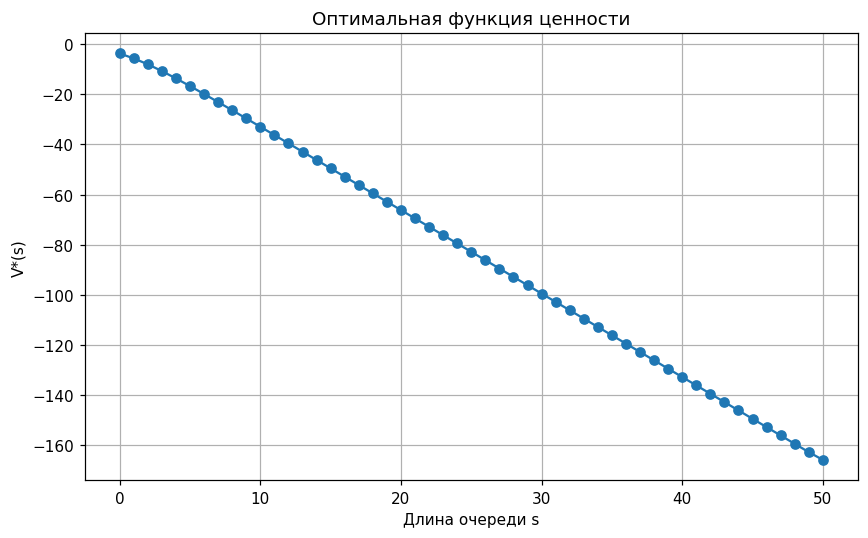

In [8]:
plt.figure(figsize=(8, 5), dpi=110)
plt.plot(S, [V_vi[s] for s in S], marker="o")
plt.xlabel("Длина очереди s")
plt.ylabel("V*(s)")
plt.title("Оптимальная функция ценности")
plt.grid(True)
plt.tight_layout()
plt.show()

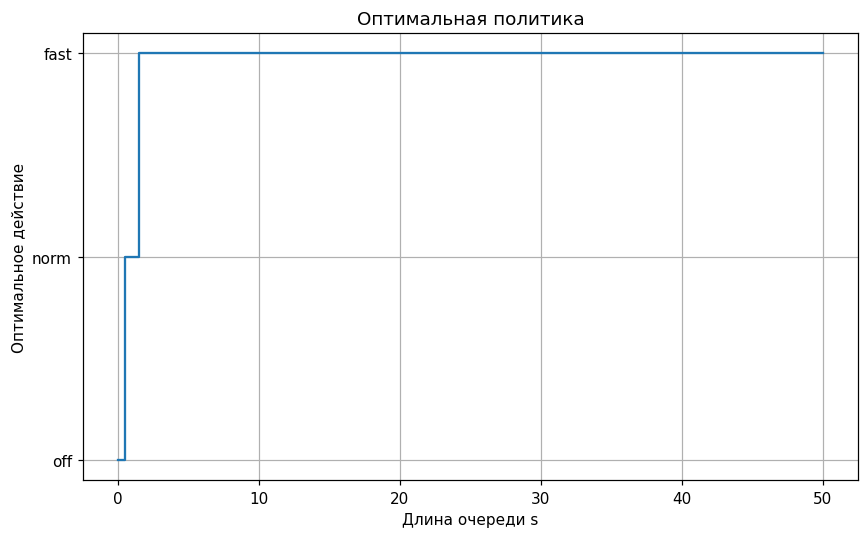

In [9]:
action_to_num = {"off": 0, "norm": 1, "fast": 2}
policy_numeric = [action_to_num[PI_vi[s]] for s in S]

plt.figure(figsize=(8, 5), dpi=110)
plt.step(S, policy_numeric, where="mid")
plt.yticks([0, 1, 2], ["off", "norm", "fast"])
plt.xlabel("Длина очереди s")
plt.ylabel("Оптимальное действие")
plt.title("Оптимальная политика")
plt.grid(True)
plt.tight_layout()
plt.show()

## Чёрный ящик

До этого момента задача решалась методами динамического программирования.  
Эти методы используют полную модель среды, то есть таблицу переходов

$$
P(s'|s,a).
$$

Однако методы Монте-Карло, временных разностей, SARSA и Q-обучения не должны напрямую использовать вероятности переходов.  
Они взаимодействуют со средой как с чёрным ящиком:

$$
s_t,\ a_t \longrightarrow r_{t+1},\ s_{t+1}.
$$

То есть алгоритм знает только текущее состояние, выбирает действие, а затем получает от среды новое состояние и вознаграждение.

Внутри среды по-прежнему используется та же динамика очереди:

$$
s_{t+1} = \min\bigl(N,\ s_t - \min(s_t,Y_t) + X_t\bigr),
$$

где сначала происходит обслуживание, а затем приход новой заявки.

При одинаковых значениях \(s_t\) и \(a_t\) среда может вернуть разные следующие состояния, поскольку приход заявок и обслуживание являются случайными.

Важное отличие от динамического программирования состоит в том, что теперь алгоритм не перебирает все возможные следующие состояния и не использует таблицу \(P(s'|s,a)\).  
Вероятностная модель используется только внутри среды для генерации одного случайного перехода, но не передается обучающему алгоритму.

In [10]:
class QueueControlEnv:
    def __init__(
        self,
        n: int,
        states: List[State],
        actions: List[Action],
        arrival_probs: Dict[int, float],
        service_probs: Dict[Action, Dict[int, float]],
        reward_func,
        max_steps: int = 100,
        start_state: State = 0,
        random_seed: int | None = None,
    ):
        self.n = n
        self.states = states
        self.actions = actions
        self.arrival_probs = arrival_probs
        self.service_probs = service_probs
        self.reward_func = reward_func
        self.max_steps = max_steps
        self.start_state = start_state

        self.rng = np.random.default_rng(random_seed)

        self.state = start_state
        self.step_count = 0

    def reset(
        self,
        start_state: State | None = None,
        random_start: bool = False,
    ) -> State:
        if random_start:
            self.state = int(self.rng.choice(self.states))
        elif start_state is None:
            self.state = self.start_state
        else:
            if start_state not in self.states:
                raise ValueError(
                    f"Недопустимое начальное состояние: {start_state}"
                )
            self.state = start_state

        self.step_count = 0
        return self.state

    def sample_from_distribution(self, probs: Dict[int, float]) -> int:
        values = list(probs.keys())
        probabilities = list(probs.values())

        if not np.isclose(sum(probabilities), 1.0):
            raise ValueError("Сумма вероятностей должна быть равна 1")

        return int(self.rng.choice(values, p=probabilities))

    def step(self, action: Action) -> Tuple[State, float, bool]:
        if action not in self.actions:
            raise ValueError(f"Недопустимое действие: {action}")

        current_state = self.state

        service = self.sample_from_distribution(
            self.service_probs[action]
        )
        arrival = self.sample_from_distribution(self.arrival_probs)

        served = min(current_state, service)
        next_state = min(self.n, current_state - served + arrival)

        reward = self.reward_func(current_state, action)

        self.state = next_state
        self.step_count += 1

        done = self.step_count >= self.max_steps

        return next_state, reward, done

In [11]:
env = QueueControlEnv(
    n=N,
    states=S,
    actions=A,
    arrival_probs=arrival_probs,
    service_probs=service_probs,
    reward_func=R,
    max_steps=100,
    start_state=0,
    random_seed=42,
)

In [12]:
state = env.reset(start_state=4)
action = "fast"

next_state, reward, done = env.step(action)

print("Текущее состояние:", state)
print("Действие:", action)
print("Следующее состояние:", next_state)
print("Награда:", reward)
print("Эпизод завершён:", done)

Текущее состояние: 4
Действие: fast
Следующее состояние: 3
Награда: -5.5
Эпизод завершён: False


## Генерация эпизодов

После того как модель очереди была оформлена как среда, можно генерировать траектории взаимодействия агента со средой.

Один эпизод представляет собой последовательность переходов:

$$
(s_0, a_0, r_0, s_1),\ 
(s_1, a_1, r_1, s_2),\ 
\dots
$$

Здесь:

- $s_t$ — состояние очереди на шаге $t$;
- $a_t$ — выбранное действие;
- $r_t$ — полученная награда;
- $s_{t+1}$ — следующее состояние.

In [13]:
def generate_episode(
    env,
    policy,
    start_state=None,
    random_start=False,
):
    episode = []

    state = env.reset(
        start_state=start_state,
        random_start=random_start,
    )
    done = False

    while not done:
        action = policy(state)
        next_state, reward, done = env.step(action)

        episode.append((state, action, reward, next_state))

        state = next_state

    return episode

In [14]:
rng = np.random.default_rng(42)


def random_policy(state):
    return rng.choice(A)


episode = generate_episode(env, random_policy)

for transition in episode[:10]:
    print(transition)

(0, np.str_('off'), -0.0, 1)
(1, np.str_('fast'), -2.5, 2)
(2, np.str_('norm'), -2.5, 2)
(2, np.str_('norm'), -2.5, 3)
(3, np.str_('norm'), -3.5, 3)
(3, np.str_('fast'), -4.5, 2)
(2, np.str_('off'), -2.0, 3)
(3, np.str_('fast'), -4.5, 1)
(1, np.str_('off'), -1.0, 2)
(2, np.str_('off'), -2.0, 3)


## Вспомогательные функции для выбора действий и сравнения политик

Дальше будем реализовывать методы обучения с подкреплением, которые работают не с таблицей переходов \(P(s'|s,a)\), а с опытом взаимодействия со средой.

Основной объект, который будут обучать эти методы, — это функция качества действия:

$$
Q(s,a).
$$

Значение \(Q(s,a)\) показывает, насколько выгодно выбрать действие \(a\) в состоянии \(s\), если дальше действовать согласно некоторой политике.

По таблице \(Q\) можно выбирать действие жадно:

$$
a \in \arg\max_{b\in A} Q(s,b).
$$

Однако полностью жадный выбор не всегда хорош. В начале обучения значения \(Q(s,a)\) ещё неточные, поэтому агент может слишком рано начать выбирать неудачное действие и перестать исследовать остальные.

Также добавим функции для построения жадной политики по таблице \(Q\), сравнения двух политик и подсчёта дисконтированной награды эпизода.

Для сравнения качества обученных методов с оптимальным решением будем использовать две метрики: отклонение функции ценности от оптимальной и совпадение найденной стратегии с эталонной.

Основной метрикой будем считать сумму квадратов отклонений найденной функции ценности от оптимальной:

$$
\mathrm{SSE}_V =
\sum_{s\in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

Здесь \(V*(s)\) — оптимальная функция ценности, найденная методом Value Iteration, а $V_{\mathrm{MC}}(s)$ — функция ценности, восстановленная по оценкам метода Монте-Карло.

Поскольку методы Монте-Карло в работе обучают функцию качества действия \(Q(s,a)\), после обучения по ней строится жадная стратегия

$$
\pi_Q(s)\in \arg\max_{a\in A} Q(s,a).
$$

Функцию ценности, соответствующую найденной таблице \(Q\), будем восстанавливать как

$$
V_{\mathrm{MC}}(s)=Q(s,\pi_Q(s))=\max_{a\in A}Q(s,a).
$$

Чем меньше значение $\mathrm{SSE}_V$, тем ближе найденная функция ценности к оптимальной. В дальнейшем именно эта величина используется как основная метрика качества обучения.

При этом прежняя метрика совпадения стратегий не исключается из анализа. Она показывает долю состояний, в которых найденная стратегия совпадает с эталонной:

$$
\mathrm{strategy\_match}
=
\frac{1}{|S|}
\sum_{s\in S}
\mathbf{1}\{\pi_Q(s)=\pi_*(s)\}.
$$

Эта метрика используется как дополнительная: она позволяет понять, насколько близки сами управляющие решения, но не отражает величину ошибки в оценках функции ценности.

In [15]:
def choose_random_action(actions, rng):
    return str(rng.choice(actions))


def choose_greedy_action(Q, state, actions, rng):
    q_values = [Q[(state, action)] for action in actions]
    max_q = max(q_values)

    best_actions = [
        action
        for action in actions
        if Q[(state, action)] == max_q
    ]

    return str(rng.choice(best_actions))


def choose_greedy_action_deterministic(Q, state, actions):
    q_values = [Q[(state, action)] for action in actions]
    max_q = max(q_values)

    for action in actions:
        if Q[(state, action)] == max_q:
            return action


def choose_epsilon_greedy_action(Q, state, actions, epsilon, rng):
    if rng.random() < epsilon:
        return choose_random_action(actions, rng)

    return choose_greedy_action(Q, state, actions, rng)


def build_greedy_policy(Q, states, actions):
    policy = {}

    for state in states:
        policy[state] = choose_greedy_action_deterministic(
            Q,
            state,
            actions,
        )

    return policy


def policy_match_ratio(policy_a, policy_b, states):
    matches = 0

    for state in states:
        if policy_a[state] == policy_b[state]:
            matches += 1

    return matches / len(states)


def q_to_value(Q, states, actions):
    V = {}

    for state in states:
        V[state] = max(
            Q[(state, action)]
            for action in actions
        )

    return V


def value_sse(V_est, V_ref, states):
    error_sum = 0.0

    for state in states:
        error = V_est[state] - V_ref[state]
        error_sum += error ** 2

    return float(error_sum)


def discounted_episode_return(episode, gamma):
    total_return = 0.0
    discount = 1.0

    for _, _, reward, _ in episode:
        total_return += discount * reward
        discount *= gamma

    return total_return

In [16]:
rng = np.random.default_rng()
Q_test = defaultdict(float)

state = 5

print("Случайное действие:")
print(choose_random_action(A, rng))

print("\nЖадное действие при нулевых Q:")
print(choose_greedy_action(Q_test, state, A, rng))

print("\nДетерминированное жадное действие при нулевых Q:")
print(choose_greedy_action_deterministic(Q_test, state, A))

print("\nε-жадное действие:")
print(choose_epsilon_greedy_action(Q_test, state, A, 0.1, rng))

Случайное действие:
off

Жадное действие при нулевых Q:
fast

Детерминированное жадное действие при нулевых Q:
off

ε-жадное действие:
fast


## Монте-Карло с исследовательскими стартами

Первый метод обучения без использования модели среды — метод Монте-Карло с исследовательскими стартами.

Идея метода Монте-Карло состоит в том, чтобы оценивать качество действий по завершённым эпизодам.  
После генерации эпизода мы знаем последовательность наград и можем посчитать доход с каждого момента времени:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots
$$

Затем значение $Q(s_t,a_t)$ обновляется в сторону полученного дохода:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left(
G_t - Q(s_t,a_t)
\right).
$$

Здесь:

- $Q(s,a)$ — текущая оценка качества действия $a$ в состоянии $s$;
- $G_t$ — фактический дисконтированный доход, полученный после выбора этого действия;
- $\alpha$ — скорость обучения.

Особенность метода с исследовательскими стартами состоит в том, что каждый эпизод начинается со случайной пары $(s_0,a_0)$.  
Это нужно, чтобы алгоритм мог получить опыт для разных пар состояние–действие.

После первого действия агент дальше действует по текущей жадной политике:

$$
\pi(s)\in\arg\max_{a\in A} Q(s,a).
$$

В нашей задаче это удобно реализовать, потому что у нас есть симулятор среды, и мы можем искусственно начинать эпизод из любого состояния очереди.

In [17]:
def monte_carlo_exploring_starts(
    env,
    states,
    actions,
    num_episodes,
    alpha_lr,
    gamma,
    random_seed=None,
):
    rng = np.random.default_rng(random_seed)

    Q = defaultdict(float)
    returns_history = []

    for _ in range(num_episodes):
        episode = []

        start_state = int(rng.choice(states))
        first_action = str(rng.choice(actions))

        state = env.reset(start_state=start_state)
        next_state, reward, done = env.step(first_action)

        episode.append((state, first_action, reward, next_state))

        state = next_state

        while not done:
            action = choose_greedy_action(Q, state, actions, rng)
            next_state, reward, done = env.step(action)

            episode.append((state, action, reward, next_state))

            state = next_state

        G = 0.0

        for state, action, reward, _ in reversed(episode):
            G = reward + gamma * G

            Q[(state, action)] += alpha_lr * (
                G - Q[(state, action)]
            )

        returns_history.append(discounted_episode_return(episode, gamma))

    policy = build_greedy_policy(Q, states, actions)

    return Q, policy, returns_history

In [23]:
env_mc_es = QueueControlEnv(
    n=N,
    states=S,
    actions=A,
    arrival_probs=arrival_probs,
    service_probs=service_probs,
    reward_func=R,
    max_steps=100,
    start_state=0,
    random_seed=42,
)

Q_mc_es, PI_mc_es, returns_mc_es = monte_carlo_exploring_starts(
    env=env_mc_es,
    states=S,
    actions=A,
    num_episodes=4000,
    alpha_lr=0.05,
    gamma=gamma,
    random_seed=42,
)

V_mc_es = q_to_value(Q_mc_es, S, A)
sse_mc_es = value_sse(V_mc_es, V_vi, S)
match_mc_es = policy_match_ratio(PI_mc_es, PI_vi, S)

print("Политика Монте-Карло с исследовательскими стартами:")
for state in S:
    print(f"s = {state}, pi(s) = {PI_mc_es[state]}")

print(
    "\nSSE функции ценности относительно Value Iteration:",
    sse_mc_es,
)

print(
    "Совпадение с политикой из Value Iteration:",
    match_mc_es,
)

Политика Монте-Карло с исследовательскими стартами:
s = 0, pi(s) = off
s = 1, pi(s) = norm
s = 2, pi(s) = fast
s = 3, pi(s) = fast
s = 4, pi(s) = fast
s = 5, pi(s) = fast
s = 6, pi(s) = fast
s = 7, pi(s) = fast
s = 8, pi(s) = fast
s = 9, pi(s) = fast
s = 10, pi(s) = fast
s = 11, pi(s) = fast
s = 12, pi(s) = fast
s = 13, pi(s) = fast
s = 14, pi(s) = fast
s = 15, pi(s) = fast
s = 16, pi(s) = fast
s = 17, pi(s) = fast
s = 18, pi(s) = fast
s = 19, pi(s) = fast
s = 20, pi(s) = fast
s = 21, pi(s) = fast
s = 22, pi(s) = fast
s = 23, pi(s) = fast
s = 24, pi(s) = fast
s = 25, pi(s) = fast
s = 26, pi(s) = fast
s = 27, pi(s) = fast
s = 28, pi(s) = fast
s = 29, pi(s) = fast
s = 30, pi(s) = fast
s = 31, pi(s) = fast
s = 32, pi(s) = fast
s = 33, pi(s) = fast
s = 34, pi(s) = fast
s = 35, pi(s) = fast
s = 36, pi(s) = fast
s = 37, pi(s) = fast
s = 38, pi(s) = fast
s = 39, pi(s) = fast
s = 40, pi(s) = fast
s = 41, pi(s) = fast
s = 42, pi(s) = fast
s = 43, pi(s) = fast
s = 44, pi(s) = fast
s = 45, pi(s) 

### Исследование влияния параметров метода

После базового запуска метода Монте-Карло с исследовательскими стартами видно, что качество итогового результата зависит от выбранных параметров обучения. Поэтому дальше проводится небольшое численное исследование.

Для метода будем менять параметры:

- `num_episodes` — количество обучающих эпизодов;
- `alpha_lr` — шаг обучения;
- `max_steps` — максимальная длина одного эпизода.

Качество не будем оценивать только по награде отдельных обучающих эпизодов, потому что она сильно зашумлена из-за случайности среды и зависит от начального состояния эпизода. Вместо этого будем сравнивать результат обучения с эталонным решением, полученным методом Value Iteration.

Основной метрикой качества является отклонение найденной функции ценности от оптимальной функции ценности.

Так как метод Монте-Карло обучает функцию качества действия $Q(s,a)$, восстановим функцию ценности состояния по формуле

$$
V_{\mathrm{MC}}(s)=\max_{a\in A} Q_{\mathrm{MC}}(s,a).
$$

После этого ошибка считается как

$$
\mathrm{SSE}_V =
\sum_{s\in S}
\left(
V_{\mathrm{MC}}(s)-V_*(s)
\right)^2.
$$

Чем меньше значение $\mathrm{SSE}_V$, тем ближе найденная функция ценности к оптимальной.

Дополнительно будем использовать метрику совпадения стратегий:

$$
\mathrm{policy\_match}
=
\frac{
\#\{s:\pi_{\mathrm{MC}}(s)=\pi_{\mathrm{VI}}(s)\}
}{
|S|
}.
$$

Эта величина показывает долю состояний, в которых политика, найденная методом Монте-Карло, совпадает с эталонной политикой, полученной методом Value Iteration. В отличие от $\mathrm{SSE}_V$, она учитывает только выбранные действия, но не показывает величину ошибки в оценках функции ценности.

Кроме качества будем измерять время обучения. Это важно, потому что увеличение числа эпизодов или длины эпизода может улучшать результат, но одновременно увеличивает вычислительные затраты.

Так как в методе есть случайность, каждый набор параметров будем запускать несколько раз с разными `random_seed`, а затем усреднять результаты.

In [19]:
def create_env(random_seed=42, max_steps=100):
    return QueueControlEnv(
        n=N,
        states=S,
        actions=A,
        arrival_probs=arrival_probs,
        service_probs=service_probs,
        reward_func=R,
        max_steps=max_steps,
        start_state=0,
        random_seed=random_seed,
    )



def run_mc_es_once_light(
    num_episodes,
    alpha_lr,
    gamma,
    max_steps=100,
    random_seed=42,
):
    env_train = create_env(
        random_seed=random_seed,
        max_steps=max_steps,
    )

    start_time = time.perf_counter()

    Q_mc_es, PI_mc_es, _ = monte_carlo_exploring_starts(
        env=env_train,
        states=S,
        actions=A,
        num_episodes=num_episodes,
        alpha_lr=alpha_lr,
        gamma=gamma,
        random_seed=random_seed,
    )

    training_time = time.perf_counter() - start_time
    policy_match = policy_match_ratio(PI_mc_es, PI_vi, S)
    V_mc_es = q_to_value(Q_mc_es, S, A)
    value_error_sse = value_sse(V_mc_es, V_vi, S)

    return {
        "num_episodes": num_episodes,
        "alpha_lr": alpha_lr,
        "max_steps": max_steps,
        "seed": random_seed,
        "policy_match": policy_match,
        "training_time": training_time,
        "value_sse": value_error_sse,
    }

In [20]:
result_mc_es = run_mc_es_once_light(
    num_episodes=4000,
    alpha_lr=0.05,
    gamma=gamma,
    max_steps=100,
    random_seed=42,
)

print("SSE функции ценности:", result_mc_es["value_sse"])
print("Совпадение с Value Iteration:", result_mc_es["policy_match"])
print("Время обучения:", result_mc_es["training_time"])

SSE функции ценности: 13.092609527743878
Совпадение с Value Iteration: 0.9803921568627451
Время обучения: 12.422252167016268


In [21]:
def experiment_mc_es_num_episodes_parallel(
    episodes_list,
    seeds,
    alpha_lr,
    gamma,
    max_steps=100,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_es_once_light)(
            num_episodes=num_episodes,
            alpha_lr=alpha_lr,
            gamma=gamma,
            max_steps=max_steps,
            random_seed=seed,
        )
        for num_episodes in episodes_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby("num_episodes")
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [24]:
episodes_list = [
    50,
    100,
    200,
    300,
    500,
    750,
    1000,
    1500,
    2000,
    3000,
    5000,
]

seeds = list(range(1, 11))

df_mc_es_raw, df_mc_es_summary = experiment_mc_es_num_episodes_parallel(
    episodes_list=episodes_list,
    seeds=seeds,
    alpha_lr=0.05,
    gamma=gamma,
    max_steps=100,
    n_jobs=6,
)

df_mc_es_summary

,num_episodes,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,50,75508.074301,30651.432346,161578.666158,41013.440372,0.317647,0.254902,0.392157,0.041130,0.241929,0.039407
1,100,3036.438169,738.686183,11871.085912,3674.652040,0.411765,0.333333,0.490196,0.053098,0.488205,0.074371
2,200,79.409323,25.883493,138.837625,38.076395,0.809804,0.745098,0.921569,0.066686,0.869692,0.055522
3,300,34.024444,13.167110,61.740024,15.910065,0.933333,0.843137,1.000000,0.045471,1.344633,0.085161
4,500,19.367342,9.663829,31.520549,7.424504,0.958824,0.941176,0.980392,0.014468,2.065637,0.014836
5,750,14.326616,8.851131,24.779506,5.984699,0.968627,0.921569,1.000000,0.021078,3.156987,0.050945
6,1000,16.157786,10.095129,29.620580,5.511891,0.968627,0.941176,1.000000,0.018943,4.385278,0.061911
7,1500,16.579136,9.342529,48.232375,11.605980,0.972549,0.941176,1.000000,0.016535,6.669867,0.162665
8,2000,12.996405,8.745123,16.859032,2.784306,0.980392,0.960784,1.000000,0.013072,9.251055,0.116521
9,3000,13.443090,9.018689,20.395601,3.132888,0.972549,0.941176,0.980392,0.013710,14.161349,0.214466


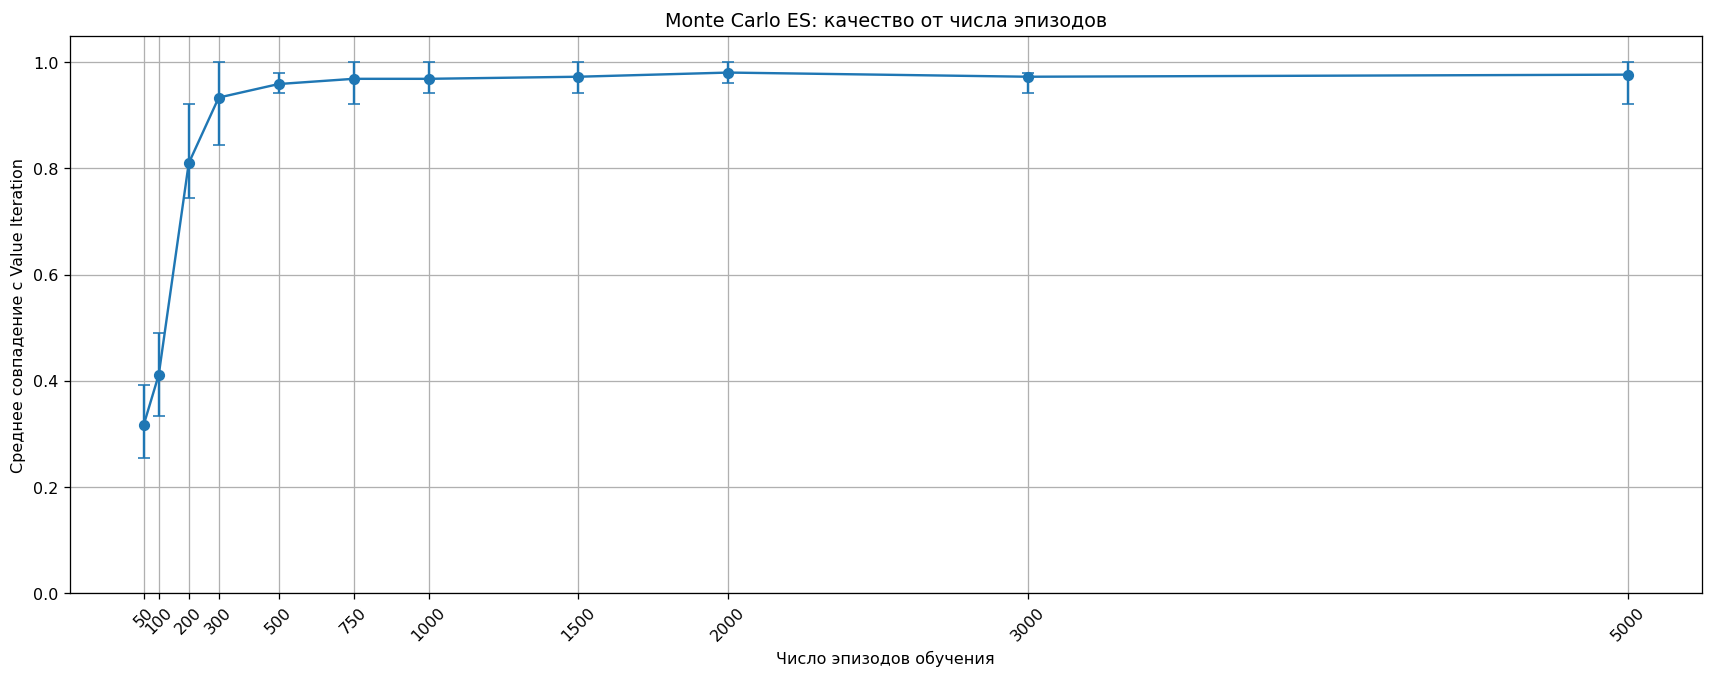

In [25]:
lower_error = (
    df_mc_es_summary["mean_policy_match"]
    - df_mc_es_summary["min_policy_match"]
)

upper_error = (
    df_mc_es_summary["max_policy_match"]
    - df_mc_es_summary["mean_policy_match"]
)

plt.figure(figsize=(15, 6), dpi=115)

plt.errorbar(
    df_mc_es_summary["num_episodes"],
    df_mc_es_summary["mean_policy_match"],
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
)

plt.ylim(0, 1.05)
plt.xticks(df_mc_es_summary["num_episodes"], rotation=45)
plt.xlabel("Число эпизодов обучения")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Monte Carlo ES: качество от числа эпизодов")
plt.grid(True)
plt.tight_layout()
plt.show()

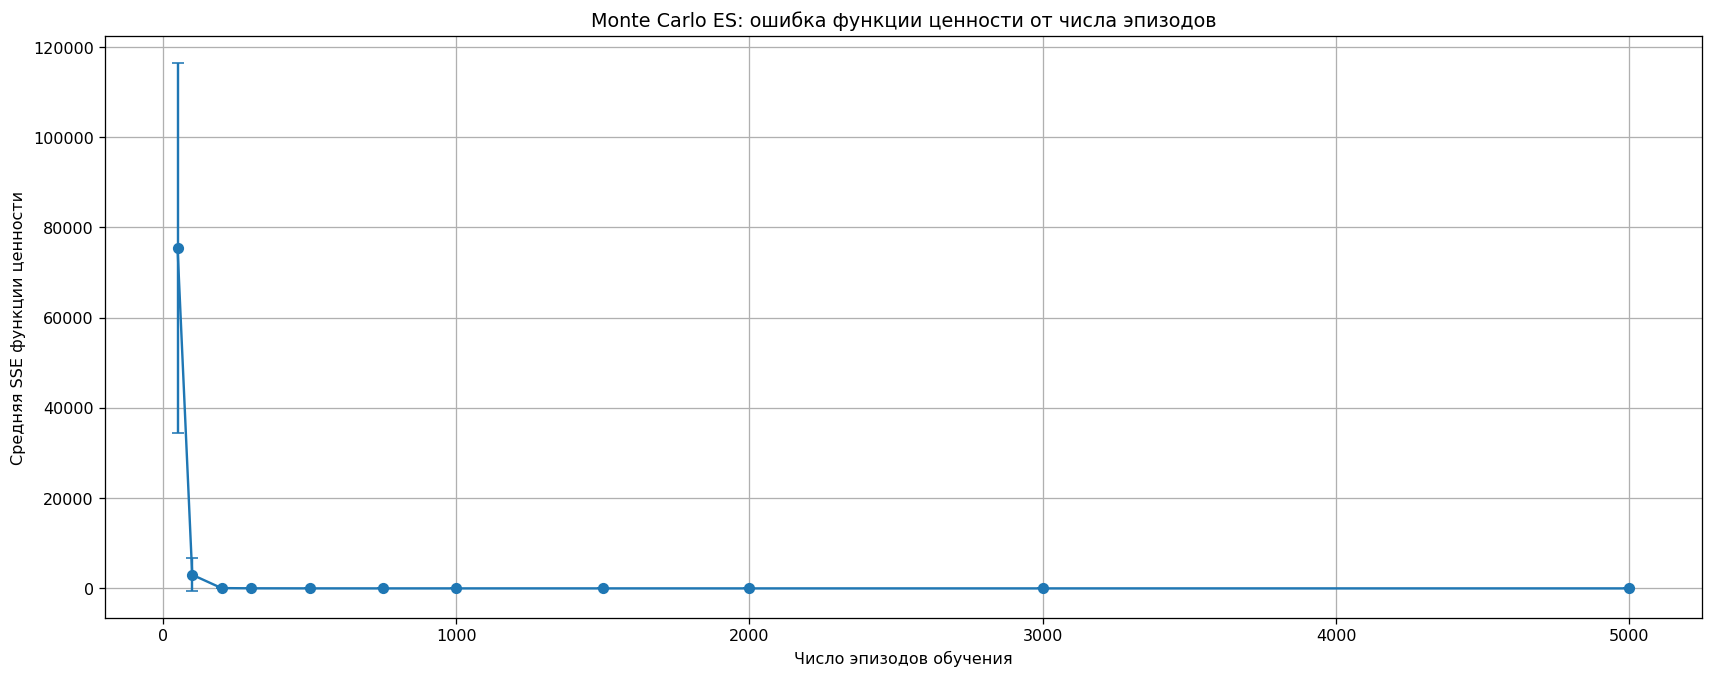

In [26]:
plt.figure(figsize=(15, 6), dpi=115)

plt.errorbar(
    df_mc_es_summary["num_episodes"],
    df_mc_es_summary["mean_value_sse"],
    yerr=df_mc_es_summary["std_value_sse"],
    marker="o",
    capsize=4,
)

plt.xlabel("Число эпизодов обучения")
plt.ylabel("Средняя SSE функции ценности")
plt.title("Monte Carlo ES: ошибка функции ценности от числа эпизодов")
plt.grid(True)
plt.tight_layout()
plt.show()

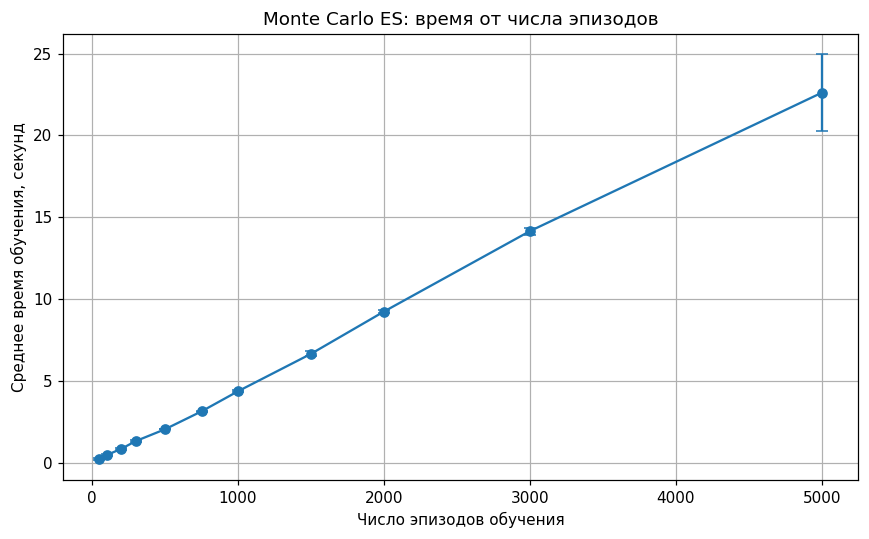

In [27]:
plt.figure(figsize=(8, 5), dpi=110)

plt.errorbar(
    df_mc_es_summary["num_episodes"],
    df_mc_es_summary["mean_training_time"],
    yerr=df_mc_es_summary["std_training_time"],
    marker="o",
    capsize=4,
)

plt.xlabel("Число эпизодов обучения")
plt.ylabel("Среднее время обучения, секунд")
plt.title("Monte Carlo ES: время от числа эпизодов")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по влиянию числа эпизодов

В данном эксперименте исследовалось влияние числа обучающих эпизодов на качество метода Монте-Карло с исследовательскими стартами. Остальные параметры были зафиксированы:

$$
\alpha = 0.05, \qquad \texttt{max\_steps} = 100.
$$

Для каждого значения `num_episodes` метод запускался несколько раз с разными `random_seed`. После этого вычислялись основная метрика ошибки функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2
$$

и дополнительная метрика совпадения найденной политики с эталонной политикой, полученной методом Value Iteration.

По результатам видно, что при малом числе эпизодов качество обучения низкое. При 50 и 100 эпизодах метод ещё не успевает достаточно хорошо оценить значения $Q(s,a)$, поэтому найденная политика заметно отличается от эталонной, а ошибка функции ценности принимает большие значения.

При увеличении числа эпизодов до 200--300 качество резко возрастает. Доля совпадающих действий быстро приближается к единице, а значение $\mathrm{SSE}_V$ существенно уменьшается. Это означает, что метод начинает получать достаточно опыта по разным парам состояние--действие благодаря исследовательским стартам.

Начиная примерно с 500--750 эпизодов совпадение с эталонной политикой становится высоким и держится около $0.96$--$0.98$. При этом ошибка функции ценности также выходит на относительно малый уровень. Минимальное среднее значение $\mathrm{SSE}_V$ в данном эксперименте достигается при 2000 эпизодах:

$$
\mathrm{mean\_SSE}_V \approx 12.996.
$$

Однако дальнейшее увеличение числа эпизодов уже не даёт устойчивого улучшения: при 3000 и 5000 эпизодах средняя ошибка не уменьшается, а время обучения продолжает расти.

График времени показывает почти линейную зависимость от числа эпизодов. Это ожидаемо, так как при фиксированной максимальной длине эпизода общее число шагов среды примерно пропорционально величине

$$
\texttt{num\_episodes} \cdot \texttt{max\_steps}.
$$

Таким образом, простое увеличение числа эпизодов после некоторого уровня становится не самым эффективным способом улучшения качества: вычислительные затраты продолжают расти, а значения метрик меняются слабо. По текущим результатам разумным компромиссом можно считать диапазон 1000--2000 эпизодов, где стратегия уже почти совпадает с эталонной, а ошибка функции ценности близка к минимальной.

#### Исследование влияния шага обучения

Далее исследуем влияние шага обучения `alpha_lr` на качество метода Монте-Карло с исследовательскими стартами.

Число эпизодов и максимальную длину эпизода фиксируем:

$$
\texttt{num\_episodes} = 2000, \qquad \texttt{max\_steps} = 100.
$$

Меняется только шаг обучения. Этот параметр определяет, насколько сильно новая оценка дохода $G$ влияет на текущее значение $Q(s,a)$:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
G-Q(s,a)
\right].
$$

Если шаг слишком маленький, метод может обучаться медленно, поскольку новые значения дохода слабо изменяют текущие оценки $Q(s,a)$. Если шаг слишком большой, оценки могут сильно колебаться из-за случайности эпизодов.

Поэтому нужно подобрать значение $\alpha$, при котором ошибка функции ценности $\mathrm{SSE}_V$ получается достаточно малой, а найденная политика остаётся близкой к эталонной политике Value Iteration.

In [28]:
def experiment_mc_es_alpha_parallel(
    alpha_list,
    seeds,
    num_episodes,
    gamma,
    max_steps=100,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_es_once_light)(
            num_episodes=num_episodes,
            alpha_lr=alpha_lr,
            gamma=gamma,
            max_steps=max_steps,
            random_seed=seed,
        )
        for alpha_lr in alpha_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby("alpha_lr")
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [29]:
alpha_list = [
    0.005,
    0.01,
    0.02,
    0.03,
    0.035,
    0.04,
    0.07,
    0.1,
    0.2,
]
seeds = list(range(1, 11))

df_mc_es_alpha_raw, df_mc_es_alpha_summary = (
    experiment_mc_es_alpha_parallel(
        alpha_list=alpha_list,
        seeds=seeds,
        num_episodes=2000,
        gamma=gamma,
        max_steps=100,
        n_jobs=6,
    )
)

df_mc_es_alpha_summary

,alpha_lr,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,0.005,27.974038,16.607835,41.171648,7.353154,0.850980,0.666667,0.921569,0.072899,9.869094,0.742719
1,0.010,8.233997,6.068257,11.739519,1.720970,0.945098,0.843137,0.980392,0.040078,10.223046,0.339920
2,0.020,6.182896,3.757126,8.802683,1.748500,0.974510,0.960784,0.980392,0.009471,10.323252,0.406983
3,0.030,8.543800,4.264970,11.629748,2.232410,0.980392,0.960784,1.000000,0.016010,11.008098,0.270953
4,0.035,8.900281,4.782960,11.664080,2.202840,0.982353,0.960784,1.000000,0.011130,10.208043,0.213596
5,0.040,11.344899,5.346563,17.335060,3.356900,0.980392,0.960784,1.000000,0.013072,10.238064,0.235078
6,0.070,19.598641,10.901696,28.323649,5.831449,0.970588,0.960784,0.980392,0.010334,10.156975,0.225499
7,0.100,35.579934,17.129450,65.283336,13.169812,0.943137,0.921569,0.960784,0.014468,10.362951,0.209160
8,0.200,114.932297,74.979710,180.605030,28.484949,0.807843,0.784314,0.862745,0.025815,10.681328,0.368964


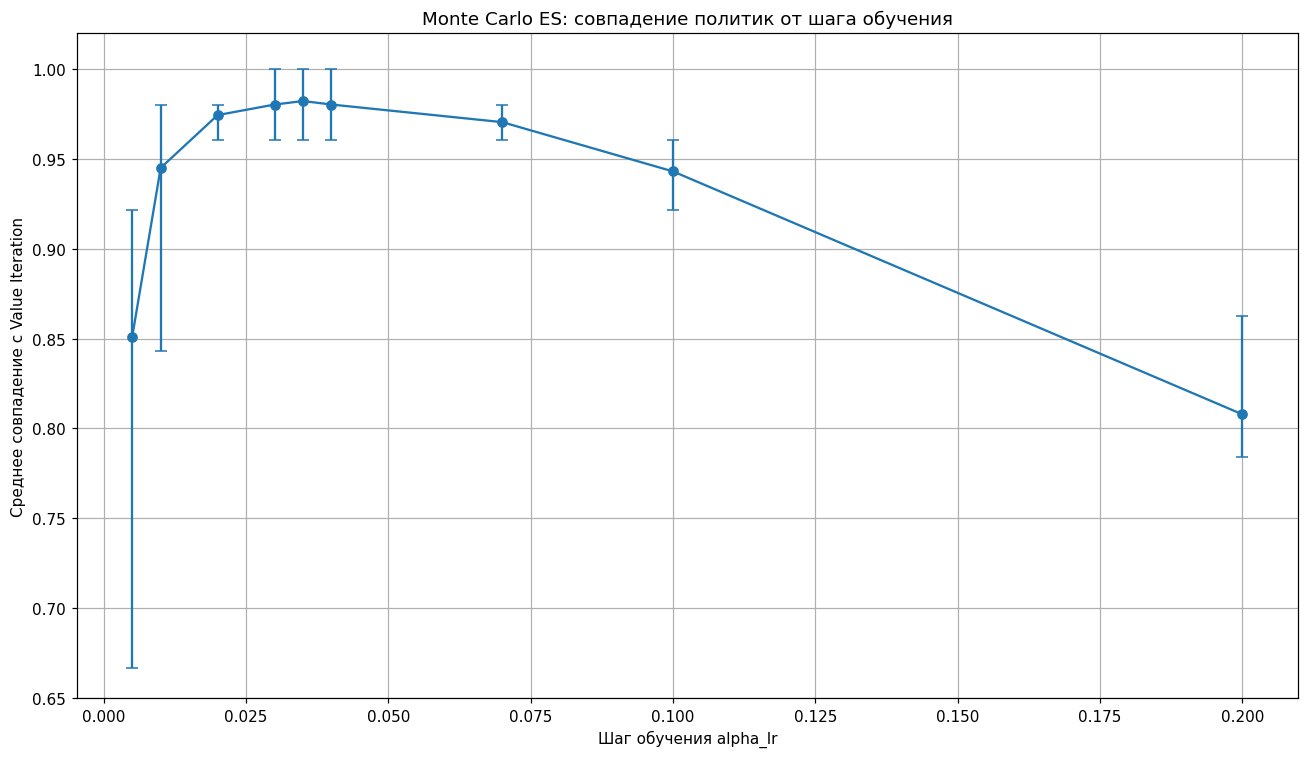

In [30]:
lower_error = (
    df_mc_es_alpha_summary["mean_policy_match"]
    - df_mc_es_alpha_summary["min_policy_match"]
)

upper_error = (
    df_mc_es_alpha_summary["max_policy_match"]
    - df_mc_es_alpha_summary["mean_policy_match"]
)

plt.figure(figsize=(12, 7), dpi=110)

plt.errorbar(
    df_mc_es_alpha_summary["alpha_lr"],
    df_mc_es_alpha_summary["mean_policy_match"],
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
)

plt.ylim(0.65, 1.02)

plt.xlabel("Шаг обучения alpha_lr")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Monte Carlo ES: совпадение политик от шага обучения")
plt.grid(True)
plt.tight_layout()
plt.show()

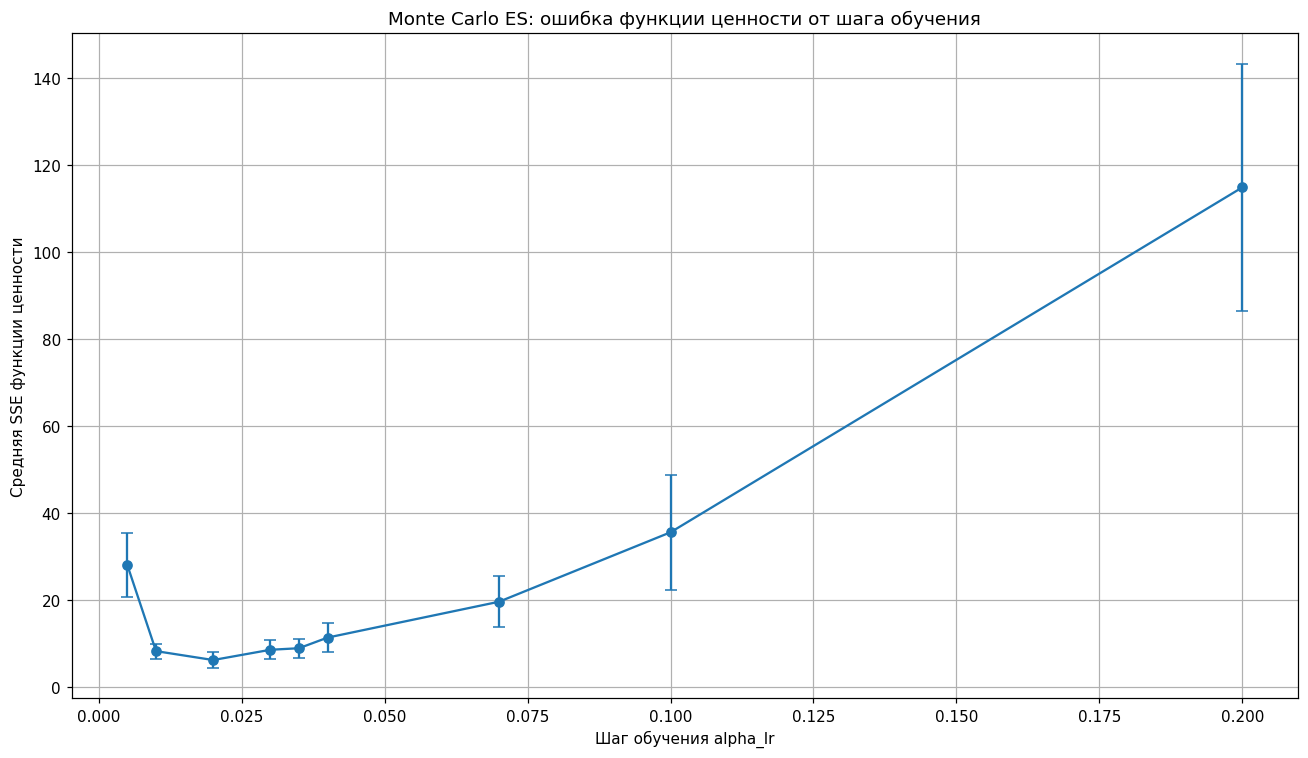

In [31]:
plt.figure(figsize=(12, 7), dpi=110)

plt.errorbar(
    df_mc_es_alpha_summary["alpha_lr"],
    df_mc_es_alpha_summary["mean_value_sse"],
    yerr=df_mc_es_alpha_summary["std_value_sse"],
    marker="o",
    capsize=4,
)

plt.xlabel("Шаг обучения alpha_lr")
plt.ylabel("Средняя SSE функции ценности")
plt.title("Monte Carlo ES: ошибка функции ценности от шага обучения")
plt.grid(True)
plt.tight_layout()
plt.show()

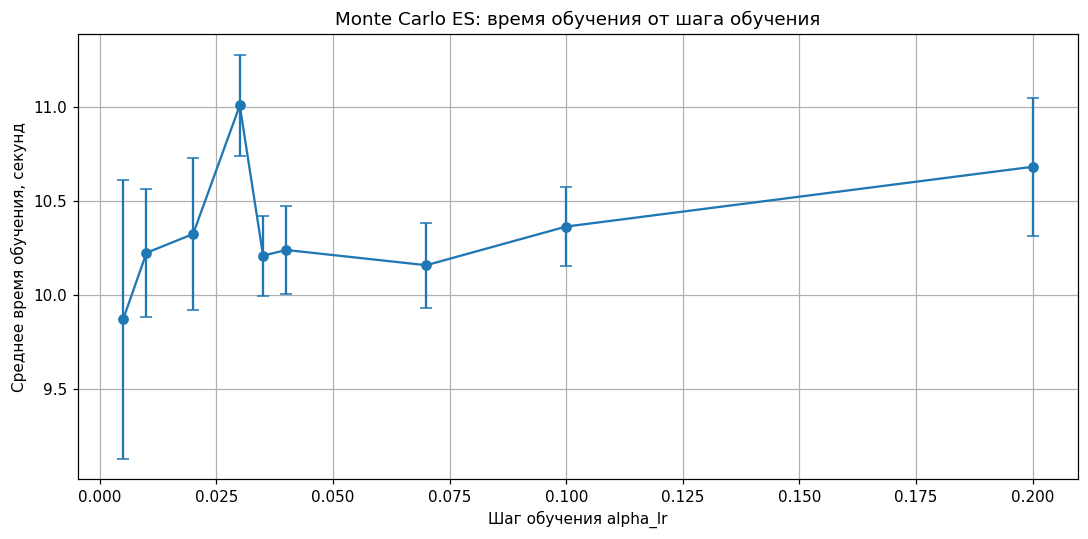

In [32]:
plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_es_alpha_summary["alpha_lr"],
    df_mc_es_alpha_summary["mean_training_time"],
    yerr=df_mc_es_alpha_summary["std_training_time"],
    marker="o",
    capsize=4,
)

plt.xlabel("Шаг обучения alpha_lr")
plt.ylabel("Среднее время обучения, секунд")
plt.title("Monte Carlo ES: время обучения от шага обучения")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по влиянию шага обучения

В данном эксперименте исследовалось влияние шага обучения `alpha_lr` на качество метода Монте-Карло с исследовательскими стартами. Остальные параметры были зафиксированы:

$$
\texttt{num\_episodes}=2000, \qquad \texttt{max\_steps}=100.
$$

Для каждого значения `alpha_lr` метод запускался несколько раз с разными `random_seed`. После этого вычислялись основная метрика ошибки функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2
$$

и дополнительная метрика совпадения найденной политики с эталонной политикой Value Iteration.

По результатам видно, что слишком маленькое значение `alpha_lr = 0.005` приводит к худшему качеству. Обновления $Q(s,a)$ оказываются слишком слабыми, поэтому метод медленнее приспосабливается к новым эпизодам. Это отражается как в меньшем совпадении политики с эталонной, так и в достаточно большой ошибке функции ценности.

При увеличении шага обучения до диапазона `0.02--0.04` качество становится наиболее устойчивым. В этом диапазоне найденная политика почти полностью совпадает с эталонной, а ошибка функции ценности остаётся небольшой. По основной метрике $\mathrm{SSE}_V$ наилучшее значение достигается при `alpha_lr = 0.02`:

$$
\mathrm{mean\_SSE}_V \approx 6.18.
$$

При дальнейшем увеличении `alpha_lr` качество начинает ухудшаться. Особенно заметно это при `alpha_lr = 0.1` и `alpha_lr = 0.2`: совпадение политики с эталонной уменьшается, а ошибка функции ценности резко возрастает. Это связано с тем, что Monte Carlo-оценки дохода $G$ являются шумными, и слишком большой шаг обучения делает обновления $Q(s,a)$ менее устойчивыми.

Время обучения почти не зависит от `alpha_lr`, так как число эпизодов и максимальная длина эпизода фиксированы. Небольшие колебания времени связаны в основном с особенностями параллельного запуска и текущей загрузкой компьютера.

Таким образом, для дальнейших экспериментов разумно выбирать `alpha_lr` из диапазона `0.02--0.04`. С точки зрения основной метрики $\mathrm{SSE}_V$ наиболее удачным значением в данном эксперименте является `alpha_lr = 0.02`.

#### Исследование влияния длины эпизода

Далее исследуется влияние параметра `max_steps`, то есть максимальной длины одного эпизода.

Ранее были выбраны достаточно хорошие значения:

$$
\texttt{num\_episodes} = 2000, \qquad \alpha = 0.02.
$$

Теперь эти параметры фиксируются, а меняется только `max_steps`.

Параметр `max_steps` определяет, сколько переходов среды может содержать один эпизод. Если эпизод слишком короткий, метод Монте-Карло видит только ближайшие последствия действий и хуже оценивает полный дисконтированный доход. Если эпизод слишком длинный, оценка дохода может стать точнее, но время обучения возрастает.

Так как используется дисконтирование с параметром $\gamma$, вклад дальних наград постепенно уменьшается:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots
$$

Поэтому слишком большое значение `max_steps` может не давать существенного прироста качества, но увеличивать вычислительные затраты. С другой стороны, слишком маленькое значение `max_steps` приводит к сильному усечению дохода и может ухудшать оценки $Q(s,a)$.

In [33]:
def experiment_mc_es_max_steps_parallel(
    max_steps_list,
    seeds,
    num_episodes,
    alpha_lr,
    gamma,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_es_once_light)(
            num_episodes=num_episodes,
            alpha_lr=alpha_lr,
            gamma=gamma,
            max_steps=max_steps,
            random_seed=seed,
        )
        for max_steps in max_steps_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby("max_steps")
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [34]:
max_steps_list = [
    10,
    20,
    30,
    50,
    75,
    100,
    150,
    200,
]

seeds = list(range(1, 11))

df_mc_es_steps_raw, df_mc_es_steps_summary = (
    experiment_mc_es_max_steps_parallel(
        max_steps_list=max_steps_list,
        seeds=seeds,
        num_episodes=2000,
        alpha_lr=0.02,
        gamma=gamma,
        n_jobs=6,
    )
)

df_mc_es_steps_summary

,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,10,33729.966840,32783.882349,35107.363593,918.300155,0.407843,0.294118,0.490196,0.062554,0.964172,0.044731
1,20,4443.478063,4175.067087,4696.490021,163.466323,0.568627,0.509804,0.627451,0.047131,1.873081,0.160892
2,30,1074.825799,866.541309,1255.805744,135.650252,0.690196,0.568627,0.764706,0.061868,2.712138,0.110155
3,50,111.921149,62.759013,180.126694,44.914492,0.903922,0.862745,0.960784,0.029880,4.392381,0.046720
4,75,9.805755,6.380879,14.632056,3.018112,0.966667,0.921569,0.980392,0.020772,7.046391,0.138977
5,100,6.182896,3.757126,8.802683,1.748500,0.974510,0.960784,0.980392,0.009471,9.412506,0.069275
6,150,5.089951,3.307608,6.179340,0.916582,0.982353,0.960784,1.000000,0.011130,14.559212,0.129467
7,200,5.652991,3.862842,6.830966,0.883266,0.980392,0.960784,1.000000,0.009243,18.775203,2.302377


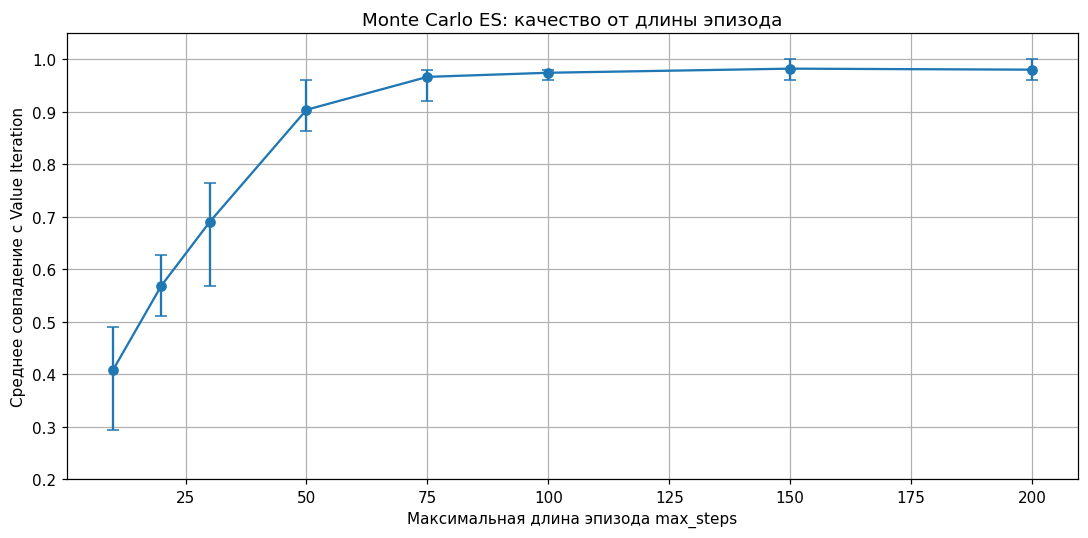

In [35]:
lower_error = (
    df_mc_es_steps_summary["mean_policy_match"]
    - df_mc_es_steps_summary["min_policy_match"]
)

upper_error = (
    df_mc_es_steps_summary["max_policy_match"]
    - df_mc_es_steps_summary["mean_policy_match"]
)

plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_es_steps_summary["max_steps"],
    df_mc_es_steps_summary["mean_policy_match"],
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
)

plt.ylim(0.2, 1.05)

plt.xlabel("Максимальная длина эпизода max_steps")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Monte Carlo ES: качество от длины эпизода")
plt.grid(True)
plt.tight_layout()
plt.show()

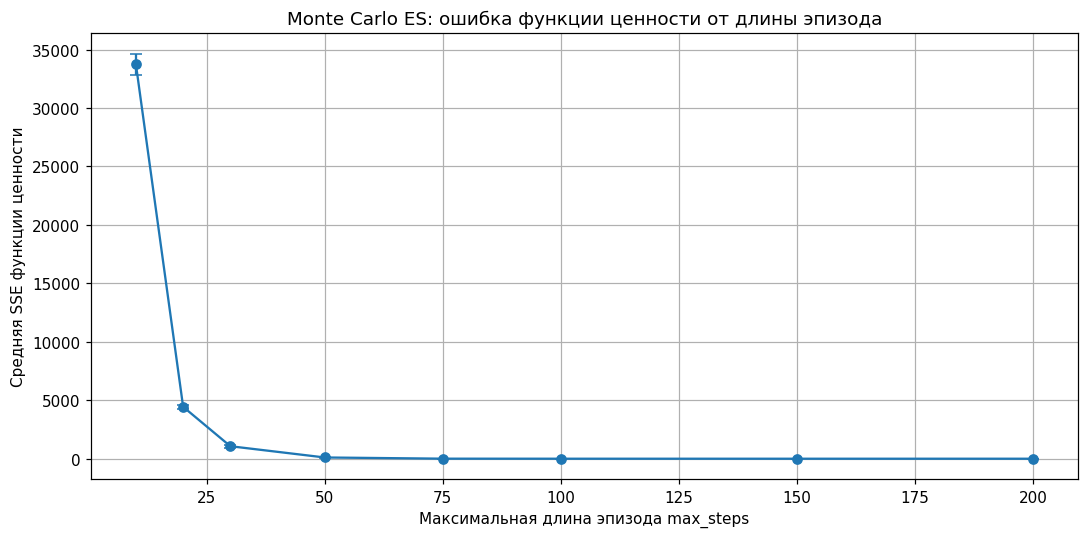

In [36]:
plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_es_steps_summary["max_steps"],
    df_mc_es_steps_summary["mean_value_sse"],
    yerr=df_mc_es_steps_summary["std_value_sse"],
    marker="o",
    capsize=4,
)

plt.xlabel("Максимальная длина эпизода max_steps")
plt.ylabel("Средняя SSE функции ценности")
plt.title("Monte Carlo ES: ошибка функции ценности от длины эпизода")
plt.grid(True)
plt.tight_layout()
plt.show()

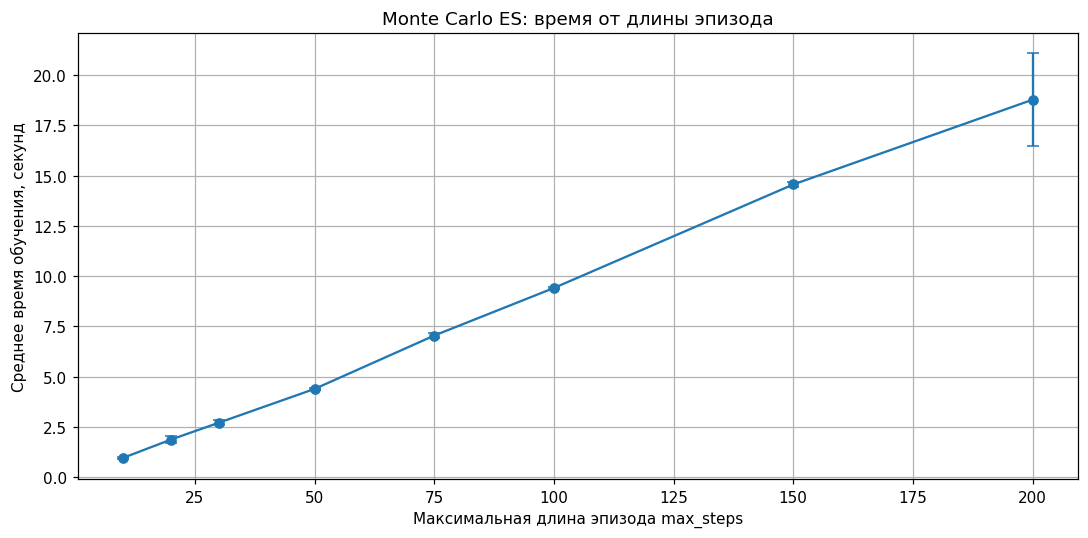

In [37]:
plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_es_steps_summary["max_steps"],
    df_mc_es_steps_summary["mean_training_time"],
    yerr=df_mc_es_steps_summary["std_training_time"],
    marker="o",
    capsize=4,
)

plt.xlabel("Максимальная длина эпизода max_steps")
plt.ylabel("Среднее время обучения, секунд")
plt.title("Monte Carlo ES: время от длины эпизода")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по влиянию длины эпизода

В данном эксперименте исследовалось влияние параметра `max_steps`, то есть максимальной длины одного эпизода. Остальные параметры были зафиксированы:

$$
num\_episodes = 2000, \qquad \alpha = 0.02.
$$

Для каждого значения `max_steps` метод запускался несколько раз с разными `random_seed`. После этого вычислялись две метрики: совпадение найденной политики с эталонной политикой Value Iteration и ошибка функции ценности

$$
\mathrm{SSE}_V = \sum_{s \in S} \left(V_{\mathrm{MC}}(s) - V_*(s)\right)^2.
$$

По результатам видно, что при малой длине эпизода качество метода низкое. При `max_steps = 10`, `20`, `30` агент видит слишком короткие траектории, поэтому Monte Carlo-оценка дохода $G$ плохо отражает долгосрочные последствия действий. Это проявляется как в низком совпадении политики с эталонной, так и в очень большой ошибке функции ценности.

При увеличении `max_steps` качество резко возрастает. Уже при `max_steps = 50` среднее совпадение с политикой Value Iteration становится достаточно высоким, а значение $\mathrm{SSE}_V$ существенно уменьшается. При `max_steps = 75` найденная стратегия почти совпадает с эталонной, однако по основной метрике ошибка функции ценности всё ещё заметно больше, чем при более длинных эпизодах.

Наилучшее среднее значение ошибки функции ценности достигается при `max_steps = 150`. При этом совпадение политики с эталонной также остаётся высоким. Значение `max_steps = 200` уже не улучшает результат: ошибка функции ценности немного возрастает, а время обучения становится больше.

Дальнейшее увеличение длины эпизода заметно увеличивает время обучения. Это ожидаемо, так как число переходов среды примерно пропорционально длине эпизода:

$$
\text{число шагов} \sim num\_episodes \cdot max\_steps.
$$

Таким образом, с точки зрения дополнительной метрики `policy_match` значения `max_steps = 75`, `100`, `150` и `200` дают близкие результаты. Однако основная метрика $\mathrm{SSE}_V$ показывает, что функция ценности лучше всего приближается к оптимальной при `max_steps = 150`. При дальнейшем увеличении длины эпизода до `max_steps = 200` ошибка уже не уменьшается, а время обучения продолжает расти. Поэтому для дальнейших экспериментов в качестве основного значения фиксируется

$$
\texttt{max\_steps} = 150.
$$

#### Промежуточный итог подбора параметров

Для метода Монте-Карло с исследовательскими стартами были отдельно исследованы три параметра:

- `num_episodes` — число обучающих эпизодов;
- `alpha_lr` — шаг обучения;
- `max_steps` — максимальная длина одного эпизода.

По отдельным экспериментам были получены следующие разумные значения:

$$
\texttt{num\_episodes} = 2000,
\qquad
\alpha = 0.02,
\qquad
\texttt{max\_steps} = 150.
$$

Эти значения выбраны с учётом новой основной метрики качества

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

При подборе числа эпизодов значение `num_episodes = 2000` дало минимальную среднюю ошибку функции ценности среди рассмотренных вариантов. При подборе шага обучения минимальное значение $\mathrm{SSE}_V$ было получено при `alpha_lr = 0.02`. При подборе длины эпизода лучшая ошибка функции ценности наблюдалась при `max_steps = 150`.

При этом дополнительная метрика `policy_match` в некоторых случаях указывала на немного другие значения параметров. Например, по совпадению стратегий можно было выбрать `alpha_lr = 0.035` или `max_steps = 75`, так как найденная политика уже почти совпадала с эталонной. Однако основная метрика показывает, что при этих параметрах функция ценности приближается к оптимальной хуже. Поэтому в дальнейшем основным критерием выбора считается минимизация $\mathrm{SSE}_V$, а совпадение стратегий используется как дополнительная характеристика.

Важно, что такой подбор проводился последовательно: при исследовании одного параметра остальные фиксировались. Поэтому найденная комбинация не обязана быть глобально лучшей. Параметры могут взаимодействовать между собой. Например, меньшая длина эпизода может позволить использовать больше эпизодов за то же время, а другой шаг обучения может оказаться лучше при другой длине траектории.

Поэтому далее проводится небольшой локальный перебор параметров в окрестности найденных хороших значений. Это позволит проверить несколько близких комбинаций и выбрать вариант с лучшим компромиссом между ошибкой функции ценности, совпадением стратегии с эталонной и временем обучения.

In [38]:
def experiment_mc_es_local_grid_parallel(
    num_episodes_list,
    alpha_list,
    max_steps_list,
    seeds,
    gamma,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_es_once_light)(
            num_episodes=num_episodes,
            alpha_lr=alpha_lr,
            gamma=gamma,
            max_steps=max_steps,
            random_seed=seed,
        )
        for num_episodes in num_episodes_list
        for alpha_lr in alpha_list
        for max_steps in max_steps_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby(["num_episodes", "alpha_lr", "max_steps"])
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [39]:
num_episodes_list = [1500, 2000, 3000]
alpha_list = [0.015, 0.02, 0.03]
max_steps_list = [100, 150, 200]

seeds = list(range(1, 12))

df_mc_es_grid_raw, df_mc_es_grid_summary = (
    experiment_mc_es_local_grid_parallel(
        num_episodes_list=num_episodes_list,
        alpha_list=alpha_list,
        max_steps_list=max_steps_list,
        seeds=seeds,
        gamma=gamma,
        n_jobs=6,
    )
)

df_mc_es_grid_summary

,num_episodes,alpha_lr,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,1500,0.015,100,7.215984,4.709829,10.989582,2.079672,0.959002,0.921569,0.980392,0.018507,6.595235,0.087206
1,1500,0.015,150,5.827568,2.587346,13.096873,2.736152,0.967914,0.941176,0.980392,0.013220,10.227692,0.175020
2,1500,0.015,200,4.933578,2.915225,9.324599,1.886524,0.978610,0.960784,1.000000,0.013738,16.100121,1.293337
3,1500,0.020,100,7.245683,4.725330,11.401499,2.210439,0.976827,0.960784,0.980392,0.007932,8.424030,0.167651
4,1500,0.020,150,6.444607,3.651153,11.223113,1.961987,0.978610,0.941176,1.000000,0.013738,12.052667,0.157496
5,1500,0.020,200,5.262453,3.811166,7.464264,1.122028,0.975045,0.960784,1.000000,0.012680,15.821456,0.199378
6,1500,0.030,100,8.349691,5.748240,13.466876,2.714000,0.978610,0.960784,1.000000,0.013738,8.028694,0.275760
7,1500,0.030,150,9.743244,6.034943,13.979374,2.747786,0.976827,0.941176,1.000000,0.021151,11.577464,0.524298
8,1500,0.030,200,8.044506,6.076305,9.574450,1.138708,0.985740,0.980392,1.000000,0.009159,14.985565,0.260251
9,2000,0.015,100,6.144569,4.894927,8.666353,1.189730,0.969697,0.921569,0.980392,0.020308,10.027934,0.084858


In [40]:
df_mc_es_grid_best = (
    df_mc_es_grid_summary
    .sort_values(
        by=[
            "mean_value_sse",
            "std_value_sse",
            "mean_policy_match",
            "mean_training_time",
        ],
        ascending=[True, True, False, True],
    )
    .reset_index(drop=True)
)

df_mc_es_grid_best["rank"] = df_mc_es_grid_best.index + 1

df_mc_es_grid_best["config"] = (
    "ep=" + df_mc_es_grid_best["num_episodes"].astype(str)
    + ", a=" + df_mc_es_grid_best["alpha_lr"].astype(str)
    + ", steps=" + df_mc_es_grid_best["max_steps"].astype(str)
)

df_mc_es_grid_best[
    [
        "rank",
        "num_episodes",
        "alpha_lr",
        "max_steps",
        "mean_value_sse",
        "min_value_sse",
        "max_value_sse",
        "std_value_sse",
        "mean_policy_match",
        "min_policy_match",
        "max_policy_match",
        "std_policy_match",
        "mean_training_time",
        "std_training_time",
        "config",
    ]
]

,rank,num_episodes,alpha_lr,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time,config
0,1,3000,0.015,150,3.513783,2.360623,4.599361,0.762166,0.980392,0.980392,0.980392,0.000000,22.596611,0.418408,"ep=3000, a=0.015, steps=150"
1,2,3000,0.015,200,3.816689,2.574819,5.019950,0.868760,0.980392,0.960784,1.000000,0.012401,29.786634,0.177986,"ep=3000, a=0.015, steps=200"
2,3,2000,0.015,200,4.335194,3.034687,5.695276,0.944919,0.982175,0.960784,1.000000,0.010576,19.961764,0.170180,"ep=2000, a=0.015, steps=200"
3,4,2000,0.015,150,4.369145,2.200761,7.718701,1.641551,0.975045,0.960784,0.980392,0.009159,15.086098,0.156659,"ep=2000, a=0.015, steps=150"
4,5,3000,0.020,150,4.781856,2.827838,7.552385,1.450176,0.985740,0.980392,1.000000,0.009159,22.781066,0.210525,"ep=3000, a=0.02, steps=150"
5,6,1500,0.015,200,4.933578,2.915225,9.324599,1.886524,0.978610,0.960784,1.000000,0.013738,16.100121,1.293337,"ep=1500, a=0.015, steps=200"
6,7,2000,0.020,150,5.080657,3.307608,6.179340,0.870092,0.982175,0.960784,1.000000,0.010576,15.171634,0.246647,"ep=2000, a=0.02, steps=150"
7,8,3000,0.020,200,5.217009,3.748394,7.748922,1.391922,0.985740,0.980392,1.000000,0.009159,30.469638,0.243294,"ep=3000, a=0.02, steps=200"
8,9,1500,0.020,200,5.262453,3.811166,7.464264,1.122028,0.975045,0.960784,1.000000,0.012680,15.821456,0.199378,"ep=1500, a=0.02, steps=200"
9,10,3000,0.015,100,5.337668,4.195042,6.711206,0.822671,0.971480,0.941176,0.980392,0.013481,15.590345,0.589394,"ep=3000, a=0.015, steps=100"


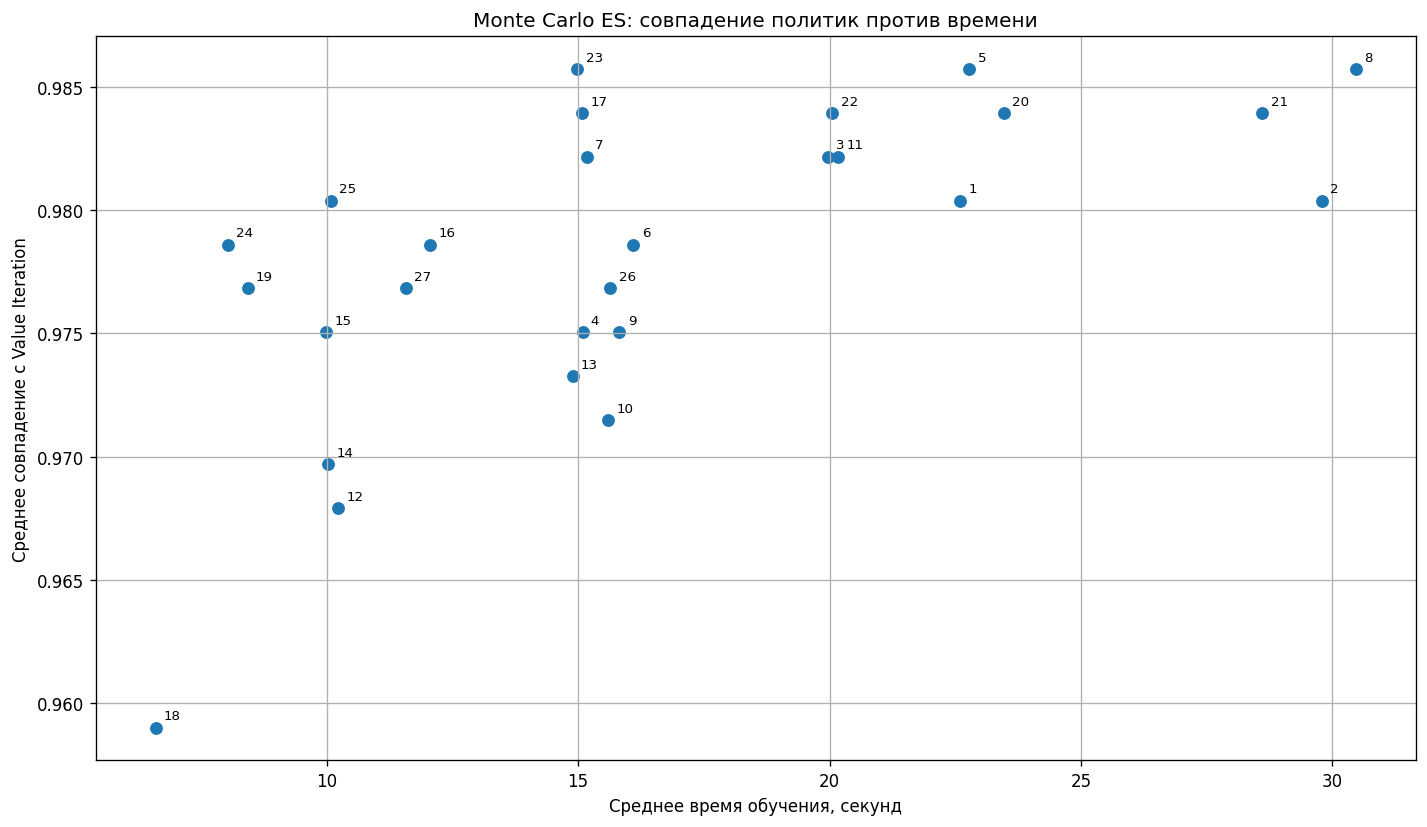

In [41]:
plt.figure(figsize=(12, 7), dpi=120)

plt.scatter(
    df_mc_es_grid_best["mean_training_time"],
    df_mc_es_grid_best["mean_policy_match"],
    s=45,
)

for _, row in df_mc_es_grid_best.iterrows():
    plt.annotate(
        str(int(row["rank"])),
        (
            row["mean_training_time"],
            row["mean_policy_match"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Среднее время обучения, секунд")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Monte Carlo ES: совпадение политик против времени")
plt.grid(True)
plt.tight_layout()
plt.show()

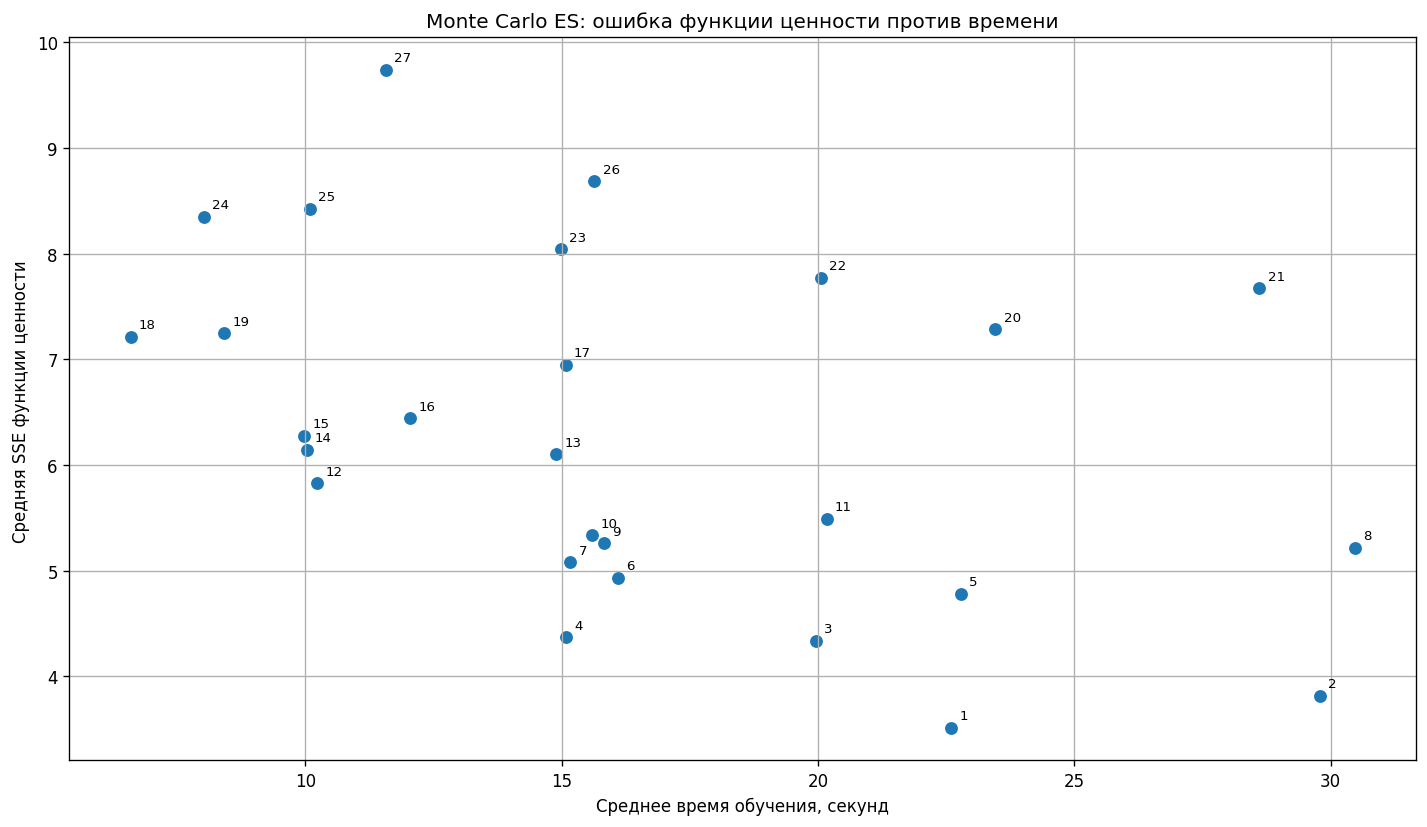

In [42]:
plt.figure(figsize=(12, 7), dpi=120)

plt.scatter(
    df_mc_es_grid_best["mean_training_time"],
    df_mc_es_grid_best["mean_value_sse"],
    s=45,
)

for _, row in df_mc_es_grid_best.iterrows():
    plt.annotate(
        str(int(row["rank"])),
        (
            row["mean_training_time"],
            row["mean_value_sse"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Среднее время обучения, секунд")
plt.ylabel("Средняя SSE функции ценности ")
plt.title("Monte Carlo ES: ошибка функции ценности против времени")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по локальному перебору параметров

Локальный перебор показал, что несколько конфигураций дают близкое качество, однако основной метрикой в дальнейшем считается ошибка функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

Поэтому лучшие параметры выбирались прежде всего по минимальному среднему значению $\mathrm{SSE}_V$. Метрика `policy_match` использовалась как дополнительная характеристика качества найденной стратегии.

По результатам сортировки лучшей конфигурацией по основной метрике стала

$$
\texttt{num\_episodes} = 3000,
\qquad
\alpha = 0.015,
\qquad
\texttt{max\_steps} = 150.
$$

Для неё получено минимальное среднее значение ошибки функции ценности среди рассмотренных вариантов:

$$
\mathrm{mean\_SSE}_V \approx 3.51.
$$

При этом совпадение с эталонной политикой также остаётся высоким:

$$
\mathrm{mean\_policy\_match} \approx 0.980.
$$

Близкий результат даёт конфигурация

$$
\texttt{num\_episodes} = 3000,
\qquad
\alpha = 0.015,
\qquad
\texttt{max\_steps} = 200.
$$

Для неё ошибка функции ценности немного больше:

$$
\mathrm{mean\_SSE}_V \approx 3.82,
$$

а время обучения существенно выше. Поэтому увеличение длины эпизода с 150 до 200 в данном случае не даёт достаточного выигрыша.

Также видно, что увеличение числа эпизодов до `3000` улучшает приближение функции ценности, но заметно увеличивает время обучения. Поэтому выбранная конфигурация является хорошим вариантом с точки зрения основной метрики, хотя и требует большего времени по сравнению с более короткими запусками.

Таким образом, для дальнейшего сравнения с другими методами выбирается конфигурация

$$
\texttt{num\_episodes} = 3000,
\qquad
\alpha = 0.015,
\qquad
\texttt{max\_steps} = 150.
$$

Она даёт наименьшую ошибку функции ценности среди рассмотренных вариантов и сохраняет высокое совпадение найденной политики с эталонной политикой Value Iteration.

## Монте-Карло с единой ε-жадной политикой

Идея метода состоит в том, что агент действует по ε-жадной политике, получает с её помощью эпизоды, а затем по этим эпизодам обновляет значения $Q(s,a)$. После обновления $Q(s,a)$ меняется и сама политика, так как выбор действий снова строится по новым значениям функции качества.

Таким образом, в этом методе одна и та же политика используется и для получения опыта, и для улучшения оценок. Поэтому такой вариант относится к on-policy методам.

ε-жадная политика выбирает:

- случайное действие с вероятностью $\varepsilon$;
- лучшее действие по текущим значениям $Q(s,a)$ с вероятностью $1-\varepsilon$.

За счёт этого агент одновременно исследует среду и использует уже найденные хорошие действия.

Обновление имеет вид:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\eta
\left(
G_t - Q(s_t,a_t)
\right),
$$

где $G_t$ — дисконтированный доход после момента времени $t$.

Для улучшения покрытия пространства состояний при обучении использовался случайный выбор начального состояния. В отличие от метода с исследовательскими стартами, первое действие не задавалось случайно отдельно, а выбиралось по текущей ε-жадной политике.

In [43]:
def monte_carlo_epsilon_greedy(
    env,
    states,
    actions,
    num_episodes,
    alpha_lr,
    gamma,
    epsilon,
    random_seed=None,
    random_start=False,
):
    rng = np.random.default_rng(random_seed)
    Q = defaultdict(float)
    returns_history = []

    for _ in range(num_episodes):
        episode = []

        state = env.reset(random_start=random_start)
        done = False

        while not done:
            action = choose_epsilon_greedy_action(
                Q,
                state,
                actions,
                epsilon,
                rng,
            )

            next_state, reward, done = env.step(action)

            episode.append((state, action, reward, next_state))

            state = next_state

        G = 0.0

        for state, action, reward, _ in reversed(episode):
            G = reward + gamma * G

            Q[(state, action)] += alpha_lr * (
                G - Q[(state, action)]
            )

        returns_history.append(discounted_episode_return(episode, gamma))

    policy = build_greedy_policy(Q, states, actions)

    return Q, policy, returns_history

In [44]:
env_mc_eps = QueueControlEnv(
    n=N,
    states=S,
    actions=A,
    arrival_probs=arrival_probs,
    service_probs=service_probs,
    reward_func=R,
    max_steps=100,
    start_state=0,
    random_seed=42,
)

Q_mc_eps, PI_mc_eps, returns_mc_eps = monte_carlo_epsilon_greedy(
    env=env_mc_eps,
    states=S,
    actions=A,
    num_episodes=2000,
    alpha_lr=0.03,
    gamma=gamma,
    epsilon=0.2,
    random_seed=42,
    random_start=True,
)

V_mc_eps = q_to_value(Q_mc_eps, S, A)
sse_mc_eps = value_sse(V_mc_eps, V_vi, S)
match_mc_eps = policy_match_ratio(PI_mc_eps, PI_vi, S)

print("Политика Монте-Карло с единой ε-жадной политикой:")
for state in S:
    print(f"s = {state}, pi(s) = {PI_mc_eps[state]}")

print("\nSSE функции ценности:", sse_mc_eps)
print("Совпадение с политикой из Value Iteration:", match_mc_eps)

Политика Монте-Карло с единой ε-жадной политикой:
s = 0, pi(s) = off
s = 1, pi(s) = norm
s = 2, pi(s) = fast
s = 3, pi(s) = fast
s = 4, pi(s) = fast
s = 5, pi(s) = norm
s = 6, pi(s) = fast
s = 7, pi(s) = fast
s = 8, pi(s) = fast
s = 9, pi(s) = fast
s = 10, pi(s) = fast
s = 11, pi(s) = fast
s = 12, pi(s) = fast
s = 13, pi(s) = fast
s = 14, pi(s) = fast
s = 15, pi(s) = fast
s = 16, pi(s) = fast
s = 17, pi(s) = fast
s = 18, pi(s) = fast
s = 19, pi(s) = fast
s = 20, pi(s) = fast
s = 21, pi(s) = fast
s = 22, pi(s) = fast
s = 23, pi(s) = fast
s = 24, pi(s) = fast
s = 25, pi(s) = fast
s = 26, pi(s) = fast
s = 27, pi(s) = fast
s = 28, pi(s) = fast
s = 29, pi(s) = fast
s = 30, pi(s) = norm
s = 31, pi(s) = fast
s = 32, pi(s) = fast
s = 33, pi(s) = fast
s = 34, pi(s) = fast
s = 35, pi(s) = fast
s = 36, pi(s) = fast
s = 37, pi(s) = norm
s = 38, pi(s) = fast
s = 39, pi(s) = fast
s = 40, pi(s) = fast
s = 41, pi(s) = fast
s = 42, pi(s) = fast
s = 43, pi(s) = fast
s = 44, pi(s) = fast
s = 45, pi(s) = 

#### Исследование влияния параметра ε

Далее исследуется метод Монте-Карло с единой ε-жадной политикой. В отличие от метода с исследовательскими стартами, здесь первое действие не задаётся случайно отдельно. Исследование происходит за счёт случайного выбора действия внутри эпизода по ε-жадному правилу.

На каждом шаге агент выбирает действие по правилу:

- с вероятностью $1-\varepsilon$ выбирается жадное действие по текущим значениям $Q(s,a)$;
- с вероятностью $\varepsilon$ выбирается случайное действие.

Параметр $\varepsilon$ отвечает за баланс между использованием текущей информации и исследованием новых действий. Если $\varepsilon$ слишком мал, метод может плохо исследовать пространство действий. Если $\varepsilon$ слишком велик, поведение становится слишком случайным, и качество итоговой политики может ухудшаться.

В качестве базовых значений остальных параметров используются значения, близкие к найденным для метода Монте-Карло с исследовательскими стартами:

$$
\texttt{num\_episodes} = 3000,
\qquad
\alpha = 0.015,
\qquad
\texttt{max\_steps} = 150.
$$

Так как задача и среда не изменились, эти значения используются как разумная стартовая область. При этом параметр $\varepsilon$ подбирается отдельно, поскольку именно он определяет механизм исследования в данном методе.

In [45]:
def run_mc_eps_once_light(
    num_episodes,
    alpha_lr,
    gamma,
    epsilon,
    max_steps=100,
    random_seed=42,
    random_start=True,
):
    env_train = QueueControlEnv(
        n=N,
        states=S,
        actions=A,
        arrival_probs=arrival_probs,
        service_probs=service_probs,
        reward_func=R,
        max_steps=max_steps,
        start_state=0,
        random_seed=random_seed,
    )

    start_time = time.perf_counter()

    Q_mc_eps, PI_mc_eps, _ = monte_carlo_epsilon_greedy(
        env=env_train,
        states=S,
        actions=A,
        num_episodes=num_episodes,
        alpha_lr=alpha_lr,
        gamma=gamma,
        epsilon=epsilon,
        random_seed=random_seed,
        random_start=random_start,
    )

    training_time = time.perf_counter() - start_time

    policy_match = policy_match_ratio(
        PI_mc_eps,
        PI_vi,
        S,
    )

    V_mc_eps = q_to_value(Q_mc_eps, S, A)
    value_error_sse = value_sse(V_mc_eps, V_vi, S)

    return {
        "num_episodes": num_episodes,
        "alpha_lr": alpha_lr,
        "epsilon": epsilon,
        "max_steps": max_steps,
        "seed": random_seed,
        "policy_match": policy_match,
        "training_time": training_time,
        "value_sse": value_error_sse,
    }

In [46]:
def experiment_mc_eps_epsilon_parallel(
    epsilon_list,
    seeds,
    num_episodes,
    alpha_lr,
    gamma,
    max_steps=100,
    random_start=True,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_eps_once_light)(
            num_episodes=num_episodes,
            alpha_lr=alpha_lr,
            gamma=gamma,
            epsilon=epsilon,
            max_steps=max_steps,
            random_seed=seed,
            random_start=random_start,
        )
        for epsilon in epsilon_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby("epsilon")
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [48]:
epsilon_list = [
    0.0,
    0.005,
    0.01,
    0.015,
    0.02,
    0.03,
    0.05,
    0.075,
    0.1,
    0.15,
    0.2,
    0.3,
]

seeds = list(range(1, 11))

df_mc_eps_epsilon_raw, df_mc_eps_epsilon_summary = (
    experiment_mc_eps_epsilon_parallel(
        epsilon_list=epsilon_list,
        seeds=seeds,
        num_episodes=3000,
        alpha_lr=0.015,
        gamma=gamma,
        max_steps=150,
        random_start=True,
        n_jobs=6,
    )
)

df_mc_eps_epsilon_summary

,epsilon,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,0.000,3.944611,2.282356,7.284420,1.552528,0.978431,0.960784,0.980392,0.006201,20.151274,0.369548
1,0.005,4.776345,2.372141,8.482349,1.888771,0.986275,0.960784,1.000000,0.016143,21.248749,0.293513
2,0.010,4.577525,2.694966,6.770585,1.310104,0.992157,0.980392,1.000000,0.010125,22.042236,0.231995
3,0.015,3.902574,2.493414,5.850359,1.155832,0.998039,0.980392,1.000000,0.006201,22.173607,0.203782
4,0.020,3.650128,2.393908,6.171061,1.208862,0.998039,0.980392,1.000000,0.006201,22.483146,0.242766
5,0.030,4.398611,2.571825,6.874975,1.692222,0.996078,0.980392,1.000000,0.008267,22.664884,0.275331
6,0.050,4.658827,3.154056,7.293301,1.498738,0.998039,0.980392,1.000000,0.006201,22.624759,0.152070
7,0.075,4.782569,3.193132,7.908672,1.415681,1.000000,1.000000,1.000000,0.000000,22.753862,0.212893
8,0.100,5.560537,2.985091,9.806267,2.158282,0.998039,0.980392,1.000000,0.006201,23.066341,0.204341
9,0.150,8.600276,5.185778,12.238396,2.378279,0.994118,0.980392,1.000000,0.009471,23.026056,0.252899


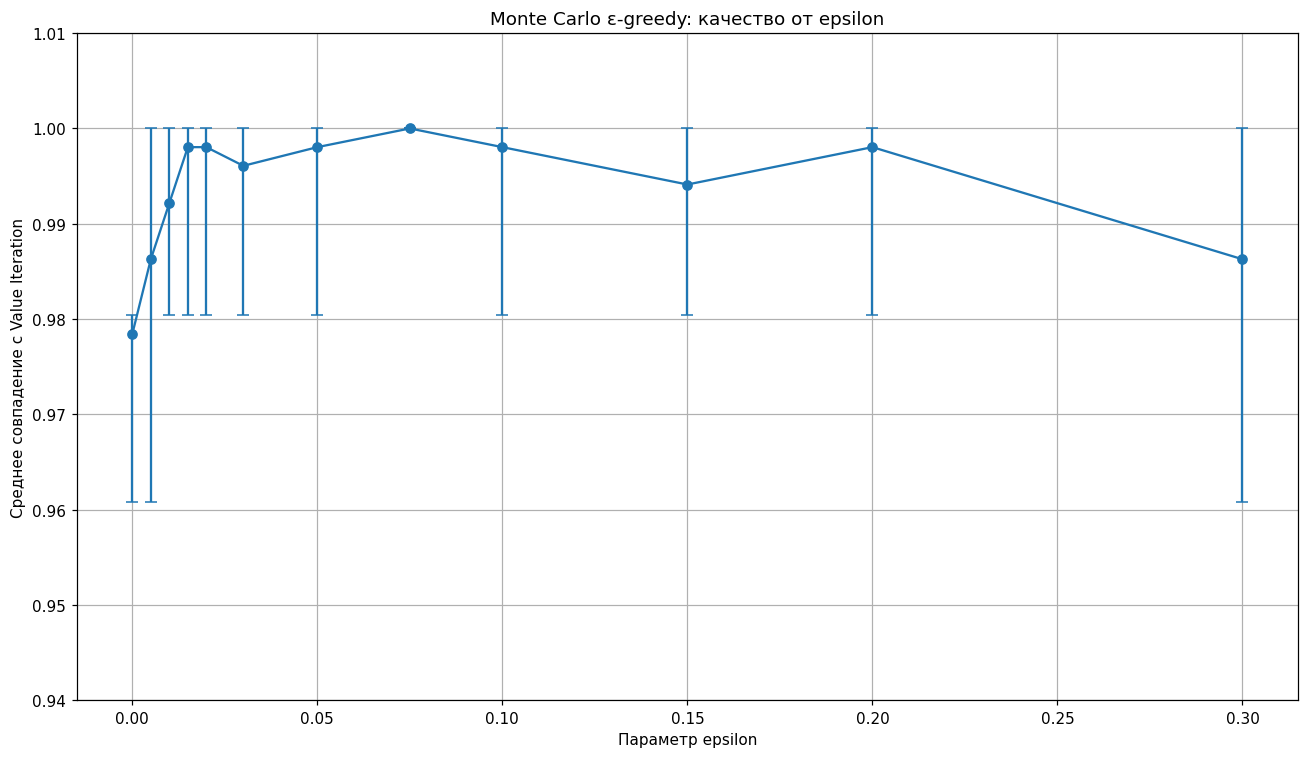

In [53]:
lower_error = (
    df_mc_eps_epsilon_summary["mean_policy_match"]
    - df_mc_eps_epsilon_summary["min_policy_match"]
)

upper_error = (
    df_mc_eps_epsilon_summary["max_policy_match"]
    - df_mc_eps_epsilon_summary["mean_policy_match"]
)

plt.figure(figsize=(12, 7), dpi=110)

plt.errorbar(
    df_mc_eps_epsilon_summary["epsilon"],
    df_mc_eps_epsilon_summary["mean_policy_match"],
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
)

plt.ylim(0.94, 1.01)

plt.xlabel("Параметр epsilon")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Monte Carlo ε-greedy: качество от epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

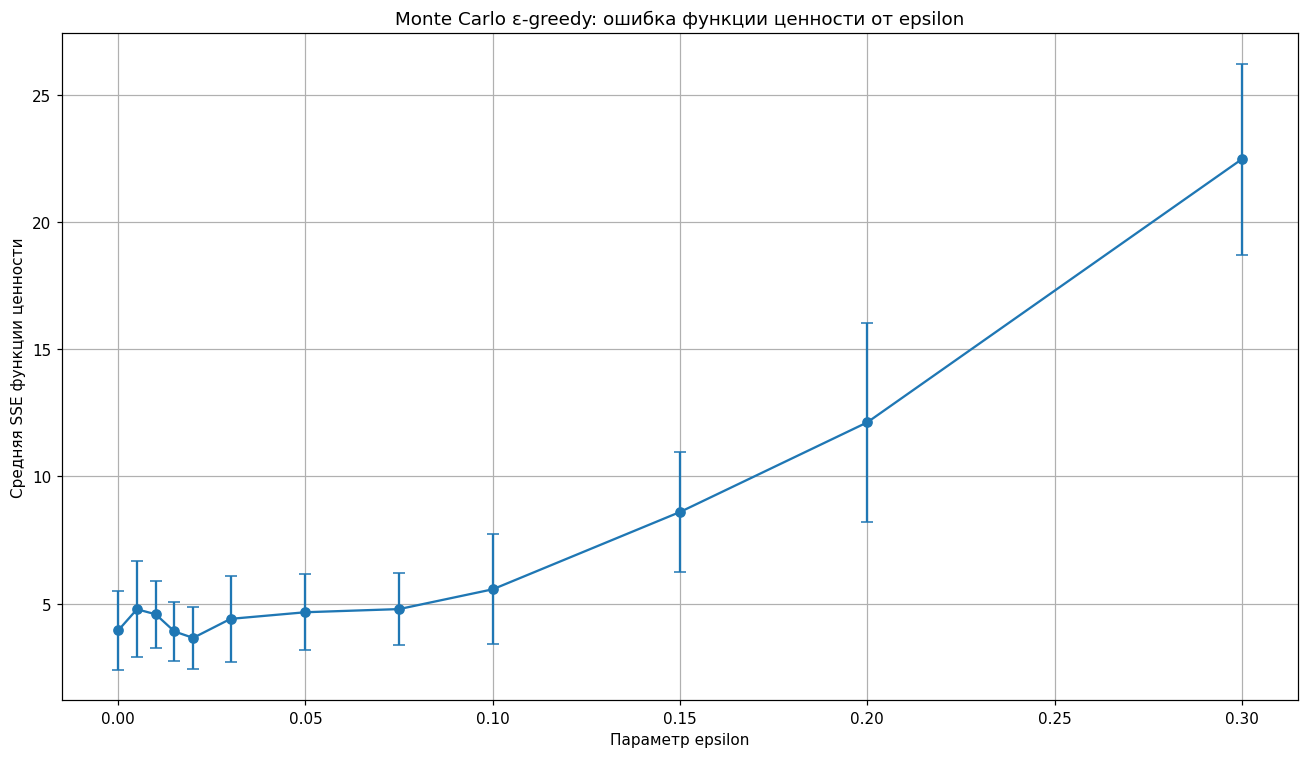

In [54]:
plt.figure(figsize=(12, 7), dpi=110)

plt.errorbar(
    df_mc_eps_epsilon_summary["epsilon"],
    df_mc_eps_epsilon_summary["mean_value_sse"],
    yerr=df_mc_eps_epsilon_summary["std_value_sse"],
    marker="o",
    capsize=4,
)

plt.xlabel("Параметр epsilon")
plt.ylabel("Средняя SSE функции ценности")
plt.title("Monte Carlo ε-greedy: ошибка функции ценности от epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

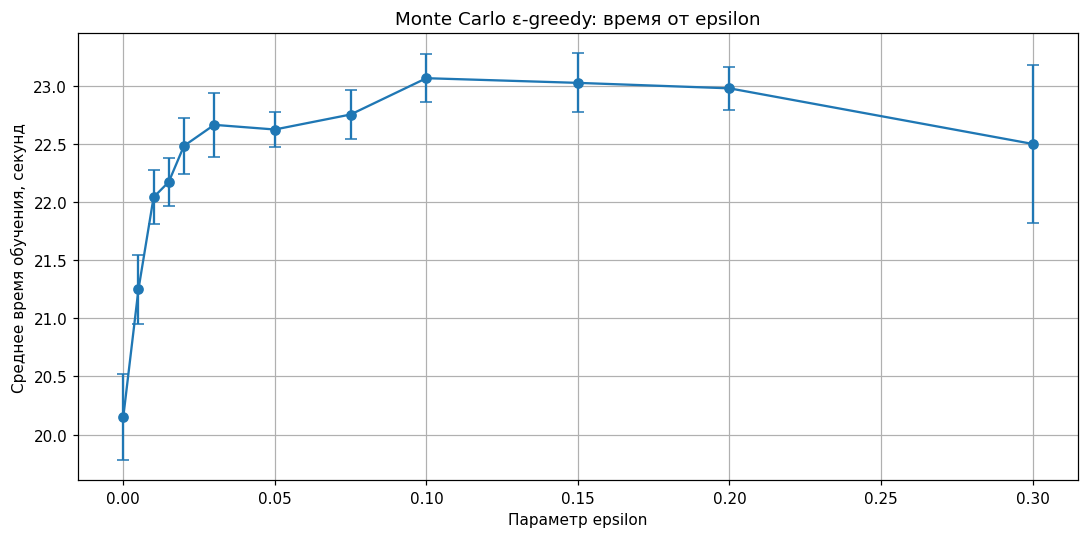

In [55]:
plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_eps_epsilon_summary["epsilon"],
    df_mc_eps_epsilon_summary["mean_training_time"],
    yerr=df_mc_eps_epsilon_summary["std_training_time"],
    marker="o",
    capsize=4,
)

plt.xlabel("Параметр epsilon")
plt.ylabel("Среднее время обучения, секунд")
plt.title("Monte Carlo ε-greedy: время от epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по влиянию параметра ε

В данном эксперименте исследовалось влияние параметра `epsilon` на качество метода Монте-Карло с единой ε-жадной политикой. Остальные параметры были зафиксированы:

$$
\texttt{num\_episodes} = 3000, \qquad \alpha = 0.015, \qquad \texttt{max\_steps} = 150.
$$

Для каждого значения `epsilon` метод запускался несколько раз с разными `random_seed`. После этого вычислялись основная метрика ошибки функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2
$$

и дополнительная метрика совпадения найденной политики с эталонной политикой Value Iteration.

По графику совпадения политик видно, что малые значения `epsilon` дают высокое качество. При этом слишком большие значения `epsilon` ухудшают результат, так как агент слишком часто выбирает случайные действия.

По основной метрике $\mathrm{SSE}_V$ лучшим значением среди рассмотренных вариантов является

$$
\epsilon = 0.02.
$$

Для него получено минимальное среднее значение ошибки функции ценности:

$$
\mathrm{mean\_SSE}_V \approx 3.65.
$$

При этом совпадение с эталонной политикой также остаётся очень высоким:

$$
\mathrm{mean\_policy\_match} \approx 0.998.
$$

Значение `epsilon = 0` тоже даёт хороший результат, так как в эксперименте используется случайный старт эпизодов. Поэтому даже без случайного выбора действий метод получает достаточно широкий охват состояний. Однако небольшое положительное значение `epsilon = 0.02` дополнительно улучшает исследование действий и даёт меньшую ошибку функции ценности.

При дальнейшем увеличении `epsilon` ошибка функции ценности начинает возрастать. Особенно заметное ухудшение наблюдается при `epsilon = 0.15`, `0.2` и `0.3`. В этом случае поведение агента становится слишком случайным, траектории становятся более шумными, а оценки $Q(s,a)$ менее устойчивыми.

Таким образом, для дальнейших экспериментов для метода Монте-Карло с единой ε-жадной политикой фиксируется значение

$$
\epsilon = 0.02.
$$

#### Локальный перебор параметров для Monte Carlo ε-greedy

После отдельного исследования параметра `epsilon` было видно, что лучшие результаты достигаются при малых положительных значениях этого параметра. Поэтому далее проводится локальный перебор комбинаций параметров в найденной хорошей области.

Так как задача, среда и критерий качества совпадают с предыдущим методом Monte Carlo ES, диапазоны для `num_episodes`, `alpha_lr` и `max_steps` берутся около уже найденных хороших значений. При этом дополнительно перебирается параметр `epsilon`, который является главным отличием данного метода.

Цель локального перебора — выбрать конфигурацию с хорошим компромиссом между:

- ошибкой функции ценности $\mathrm{SSE}_V$;
- средним совпадением с политикой Value Iteration;
- устойчивостью результата при разных `random_seed`;
- временем обучения.

In [57]:
def experiment_mc_eps_local_grid_parallel(
    num_episodes_list,
    alpha_list,
    epsilon_list,
    max_steps_list,
    seeds,
    gamma,
    random_start=True,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_eps_once_light)(
            num_episodes=num_episodes,
            alpha_lr=alpha_lr,
            gamma=gamma,
            epsilon=epsilon,
            max_steps=max_steps,
            random_seed=seed,
            random_start=random_start,
        )
        for num_episodes in num_episodes_list
        for alpha_lr in alpha_list
        for epsilon in epsilon_list
        for max_steps in max_steps_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby(
            [
                "num_episodes",
                "alpha_lr",
                "epsilon",
                "max_steps",
            ]
        )
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [58]:
num_episodes_list = [1500, 2000, 3000]
alpha_list = [0.01, 0.015, 0.02]
epsilon_list = [0.01, 0.02, 0.03]
max_steps_list = [100, 150, 200]

seeds = list(range(1, 11))

df_mc_eps_grid_raw, df_mc_eps_grid_summary = (
    experiment_mc_eps_local_grid_parallel(
        num_episodes_list=num_episodes_list,
        alpha_list=alpha_list,
        epsilon_list=epsilon_list,
        max_steps_list=max_steps_list,
        seeds=seeds,
        gamma=gamma,
        random_start=True,
        n_jobs=6,
    )
)

df_mc_eps_grid_summary

,num_episodes,alpha_lr,epsilon,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,1500,0.01,0.01,100,7.988888,4.345446,15.641353,3.351304,0.945098,0.862745,1.0,0.041130,7.965778,0.370896
1,1500,0.01,0.01,150,4.561713,3.115155,10.436838,2.133678,0.984314,0.941176,1.0,0.022261,12.912084,0.663588
2,1500,0.01,0.01,200,3.251319,2.481730,4.725362,0.806225,0.988235,0.960784,1.0,0.013710,17.421550,0.612204
3,1500,0.01,0.02,100,8.916945,4.632751,19.696308,4.743701,0.949020,0.843137,1.0,0.040502,7.583601,0.236993
4,1500,0.01,0.02,150,3.693256,2.391083,5.151804,0.863735,0.988235,0.960784,1.0,0.013710,11.923226,0.365577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,3000,0.02,0.02,150,6.692220,3.491722,14.384018,3.183069,0.998039,0.980392,1.0,0.006201,22.017643,0.229958
77,3000,0.02,0.02,200,5.623467,3.768096,8.770298,1.576729,0.992157,0.980392,1.0,0.010125,29.486233,0.261932
78,3000,0.02,0.03,100,6.352043,3.958105,8.436337,1.472980,0.992157,0.980392,1.0,0.010125,14.799395,0.179179
79,3000,0.02,0.03,150,5.344274,2.919573,8.649924,1.709102,0.994118,0.980392,1.0,0.009471,22.308467,0.218946


In [59]:
df_mc_eps_grid_best = (
    df_mc_eps_grid_summary
    .sort_values(
        by=[
            "mean_value_sse",
            "std_value_sse",
            "mean_policy_match",
            "mean_training_time",
        ],
        ascending=[True, True, False, True],
    )
    .reset_index(drop=True)
)

df_mc_eps_grid_best["rank"] = df_mc_eps_grid_best.index + 1

df_mc_eps_grid_best["config"] = (
    "ep=" + df_mc_eps_grid_best["num_episodes"].astype(str)
    + ", a=" + df_mc_eps_grid_best["alpha_lr"].astype(str)
    + ", eps=" + df_mc_eps_grid_best["epsilon"].astype(str)
    + ", steps=" + df_mc_eps_grid_best["max_steps"].astype(str)
)

df_mc_eps_grid_best[
    [
        "rank",
        "num_episodes",
        "alpha_lr",
        "epsilon",
        "max_steps",
        "mean_value_sse",
        "min_value_sse",
        "max_value_sse",
        "std_value_sse",
        "mean_policy_match",
        "min_policy_match",
        "max_policy_match",
        "std_policy_match",
        "mean_training_time",
        "std_training_time",
        "config",
    ]
]

,rank,num_episodes,alpha_lr,epsilon,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time,config
0,1,3000,0.010,0.01,150,2.829255,1.590774,3.995206,0.738733,0.994118,0.980392,1.0,0.009471,21.439281,0.187562,"ep=3000, a=0.01, eps=0.01, steps=150"
1,2,3000,0.010,0.02,150,2.829804,1.702958,4.412207,0.905675,0.994118,0.980392,1.0,0.009471,22.043733,0.148717,"ep=3000, a=0.01, eps=0.02, steps=150"
2,3,2000,0.010,0.01,200,2.833217,1.565843,4.104177,0.746908,0.992157,0.960784,1.0,0.013710,19.293237,0.085534,"ep=2000, a=0.01, eps=0.01, steps=200"
3,4,3000,0.010,0.01,200,2.941612,1.509657,5.077257,0.955347,0.988235,0.941176,1.0,0.018943,28.852492,0.344211,"ep=3000, a=0.01, eps=0.01, steps=200"
4,5,3000,0.010,0.03,200,3.030735,1.240539,4.970359,0.961674,0.996078,0.980392,1.0,0.008267,32.986777,2.594253,"ep=3000, a=0.01, eps=0.03, steps=200"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,77,1500,0.015,0.02,100,7.913720,3.985548,16.926787,4.107912,0.976471,0.901961,1.0,0.033070,7.961328,0.163589,"ep=1500, a=0.015, eps=0.02, steps=100"
77,78,1500,0.010,0.01,100,7.988888,4.345446,15.641353,3.351304,0.945098,0.862745,1.0,0.041130,7.965778,0.370896,"ep=1500, a=0.01, eps=0.01, steps=100"
78,79,1500,0.020,0.03,150,8.093814,3.388501,13.735811,3.027248,0.990196,0.960784,1.0,0.013865,10.985897,0.136091,"ep=1500, a=0.02, eps=0.03, steps=150"
79,80,2000,0.020,0.01,100,8.433146,3.700195,16.810803,4.459977,0.982353,0.960784,1.0,0.014468,9.648206,0.090754,"ep=2000, a=0.02, eps=0.01, steps=100"


In [60]:
print(
    df_mc_eps_grid_best[
        [
        "rank",
        "num_episodes",
        "alpha_lr",
        "epsilon",
        "max_steps",
        "mean_value_sse",
        "min_value_sse",
        "max_value_sse",
        "std_value_sse",
        "mean_policy_match",
        "min_policy_match",
        "max_policy_match",
        "std_policy_match",
        "mean_training_time",
        "std_training_time",
        "config",
    ]
    ].head(20).to_string(index=False)
)

 rank  num_episodes  alpha_lr  epsilon  max_steps  mean_value_sse  min_value_sse  max_value_sse  std_value_sse  mean_policy_match  min_policy_match  max_policy_match  std_policy_match  mean_training_time  std_training_time                                config
    1          3000     0.010     0.01        150        2.829255       1.590774       3.995206       0.738733           0.994118          0.980392               1.0          0.009471           21.439281           0.187562  ep=3000, a=0.01, eps=0.01, steps=150
    2          3000     0.010     0.02        150        2.829804       1.702958       4.412207       0.905675           0.994118          0.980392               1.0          0.009471           22.043733           0.148717  ep=3000, a=0.01, eps=0.02, steps=150
    3          2000     0.010     0.01        200        2.833217       1.565843       4.104177       0.746908           0.992157          0.960784               1.0          0.013710           19.293237           0.0

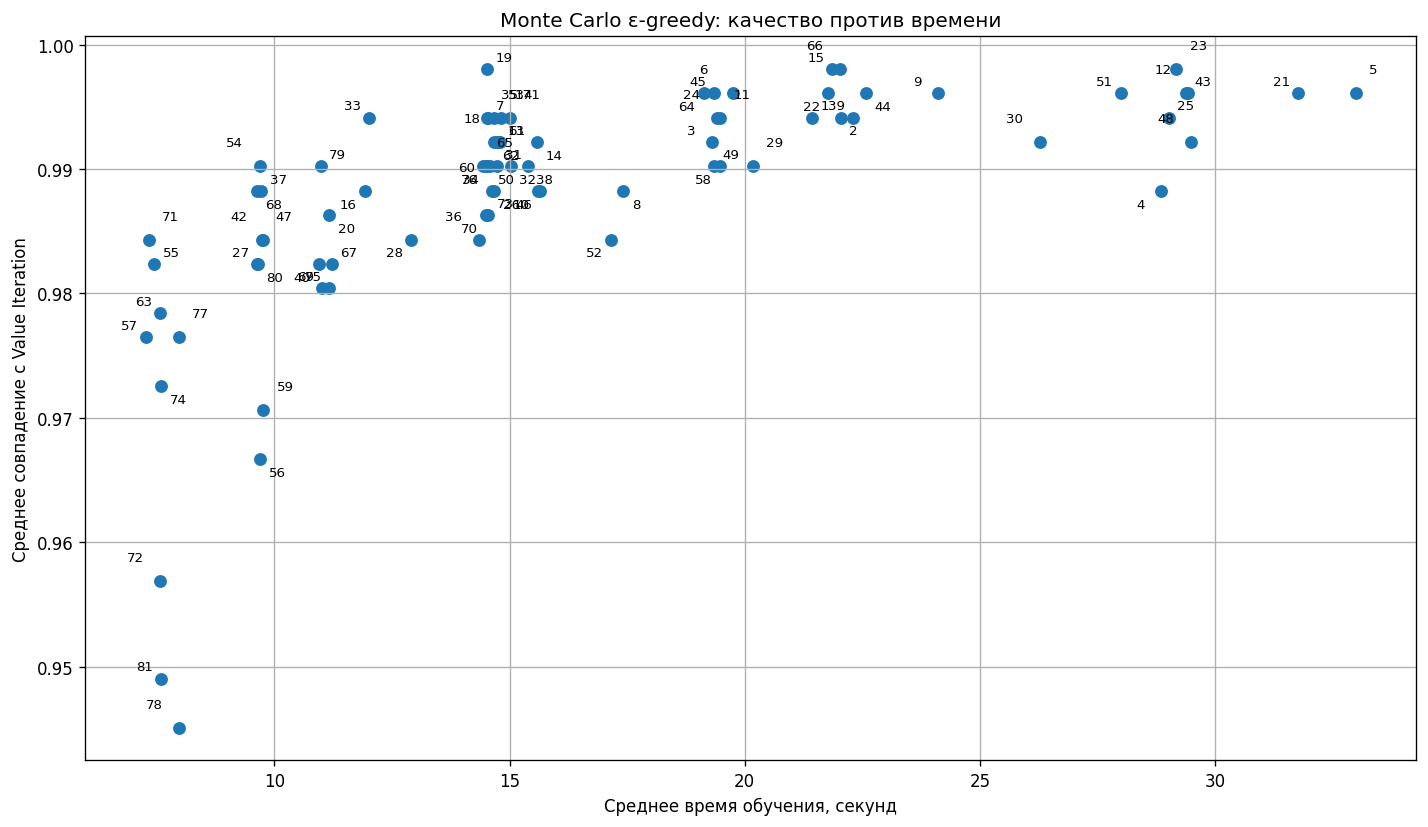

In [61]:
plt.figure(figsize=(12, 7), dpi=120)

plt.scatter(
    df_mc_eps_grid_best["mean_training_time"],
    df_mc_eps_grid_best["mean_policy_match"],
    s=45,
)

offsets = [
    (5, 5),
    (5, -10),
    (-15, 5),
    (-15, -10),
    (8, 12),
    (-20, 12),
]

for i, row in df_mc_eps_grid_best.iterrows():
    dx, dy = offsets[i % len(offsets)]

    plt.annotate(
        str(int(row["rank"])),
        (
            row["mean_training_time"],
            row["mean_policy_match"],
        ),
        fontsize=8,
        xytext=(dx, dy),
        textcoords="offset points",
    )

plt.xlabel("Среднее время обучения, секунд")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Monte Carlo ε-greedy: качество против времени")
plt.grid(True)
plt.tight_layout()
plt.show()

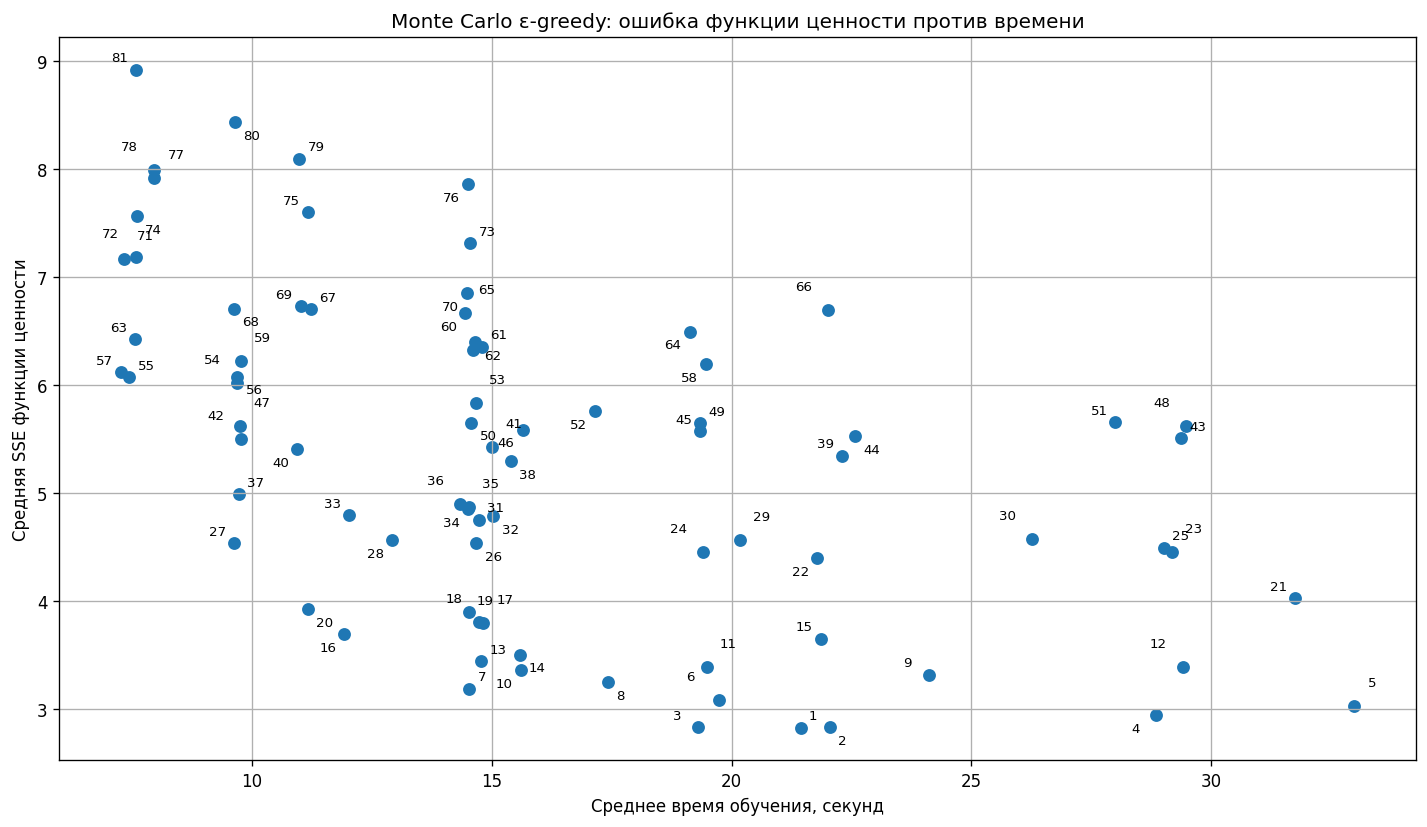

In [62]:
plt.figure(figsize=(12, 7), dpi=120)

plt.scatter(
    df_mc_eps_grid_best["mean_training_time"],
    df_mc_eps_grid_best["mean_value_sse"],
    s=45,
)

offsets = [
    (5, 5),
    (5, -10),
    (-15, 5),
    (-15, -10),
    (8, 12),
    (-20, 12),
]

for i, row in df_mc_eps_grid_best.iterrows():
    dx, dy = offsets[i % len(offsets)]

    plt.annotate(
        str(int(row["rank"])),
        (
            row["mean_training_time"],
            row["mean_value_sse"],
        ),
        fontsize=8,
        xytext=(dx, dy),
        textcoords="offset points",
    )

plt.xlabel("Среднее время обучения, секунд")
plt.ylabel("Средняя SSE функции ценности")
plt.title("Monte Carlo ε-greedy: ошибка функции ценности против времени")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по локальному перебору параметров Monte Carlo ε-greedy

Локальный перебор показал, что метод Monte Carlo с единой ε-жадной политикой хорошо работает в найденной области параметров. Большинство рассмотренных конфигураций дают высокое совпадение с политикой Value Iteration, однако основной метрикой качества является ошибка функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

Поэтому лучшие параметры выбирались прежде всего по минимальному среднему значению $\mathrm{SSE}_V$, а метрика `policy_match` использовалась как дополнительная характеристика качества найденной стратегии.

По результатам локального перебора лучшей конфигурацией по основной метрике стала

$$
\texttt{num\_episodes} = 3000, \qquad
\alpha = 0.01, \qquad
\varepsilon = 0.01, \qquad
\texttt{max\_steps} = 150.
$$

Для этой конфигурации получено минимальное среднее значение ошибки функции ценности среди рассмотренных вариантов:

$$
\mathrm{mean\_SSE}_V \approx 2.83.
$$

При этом совпадение с эталонной политикой остаётся высоким:

$$
\mathrm{mean\_policy\_match} \approx 0.994.
$$

Близкий результат даёт конфигурация

$$
\texttt{num\_episodes} = 3000, \qquad
\alpha = 0.01, \qquad
\varepsilon = 0.02, \qquad
\texttt{max\_steps} = 150.
$$

Для неё ошибка функции ценности практически такая же:

$$
\mathrm{mean\_SSE}_V \approx 2.83,
$$

а совпадение с эталонной политикой также составляет примерно $0.994$. Однако первая конфигурация имеет немного меньшую ошибку и немного меньшее время обучения, поэтому она выбирается как итоговая.

Также видно, что конфигурации с `max_steps = 200` иногда дают близкую ошибку функции ценности, но требуют большего времени обучения. Поэтому увеличение длины эпизода до 200 в данном случае не даёт достаточного выигрыша.

Таким образом, для дальнейшего сравнения с другими методами выбирается конфигурация

$$
\texttt{num\_episodes} = 3000, \qquad
\alpha = 0.01, \qquad
\varepsilon = 0.01, \qquad
\texttt{max\_steps} = 150.
$$

Она даёт наименьшую ошибку функции ценности среди рассмотренных вариантов, сохраняет высокое совпадение найденной политики с эталонной и имеет приемлемое время обучения.

## Монте-Карло с разделёнными политиками и взвешенной выборкой по значимости

В методах с разделёнными политиками используются две разные политики:

- $b$ — поведенческая политика, по которой реально генерируются эпизоды;
- $\pi$ — целевая политика, которую нужно оценить и улучшить.

В данной работе поведенческая политика $b$ выбирается $\varepsilon$-жадной, чтобы агент продолжал исследовать разные действия. Целевая политика $\pi$ выбирается жадной по текущей оценке функции качества:

$$
\pi(s)=\arg\max_{a \in A} Q(s,a).
$$

Для $\varepsilon$-жадной поведенческой политики вероятность выбора действия имеет вид:

$$
b(a|s)=
\begin{cases}
1-\varepsilon+\dfrac{\varepsilon}{|A|}, & a = \arg\max\limits_{a' \in A} Q(s,a'),\\[6pt]
\dfrac{\varepsilon}{|A|}, & \text{иначе}.
\end{cases}
$$

Так как эпизоды генерируются по политике $b$, а оценить нужно целевую политику $\pi$, необходимо учитывать различие между этими политиками. Для этого используется отношение вероятностей траектории, или коэффициент выборки по значимости:

$$
\rho_{t:T-1}
=
\prod_{k=t}^{T-1}
\frac{\pi(a_k|s_k)}{b(a_k|s_k)}.
$$

Обычная оценка через выборку по значимости имеет вид:

$$
V(s)
=
\frac{
\sum_{t \in \mathcal{T}(s)}
\rho_{t:T(t)-1} G_t
}{
|\mathcal{T}(s)|
}.
$$

Однако такая оценка может иметь большую дисперсию. Если траектория совпадает с действиями целевой политики, то в произведении появляются множители вида $1 / b(a_k|s_k)$. Если вероятности этих действий при поведенческой политике малы, вес может быстро возрастать.

Поэтому на практике часто используют взвешенную выборку по значимости:

$$
V(s)
=
\frac{
\sum_{t \in \mathcal{T}(s)}
\rho_{t:T(t)-1} G_t
}{
\sum_{t \in \mathcal{T}(s)}
\rho_{t:T(t)-1}
}.
$$

Для функции качества действия аналогично оценивается не $V(s)$, а $Q(s,a)$:

$$
Q(s,a)
\approx
\frac{
\sum_i W_i G_i
}{
\sum_i W_i
},
$$

где $G_i$ — доход после посещения пары $(s,a)$, а $W_i$ — соответствующий вес выборки по значимости.

Чтобы не хранить все доходы и веса, используется инкрементальная форма обновления:

$$
C(s,a) \leftarrow C(s,a) + W,
$$

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\frac{W}{C(s,a)}
\left[
G - Q(s,a)
\right].
$$

Здесь:

- $C(s,a)$ — накопленная сумма весов для пары $(s,a)$;
- $W$ — текущий вес выборки по значимости;
- $G$ — дисконтированный доход;
- $Q(s,a)$ — текущая оценка качества действия.

В случае детерминированной жадной целевой политики $\pi$ вероятность $\pi(a|s)$ равна $1$, если действие совпадает с жадным, и $0$ иначе. Поэтому при обратном проходе по эпизоду обновления продолжаются только до тех пор, пока действия в эпизоде совпадают с действиями целевой политики. Если встретилось действие, которое целевая политика не выбрала бы, дальнейшее обновление прекращается, так как соответствующий множитель в весе становится равным нулю.

In [63]:
def epsilon_greedy_action_with_prob(Q, state, actions, epsilon, rng):
    greedy_action = choose_greedy_action_deterministic(
        Q,
        state,
        actions,
    )

    if rng.random() < epsilon:
        action = str(rng.choice(actions))
    else:
        action = greedy_action

    action_prob = epsilon / len(actions)

    if action == greedy_action:
        action_prob += 1.0 - epsilon

    return action, action_prob

In [65]:
def off_policy_mc_weighted_importance_sampling(
    env,
    states,
    actions,
    num_episodes,
    gamma,
    epsilon,
    random_seed=None,
    random_start=True,
):
    rng = np.random.default_rng(random_seed)

    Q = defaultdict(float)
    C = defaultdict(float)
    returns_history = []

    for _ in range(num_episodes):
        episode = []

        state = env.reset(random_start=random_start)
        done = False

        while not done:
            action, action_prob = epsilon_greedy_action_with_prob(
                Q,
                state,
                actions,
                epsilon,
                rng,
            )

            next_state, reward, done = env.step(action)

            episode.append(
                (state, action, reward, next_state, action_prob)
            )

            state = next_state

        G = 0.0
        W = 1.0

        for state, action, reward, _, action_prob in reversed(episode):
            G = reward + gamma * G

            C[(state, action)] += W

            Q[(state, action)] += (
                W / C[(state, action)]
            ) * (
                G - Q[(state, action)]
            )

            greedy_action = choose_greedy_action_deterministic(
                Q,
                state,
                actions,
            )

            if action != greedy_action:
                break

            W /= action_prob

        returns_history.append(
            discounted_episode_return(
                [
                    (state, action, reward, next_state)
                    for state, action, reward, next_state, _ in episode
                ],
                gamma,
            )
        )

    policy = build_greedy_policy(Q, states, actions)

    return Q, policy, returns_history

In [66]:
env_mc_weighted = QueueControlEnv(
    n=N,
    states=S,
    actions=A,
    arrival_probs=arrival_probs,
    service_probs=service_probs,
    reward_func=R,
    max_steps=100,
    start_state=0,
    random_seed=42,
)

Q_mc_weighted, PI_mc_weighted, returns_mc_weighted = (
    off_policy_mc_weighted_importance_sampling(
        env=env_mc_weighted,
        states=S,
        actions=A,
        num_episodes=10000,
        gamma=gamma,
        epsilon=0.1,
        random_seed=42,
        random_start=True,
    )
)

V_mc_weighted = q_to_value(Q_mc_weighted, S, A)
sse_mc_weighted = value_sse(V_mc_weighted, V_vi, S)
match_mc_weighted = policy_match_ratio(PI_mc_weighted, PI_vi, S)

print("Политика Монте-Карло с разделёнными политиками:")
for state in S:
    print(f"s = {state}, pi(s) = {PI_mc_weighted[state]}")

print("\nSSE функции ценности:", sse_mc_weighted)
print("Совпадение с политикой из Value Iteration:", match_mc_weighted)

Политика Монте-Карло с разделёнными политиками:
s = 0, pi(s) = off
s = 1, pi(s) = norm
s = 2, pi(s) = fast
s = 3, pi(s) = fast
s = 4, pi(s) = fast
s = 5, pi(s) = fast
s = 6, pi(s) = fast
s = 7, pi(s) = off
s = 8, pi(s) = norm
s = 9, pi(s) = norm
s = 10, pi(s) = off
s = 11, pi(s) = norm
s = 12, pi(s) = fast
s = 13, pi(s) = fast
s = 14, pi(s) = off
s = 15, pi(s) = off
s = 16, pi(s) = norm
s = 17, pi(s) = fast
s = 18, pi(s) = fast
s = 19, pi(s) = fast
s = 20, pi(s) = off
s = 21, pi(s) = fast
s = 22, pi(s) = fast
s = 23, pi(s) = fast
s = 24, pi(s) = fast
s = 25, pi(s) = off
s = 26, pi(s) = fast
s = 27, pi(s) = fast
s = 28, pi(s) = off
s = 29, pi(s) = norm
s = 30, pi(s) = off
s = 31, pi(s) = off
s = 32, pi(s) = fast
s = 33, pi(s) = off
s = 34, pi(s) = off
s = 35, pi(s) = fast
s = 36, pi(s) = fast
s = 37, pi(s) = fast
s = 38, pi(s) = fast
s = 39, pi(s) = fast
s = 40, pi(s) = norm
s = 41, pi(s) = off
s = 42, pi(s) = off
s = 43, pi(s) = off
s = 44, pi(s) = norm
s = 45, pi(s) = norm
s = 46, pi(

#### Исследование влияния параметра ε

Для off-policy Monte Carlo с взвешенной выборкой по значимости параметр `epsilon` задаёт поведенческую политику, которая генерирует эпизоды.

В этом методе различаются две политики:

- поведенческая политика $b$ — ε-жадная, по ней агент реально действует;
- целевая политика $\pi$ — жадная, именно её мы обучаем.

Если `epsilon` слишком маленький, поведенческая политика слабо исследует действия. Если `epsilon` слишком большой, агент слишком часто выбирает случайные действия, и траектория чаще отклоняется от целевой жадной политики. Тогда при обратном проходе по эпизоду чаще срабатывает остановка обновления, поскольку действие не совпадает с действием целевой политики.

Поэтому сначала проверяется широкий диапазон значений `epsilon`, чтобы найти рабочую область для данного метода.

Для метода Монте-Карло с разделёнными политиками также вычисляется основная метрика качества — сумма квадратов отклонений функции ценности от оптимальной:

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

Функция ценности восстанавливается из обученной функции качества действия по формуле

$$
V_{\mathrm{MC}}(s)=\max_{a\in A}Q_{\mathrm{MC}}(s,a).
$$

Пробный запуск показал, что метод с разделёнными политиками в данной задаче работает заметно хуже предыдущих вариантов. Найденная политика существенно отличается от эталонной политики Value Iteration. Совпадение политик составило только

$$
\mathrm{policy\_match} \approx 0.529,
$$

а ошибка функции ценности оказалась очень большой:

$$
\mathrm{SSE}_V \approx 54781.61.
$$

Такой результат связан с особенностями off-policy Monte Carlo с взвешенной выборкой по значимости. Эпизоды генерируются по поведенческой ε-жадной политике, но обновления выполняются относительно жадной целевой политики. Если при обратном проходе по эпизоду встречается действие, которое не совпадает с действием целевой политики, дальнейшее обновление прекращается. Из-за этого многие состояния и действия получают мало полезных обновлений.

Кроме того, веса выборки по значимости могут сильно отличаться для разных траекторий, что делает оценки $Q(s,a)$ менее устойчивыми. Поэтому для данного метода особенно важно исследовать параметр `epsilon`, так как он напрямую влияет на баланс между исследованием действий и согласованностью траекторий с целевой политикой.

In [67]:
def run_mc_weighted_once_light(
    num_episodes,
    gamma,
    epsilon,
    max_steps=100,
    random_seed=42,
    random_start=True,
):
    env_train = QueueControlEnv(
        n=N,
        states=S,
        actions=A,
        arrival_probs=arrival_probs,
        service_probs=service_probs,
        reward_func=R,
        max_steps=max_steps,
        start_state=0,
        random_seed=random_seed,
    )

    start_time = time.perf_counter()

    Q_mc_weighted, PI_mc_weighted, _ = off_policy_mc_weighted_importance_sampling(
        env=env_train,
        states=S,
        actions=A,
        num_episodes=num_episodes,
        gamma=gamma,
        epsilon=epsilon,
        random_seed=random_seed,
        random_start=random_start,
    )

    training_time = time.perf_counter() - start_time

    policy_match = policy_match_ratio(
        PI_mc_weighted,
        PI_vi,
        S,
    )
    V_mc_weighted = q_to_value(Q_mc_weighted, S, A)
    value_error_sse = value_sse(V_mc_weighted, V_vi, S)

    return {
        "num_episodes": num_episodes,
        "epsilon": epsilon,
        "max_steps": max_steps,
        "seed": random_seed,
        "policy_match": policy_match,
        "training_time": training_time,
        "value_sse": value_error_sse,
    }

In [68]:
def experiment_mc_weighted_epsilon_parallel(
    epsilon_list,
    seeds,
    num_episodes,
    gamma,
    max_steps=100,
    random_start=True,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_weighted_once_light)(
            num_episodes=num_episodes,
            gamma=gamma,
            epsilon=epsilon,
            max_steps=max_steps,
            random_seed=seed,
            random_start=random_start,
        )
        for epsilon in epsilon_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby("epsilon")
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [69]:
epsilon_list = [
    0.01,
    0.02,
    0.05,
    0.1,
    0.15,
    0.2,
    0.3,
    0.4,
]

seeds = list(range(1, 11))

df_mc_weighted_epsilon_raw, df_mc_weighted_epsilon_summary = (
    experiment_mc_weighted_epsilon_parallel(
        epsilon_list=epsilon_list,
        seeds=seeds,
        num_episodes=20000,
        gamma=gamma,
        max_steps=100,
        random_start=True,
        n_jobs=6,
    )
)

df_mc_weighted_epsilon_summary

,epsilon,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,0.01,49173.806400,41577.519126,63113.092364,6055.515991,0.537255,0.313725,0.843137,0.165658,81.786577,1.429877
1,0.02,45837.629050,38368.514346,56396.043556,5292.000798,0.598039,0.470588,0.705882,0.076362,81.863028,2.157260
2,0.05,50522.957859,39177.584056,88290.018025,14668.954825,0.547059,0.333333,0.745098,0.130539,84.273827,1.781409
3,0.10,41783.415331,34208.465569,50049.572638,4188.847343,0.588235,0.411765,0.725490,0.105389,83.623500,0.915830
4,0.15,42629.481158,38422.450578,49526.262213,4055.661201,0.619608,0.470588,0.745098,0.080687,84.973659,0.643843
5,0.20,41133.624008,35172.717985,45720.585905,3224.649030,0.541176,0.431373,0.647059,0.066139,87.022236,0.665301
6,0.30,43353.496151,40725.480418,50841.555418,3139.113363,0.543137,0.411765,0.745098,0.108209,90.173137,0.702480
7,0.40,43404.064210,40340.557182,45521.992637,1406.418907,0.449020,0.274510,0.627451,0.097142,87.293048,11.427336


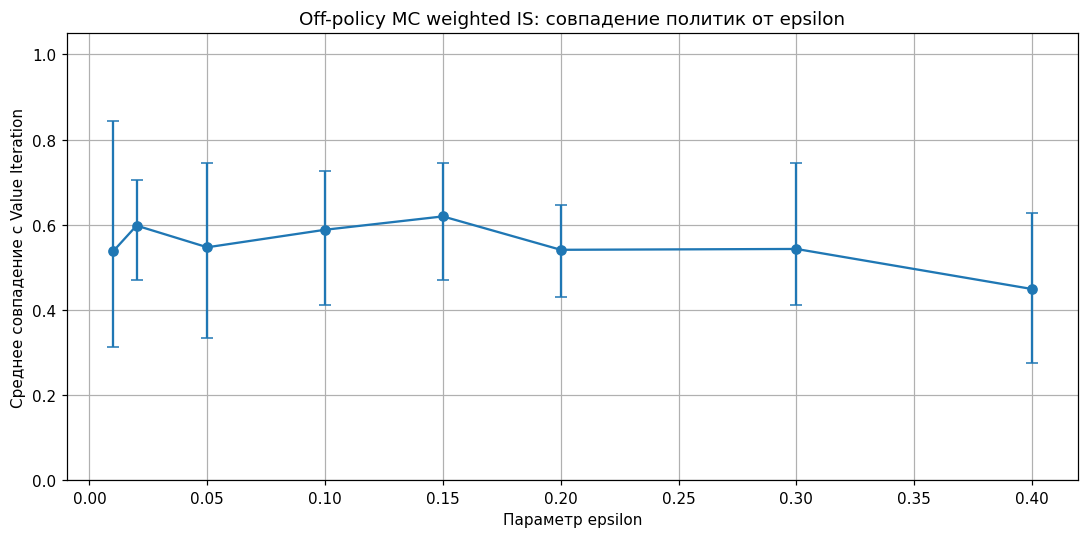

In [102]:
lower_error = (
    df_mc_weighted_epsilon_summary["mean_policy_match"]
    - df_mc_weighted_epsilon_summary["min_policy_match"]
)

upper_error = (
    df_mc_weighted_epsilon_summary["max_policy_match"]
    - df_mc_weighted_epsilon_summary["mean_policy_match"]
)

plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_weighted_epsilon_summary["epsilon"],
    df_mc_weighted_epsilon_summary["mean_policy_match"],
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
)

plt.ylim(0, 1.05)

plt.xlabel("Параметр epsilon")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Off-policy MC weighted IS: совпадение политик от epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

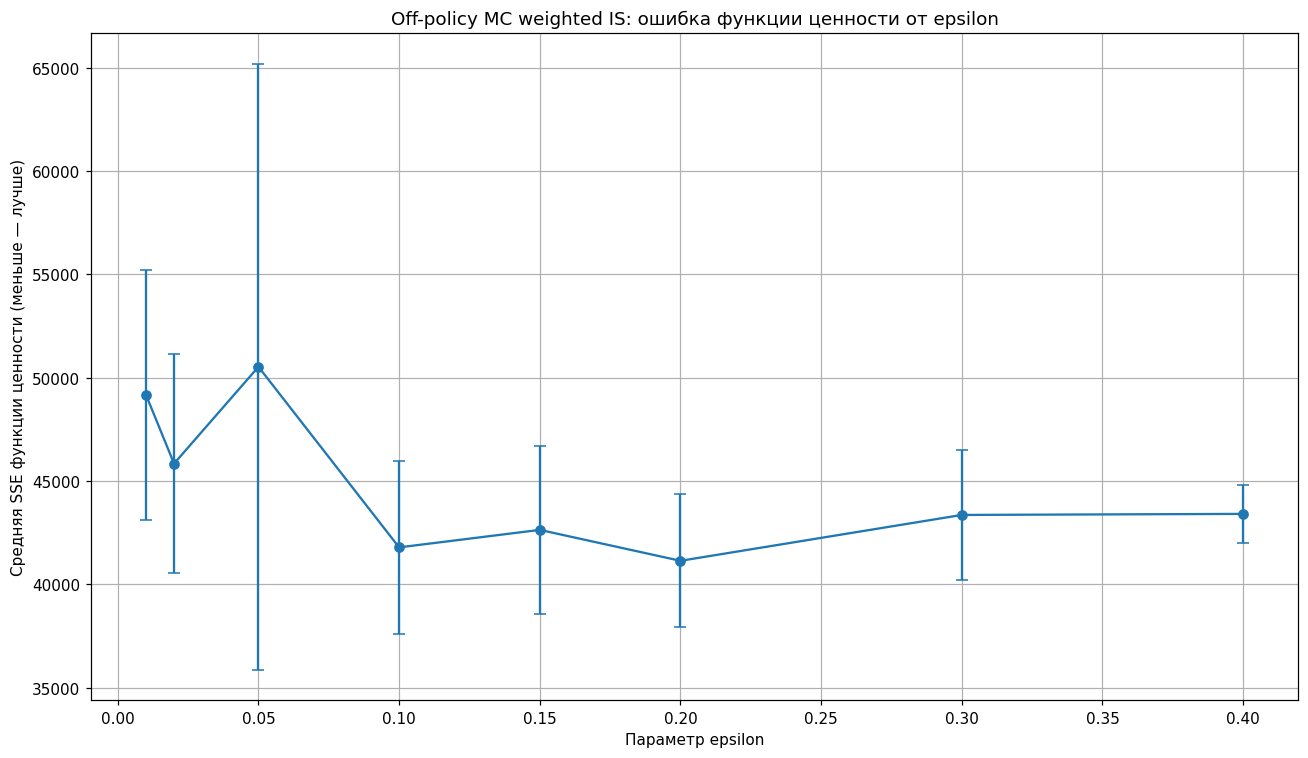

In [71]:
plt.figure(figsize=(12, 7), dpi=110)

plt.errorbar(
    df_mc_weighted_epsilon_summary["epsilon"],
    df_mc_weighted_epsilon_summary["mean_value_sse"],
    yerr=df_mc_weighted_epsilon_summary["std_value_sse"],
    marker="o",
    capsize=4,
)

plt.xlabel("Параметр epsilon")
plt.ylabel("Средняя SSE функции ценности (меньше — лучше)")
plt.title("Off-policy MC weighted IS: ошибка функции ценности от epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

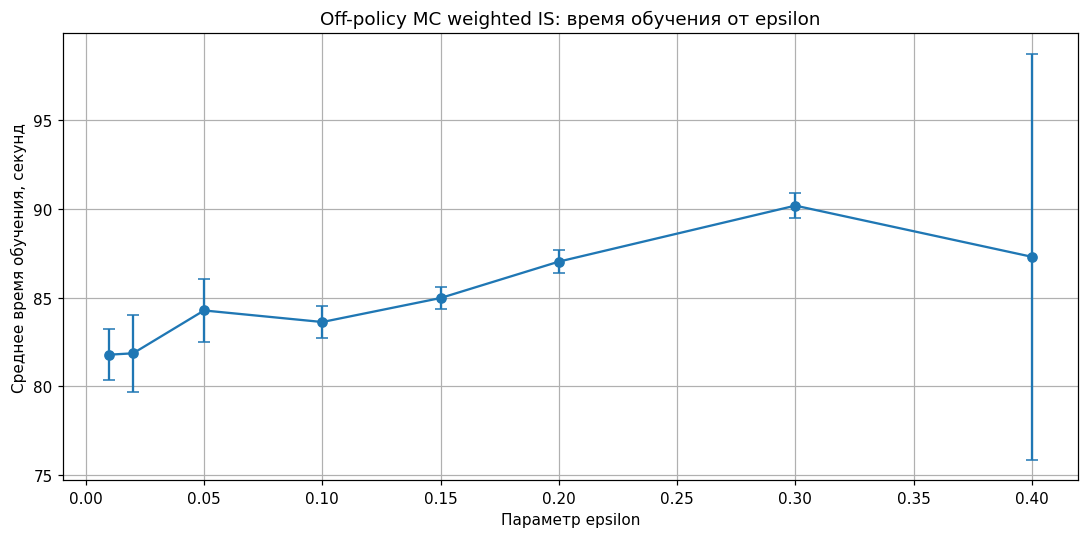

In [72]:
plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_weighted_epsilon_summary["epsilon"],
    df_mc_weighted_epsilon_summary["mean_training_time"],
    yerr=df_mc_weighted_epsilon_summary["std_training_time"],
    marker="o",
    capsize=4,
)

plt.xlabel("Параметр epsilon")
plt.ylabel("Среднее время обучения, секунд")
plt.title("Off-policy MC weighted IS: время обучения от epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
def off_policy_mc_weighted_diagnostics(
    env,
    states,
    actions,
    num_episodes,
    gamma,
    epsilon,
    random_seed=None,
    random_start=True,
):
    rng = np.random.default_rng(random_seed)

    Q = defaultdict(float)
    C = defaultdict(float)

    episode_lengths = []
    used_update_counts = []
    break_counts = 0

    for _ in range(num_episodes):
        episode = []

        state = env.reset(random_start=random_start)
        done = False

        while not done:
            action, action_prob = epsilon_greedy_action_with_prob(
                Q,
                state,
                actions,
                epsilon,
                rng,
            )

            next_state, reward, done = env.step(action)

            episode.append(
                (state, action, reward, next_state, action_prob)
            )

            state = next_state

        G = 0.0
        W = 1.0
        used_updates = 0
        was_break = False

        for state, action, reward, _, action_prob in reversed(episode):
            G = reward + gamma * G

            C[(state, action)] += W

            Q[(state, action)] += (
                W / C[(state, action)]
            ) * (
                G - Q[(state, action)]
            )

            used_updates += 1

            greedy_action = choose_greedy_action_deterministic(
                Q,
                state,
                actions,
            )

            if action != greedy_action:
                was_break = True
                break

            W /= action_prob

        episode_lengths.append(len(episode))
        used_update_counts.append(used_updates)

        if was_break:
            break_counts += 1

    policy = build_greedy_policy(Q, states, actions)
    V_mc_weighted = q_to_value(Q, states, actions)
    value_error_sse = value_sse(V_mc_weighted, V_vi, states)

    diagnostics = {
        "mean_episode_length": np.mean(episode_lengths),
        "mean_used_updates": np.mean(used_update_counts),
        "min_used_updates": np.min(used_update_counts),
        "max_used_updates": np.max(used_update_counts),
        "break_ratio": break_counts / num_episodes,
        "policy_match": policy_match_ratio(policy, PI_vi, states),
        "value_sse": value_error_sse,
    }

    return Q, policy, diagnostics

In [77]:
env_diag = QueueControlEnv(
    n=N,
    states=S,
    actions=A,
    arrival_probs=arrival_probs,
    service_probs=service_probs,
    reward_func=R,
    max_steps=100,
    start_state=0,
    random_seed=42,
)

Q_diag, PI_diag, diag = off_policy_mc_weighted_diagnostics(
    env=env_diag,
    states=S,
    actions=A,
    num_episodes=5000,
    gamma=gamma,
    epsilon=0.1,
    random_seed=42,
    random_start=True,
)

print("Диагностика off-policy MC weighted IS")
print("-" * 50)

print("Число эпизодов: 5000")
print("Параметр epsilon: 0.1")
print("Максимальная длина эпизода: 100")

print("-" * 50)

print(
    "Средняя длина эпизода:",
    round(float(diag["mean_episode_length"]), 2),
)

print(
    "Среднее число реально использованных обновлений:",
    round(float(diag["mean_used_updates"]), 2),
)

print(
    "Минимальное число использованных обновлений:",
    int(diag["min_used_updates"]),
)

print(
    "Максимальное число использованных обновлений:",
    int(diag["max_used_updates"]),
)

print(
    "Доля эпизодов, где сработал break:",
    round(float(diag["break_ratio"]), 4),
)

print(
    "SSE функции ценности:",
    round(float(diag["value_sse"]), 2),
)

print(
    "Совпадение итоговой политики с Value Iteration:",
    round(float(diag["policy_match"]), 4),
)

Диагностика off-policy MC weighted IS
--------------------------------------------------
Число эпизодов: 5000
Параметр epsilon: 0.1
Максимальная длина эпизода: 100
--------------------------------------------------
Средняя длина эпизода: 100.0
Среднее число реально использованных обновлений: 4.99
Минимальное число использованных обновлений: 1
Максимальное число использованных обновлений: 34
Доля эпизодов, где сработал break: 1.0
SSE функции ценности: 63701.45
Совпадение итоговой политики с Value Iteration: 0.6275


#### Проверка влияния длины эпизода для off-policy MC

Диагностика показала, что при `max_steps = 100` метод off-policy Monte Carlo с weighted importance sampling использует только небольшую часть эпизода. Средняя длина эпизода равна 100 шагам, однако среднее число реально использованных обновлений составляет только около 5:

$$
\mathrm{mean\_episode\_length} = 100,
\qquad
\mathrm{mean\_used\_updates} \approx 4.99.
$$

Кроме того, доля эпизодов, в которых сработала остановка обратного прохода, равна

$$
\mathrm{break\_ratio} = 1.
$$

Это означает, что практически в каждом эпизоде обратное обновление прекращается раньше конца траектории. Причина состоит в том, что при несовпадении действия поведенческой политики с текущей жадной целевой политикой дальнейшее обновление не выполняется.

Следовательно, увеличение длины эпизода не обязательно улучшает качество обучения: большая часть траектории может не использоваться при обновлении $Q(s,a)$. Более того, длинные эпизоды увеличивают время работы метода, но не дают пропорционального прироста полезной информации для обучения.

Это подтверждается и качеством пробного запуска: ошибка функции ценности остаётся очень большой,

$$
\mathrm{SSE}_V \approx 63701.45,
$$

а совпадение найденной политики с эталонной составляет только

$$
\mathrm{policy\_match} \approx 0.628.
$$

Поэтому дополнительно проверяются меньшие значения `max_steps`. Если короткие эпизоды дают сопоставимое качество, то их использование может быть более выгодным по времени.

In [78]:
def experiment_mc_weighted_max_steps_parallel(
    max_steps_list,
    seeds,
    num_episodes,
    gamma,
    epsilon,
    random_start=True,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_weighted_once_light)(
            num_episodes=num_episodes,
            gamma=gamma,
            epsilon=epsilon,
            max_steps=max_steps,
            random_seed=seed,
            random_start=random_start,
        )
        for max_steps in max_steps_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby("max_steps")
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [79]:
max_steps_list = [
    20,
    30,
    40,
    50,
]

seeds = list(range(1, 7))

df_mc_weighted_steps_raw, df_mc_weighted_steps_summary = (
    experiment_mc_weighted_max_steps_parallel(
        max_steps_list=max_steps_list,
        seeds=seeds,
        num_episodes=50000,
        gamma=gamma,
        epsilon=0.2,
        random_start=True,
        n_jobs=6,
    )
)

df_mc_weighted_steps_summary

,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,20,31529.602018,30141.805552,33039.987020,1245.930361,0.532680,0.411765,0.607843,0.067260,45.517771,0.513242
1,30,30811.774981,27918.387805,32362.222727,1667.455746,0.558824,0.470588,0.647059,0.079163,63.400410,0.647950
2,40,31876.719048,31011.100891,32555.175946,682.540505,0.558824,0.431373,0.686275,0.084791,85.497539,0.629020
3,50,30963.812108,29737.355441,32098.574530,932.066699,0.568627,0.470588,0.666667,0.078431,107.273829,0.250732


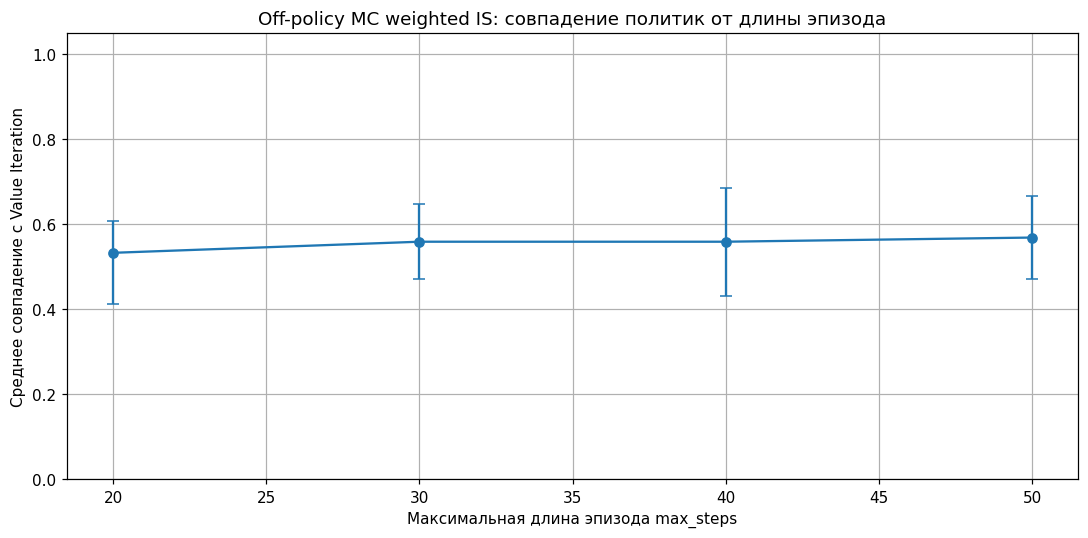

In [80]:
lower_error = (
    df_mc_weighted_steps_summary["mean_policy_match"]
    - df_mc_weighted_steps_summary["min_policy_match"]
)

upper_error = (
    df_mc_weighted_steps_summary["max_policy_match"]
    - df_mc_weighted_steps_summary["mean_policy_match"]
)

plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_weighted_steps_summary["max_steps"],
    df_mc_weighted_steps_summary["mean_policy_match"],
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
)

plt.ylim(0, 1.05)

plt.xlabel("Максимальная длина эпизода max_steps")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Off-policy MC weighted IS: совпадение политик от длины эпизода")
plt.grid(True)
plt.tight_layout()
plt.show()

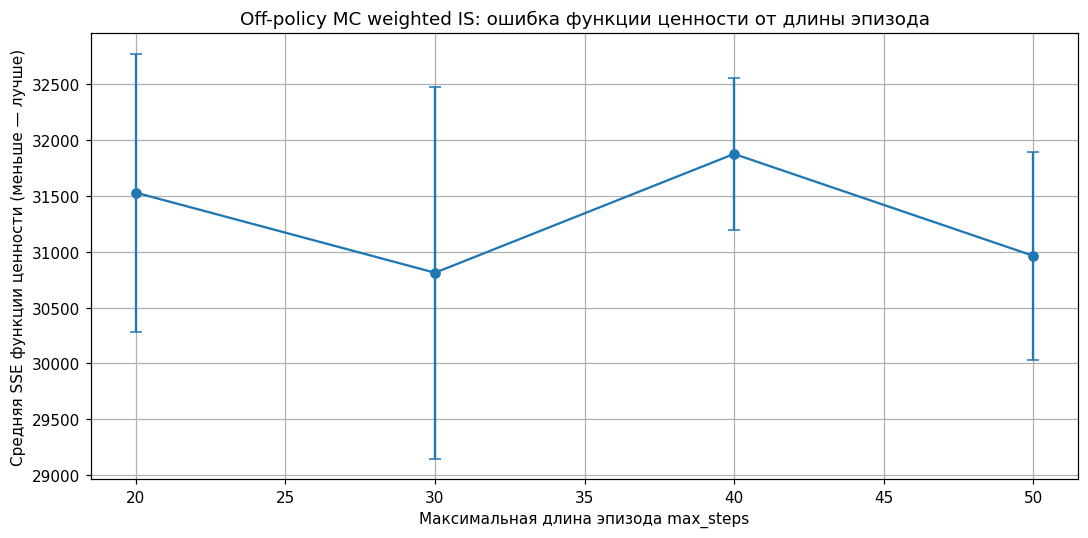

In [81]:
plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_weighted_steps_summary["max_steps"],
    df_mc_weighted_steps_summary["mean_value_sse"],
    yerr=df_mc_weighted_steps_summary["std_value_sse"],
    marker="o",
    capsize=4,
)

plt.xlabel("Максимальная длина эпизода max_steps")
plt.ylabel("Средняя SSE функции ценности (меньше — лучше)")
plt.title("Off-policy MC weighted IS: ошибка функции ценности от длины эпизода")
plt.grid(True)
plt.tight_layout()
plt.show()

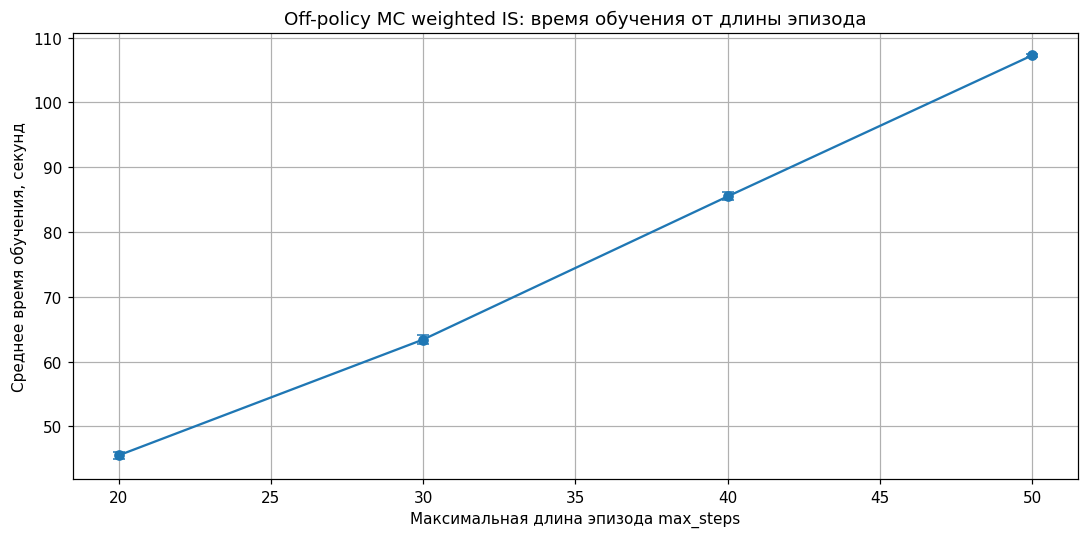

In [82]:
plt.figure(figsize=(10, 5), dpi=110)

plt.errorbar(
    df_mc_weighted_steps_summary["max_steps"],
    df_mc_weighted_steps_summary["mean_training_time"],
    yerr=df_mc_weighted_steps_summary["std_training_time"],
    marker="o",
    capsize=4,
)

plt.xlabel("Максимальная длина эпизода max_steps")
plt.ylabel("Среднее время обучения, секунд")
plt.title("Off-policy MC weighted IS: время обучения от длины эпизода")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по влиянию длины эпизода

Дополнительный эксперимент показал, что длина эпизода влияет прежде всего на время работы метода off-policy Monte Carlo с weighted importance sampling. Качество оценивалось по двум метрикам: совпадению найденной стратегии с эталонной стратегией Value Iteration и ошибке функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

При всех рассмотренных значениях `max_steps` качество метода остаётся низким. Среднее совпадение с эталонной стратегией находится примерно в диапазоне от $0.53$ до $0.57$. Это означает, что найденная стратегия существенно отличается от стратегии Value Iteration.

По дополнительной метрике совпадения политик лучший средний результат был получен при

$$
max\_steps = 50.
$$

Для этого значения

$$
mean\_policy\_match \approx 0.569.
$$

Однако по основной метрике $\mathrm{SSE}_V$ лучший результат среди рассмотренных вариантов достигается при

$$
max\_steps = 30.
$$

При этом значение ошибки функции ценности минимально:

$$
mean\_value\_sse \approx 30811.77.
$$

Различие между метриками показывает, что увеличение длины эпизода может немного улучшать совпадение итоговой стратегии с эталонной, но не обязательно улучшает численное приближение функции ценности.

При этом время обучения заметно растёт с увеличением `max_steps`: от примерно 45 секунд при `max_steps = 20` до примерно 107 секунд при `max_steps = 50`. Поэтому увеличение длины эпизода приводит к росту вычислительных затрат, но не даёт сопоставимого улучшения качества.

В любом случае значения $\mathrm{SSE}_V$ остаются очень большими по сравнению с методами Monte Carlo с исследовательскими стартами и с единой $\varepsilon$-жадной политикой. Это подтверждает, что проблема метода связана не только с выбором длины эпизода, но и с самой структурой weighted importance sampling. Из-за несовпадения действий поведенческой и целевой политик обратный проход часто обрывается, поэтому значительная часть собранной траектории не используется для обновления оценок $Q(s,a)$.

Таким образом, если ориентироваться на основную метрику $\mathrm{SSE}_V$, лучшим значением среди проверенных является

$$
max\_steps = 30.
$$

Однако даже при этом значении off-policy MC weighted IS существенно уступает двум предыдущим методам.

#### Грубый перебор параметров off-policy Monte Carlo

После диагностики стало видно, что метод off-policy Monte Carlo с weighted importance sampling использует только небольшую часть каждого эпизода. Поэтому большой локальный перебор параметров нецелесообразен: он будет долго считаться и, скорее всего, не даст качества, сопоставимого с предыдущими методами.

Тем не менее, чтобы не выбирать параметры вручную, проведём небольшой грубый перебор. Будем менять число эпизодов, параметр `epsilon` и длину эпизода `max_steps`.

Цель эксперимента — найти лучший результат в разумной небольшой области параметров и оценить, насколько данный метод подходит для рассматриваемой задачи. В качестве основной метрики используется ошибка функции ценности $\mathrm{SSE}_V$, а совпадение политик рассматривается как дополнительная метрика.

In [84]:
def experiment_mc_weighted_grid_parallel(
    num_episodes_list,
    epsilon_list,
    max_steps_list,
    seeds,
    gamma,
    random_start=True,
    n_jobs=6,
):
    rows = Parallel(n_jobs=n_jobs)(
        delayed(run_mc_weighted_once_light)(
            num_episodes=num_episodes,
            gamma=gamma,
            epsilon=epsilon,
            max_steps=max_steps,
            random_seed=seed,
            random_start=random_start,
        )
        for num_episodes in num_episodes_list
        for epsilon in epsilon_list
        for max_steps in max_steps_list
        for seed in seeds
    )

    df_raw = pd.DataFrame(rows)

    df_summary = (
        df_raw
        .groupby(["num_episodes", "epsilon", "max_steps"])
        .agg(
            mean_value_sse=("value_sse", "mean"),
            min_value_sse=("value_sse", "min"),
            max_value_sse=("value_sse", "max"),
            std_value_sse=("value_sse", "std"),
            mean_policy_match=("policy_match", "mean"),
            min_policy_match=("policy_match", "min"),
            max_policy_match=("policy_match", "max"),
            std_policy_match=("policy_match", "std"),
            mean_training_time=("training_time", "mean"),
            std_training_time=("training_time", "std"),
        )
        .reset_index()
    )

    return df_raw, df_summary

In [85]:
num_episodes_list = [20000, 50000]

epsilon_list = [
    0.1,
    0.15,
    0.2,
]

max_steps_list = [
    20,
    30,
    50,
]

seeds = list(range(1, 7))

df_mc_weighted_grid_raw, df_mc_weighted_grid_summary = (
    experiment_mc_weighted_grid_parallel(
        num_episodes_list=num_episodes_list,
        epsilon_list=epsilon_list,
        max_steps_list=max_steps_list,
        seeds=seeds,
        gamma=gamma,
        random_start=True,
        n_jobs=6,
    )
)

df_mc_weighted_grid_summary

,num_episodes,epsilon,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time
0,20000,0.10,20,38818.516214,35024.289461,41397.285818,2218.903447,0.486928,0.333333,0.647059,0.114612,17.314557,0.283675
1,20000,0.10,30,39841.598500,37715.728088,43459.312169,2049.885740,0.444444,0.294118,0.666667,0.161532,25.683215,0.345273
2,20000,0.10,50,40389.463630,38266.075859,41924.158335,1371.803443,0.411765,0.352941,0.490196,0.048029,44.666478,0.689959
3,20000,0.15,20,37237.217438,35304.699306,40704.280339,2044.962150,0.477124,0.372549,0.607843,0.078104,17.434141,0.109649
4,20000,0.15,30,39627.282746,37791.646739,42448.561294,1652.939278,0.431373,0.333333,0.529412,0.087689,25.626119,0.214011
5,20000,0.15,50,38311.394576,36287.357141,41628.116873,1878.135598,0.506536,0.450980,0.568627,0.061278,42.739136,0.605932
6,20000,0.20,20,41048.129142,38414.422973,42872.914644,1869.068283,0.437908,0.313725,0.568627,0.089138,17.602397,0.152933
7,20000,0.20,30,39896.975007,36318.383948,41597.889761,2064.242271,0.447712,0.372549,0.568627,0.072752,26.336082,0.426153
8,20000,0.20,50,39461.162637,37954.482258,40418.904281,849.536059,0.490196,0.372549,0.607843,0.092801,43.729504,0.544564
9,50000,0.10,20,29837.412307,26971.829525,32327.457575,1844.595800,0.519608,0.411765,0.607843,0.064139,43.639041,0.443712


In [86]:
df_mc_weighted_grid_best = (
    df_mc_weighted_grid_summary
    .sort_values(
        by=[
            "mean_value_sse",
            "std_value_sse",
            "mean_policy_match",
            "mean_training_time",
        ],
        ascending=[True, True, False, True],
    )
    .reset_index(drop=True)
)

df_mc_weighted_grid_best["rank"] = (
    df_mc_weighted_grid_best.index + 1
)

df_mc_weighted_grid_best["config"] = (
    "ep=" + df_mc_weighted_grid_best["num_episodes"].astype(str)
    + ", eps=" + df_mc_weighted_grid_best["epsilon"].astype(str)
    + ", steps=" + df_mc_weighted_grid_best["max_steps"].astype(str)
)

df_mc_weighted_grid_best[
    [
        "rank",
        "num_episodes",
        "epsilon",
        "max_steps",
        "mean_value_sse",
        "min_value_sse",
        "max_value_sse",
        "std_value_sse",
        "mean_policy_match",
        "min_policy_match",
        "max_policy_match",
        "std_policy_match",
        "mean_training_time",
        "std_training_time",
        "config",
    ]
]

,rank,num_episodes,epsilon,max_steps,mean_value_sse,min_value_sse,max_value_sse,std_value_sse,mean_policy_match,min_policy_match,max_policy_match,std_policy_match,mean_training_time,std_training_time,config
0,1,50000,0.15,20,28874.115527,27661.623341,31693.122030,1481.045147,0.506536,0.470588,0.529412,0.028862,44.727697,0.303220,"ep=50000, eps=0.15, steps=20"
1,2,50000,0.15,50,29732.136720,28776.713719,31909.797913,1152.564018,0.611111,0.470588,0.784314,0.110514,110.689004,0.906337,"ep=50000, eps=0.15, steps=50"
2,3,50000,0.10,20,29837.412307,26971.829525,32327.457575,1844.595800,0.519608,0.411765,0.607843,0.064139,43.639041,0.443712,"ep=50000, eps=0.1, steps=20"
3,4,50000,0.15,30,30602.617511,28114.524918,32560.268397,1500.871225,0.545752,0.431373,0.666667,0.081712,66.604543,0.523983,"ep=50000, eps=0.15, steps=30"
4,5,50000,0.20,30,30811.774981,27918.387805,32362.222727,1667.455746,0.558824,0.470588,0.647059,0.079163,69.856895,0.630369,"ep=50000, eps=0.2, steps=30"
5,6,50000,0.20,50,30963.812108,29737.355441,32098.574530,932.066699,0.568627,0.470588,0.666667,0.078431,116.744864,1.336275,"ep=50000, eps=0.2, steps=50"
6,7,50000,0.10,30,31253.323746,29315.361511,34614.587281,1890.884344,0.571895,0.509804,0.686275,0.064933,65.419654,0.679493,"ep=50000, eps=0.1, steps=30"
7,8,50000,0.20,20,31529.602018,30141.805552,33039.987020,1245.930361,0.532680,0.411765,0.607843,0.067260,45.673762,0.357146,"ep=50000, eps=0.2, steps=20"
8,9,50000,0.10,50,31803.207093,30862.186123,33404.747972,1000.233447,0.591503,0.490196,0.725490,0.085394,110.466789,1.222380,"ep=50000, eps=0.1, steps=50"
9,10,20000,0.15,20,37237.217438,35304.699306,40704.280339,2044.962150,0.477124,0.372549,0.607843,0.078104,17.434141,0.109649,"ep=20000, eps=0.15, steps=20"


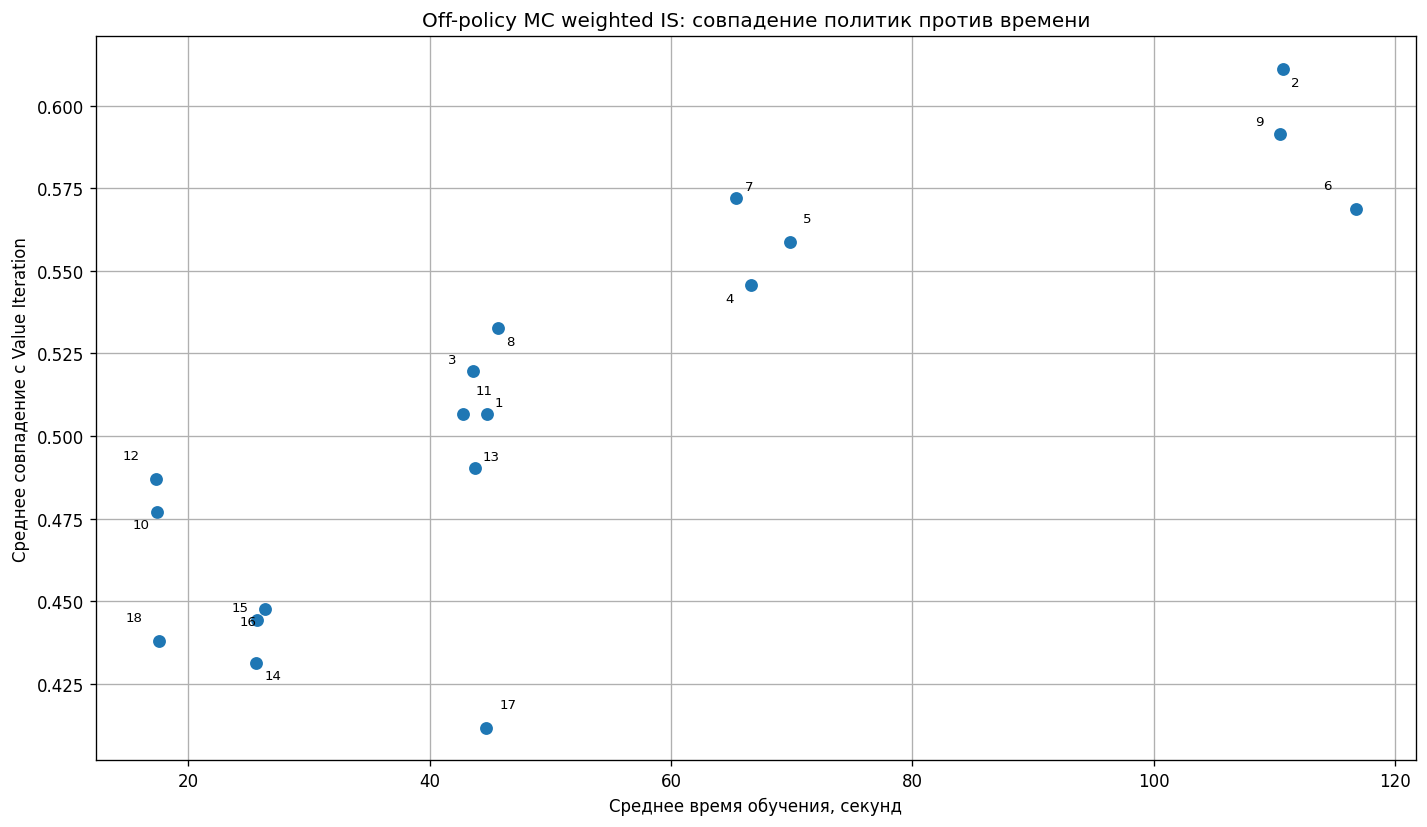

In [87]:
plt.figure(figsize=(12, 7), dpi=120)

plt.scatter(
    df_mc_weighted_grid_best["mean_training_time"],
    df_mc_weighted_grid_best["mean_policy_match"],
    s=45,
)

offsets = [
    (5, 5),
    (5, -10),
    (-15, 5),
    (-15, -10),
    (8, 12),
    (-20, 12),
]

for i, row in df_mc_weighted_grid_best.iterrows():
    dx, dy = offsets[i % len(offsets)]

    plt.annotate(
        str(int(row["rank"])),
        (
            row["mean_training_time"],
            row["mean_policy_match"],
        ),
        fontsize=8,
        xytext=(dx, dy),
        textcoords="offset points",
    )

plt.xlabel("Среднее время обучения, секунд")
plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Off-policy MC weighted IS: совпадение политик против времени")
plt.grid(True)
plt.tight_layout()
plt.show()

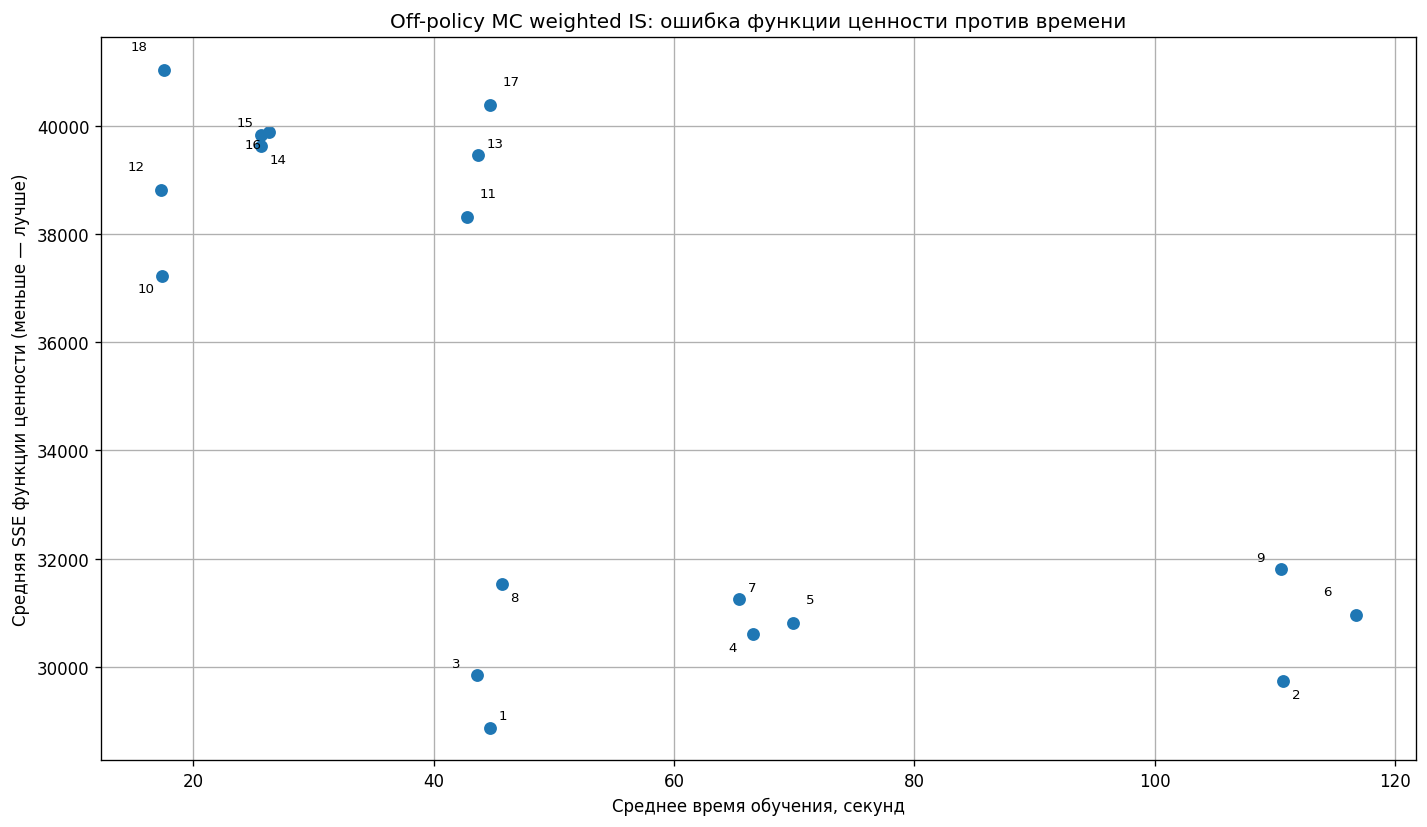

In [88]:
plt.figure(figsize=(12, 7), dpi=120)

plt.scatter(
    df_mc_weighted_grid_best["mean_training_time"],
    df_mc_weighted_grid_best["mean_value_sse"],
    s=45,
)

offsets = [
    (5, 5),
    (5, -10),
    (-15, 5),
    (-15, -10),
    (8, 12),
    (-20, 12),
]

for i, row in df_mc_weighted_grid_best.iterrows():
    dx, dy = offsets[i % len(offsets)]

    plt.annotate(
        str(int(row["rank"])),
        (
            row["mean_training_time"],
            row["mean_value_sse"],
        ),
        fontsize=8,
        xytext=(dx, dy),
        textcoords="offset points",
    )

plt.xlabel("Среднее время обучения, секунд")
plt.ylabel("Средняя SSE функции ценности (меньше — лучше)")
plt.title("Off-policy MC weighted IS: ошибка функции ценности против времени")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Вывод по грубому перебору параметров off-policy Monte Carlo

Для метода off-policy Monte Carlo с weighted importance sampling был проведён грубый перебор параметров `num_episodes`, `epsilon` и `max_steps`. Это было сделано для того, чтобы проверить, можно ли существенно улучшить качество метода за счёт выбора другой конфигурации параметров.

В качестве основной метрики качества использовалась ошибка функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

По результатам сортировки лучшей конфигурацией по основной метрике стала

$$
num\_episodes = 50000, \qquad
\varepsilon = 0.15, \qquad
max\_steps = 20.
$$

Для неё получено минимальное среднее значение ошибки функции ценности среди рассмотренных вариантов:

$$
mean\_value\_sse \approx 28874.12.
$$

Однако совпадение найденной стратегии с политикой Value Iteration остаётся низким:

$$
mean\_policy\_match \approx 0.507.
$$

Это означает, что даже при большом числе эпизодов метод плохо восстанавливает оптимальную стратегию.

Если ориентироваться только на совпадение стратегий, то лучший результат достигается при другой конфигурации:

$$
num\_episodes = 50000, \qquad
\varepsilon = 0.15, \qquad
max\_steps = 50.
$$

Для неё

$$
mean\_policy\_match \approx 0.611.
$$

При этом ошибка функции ценности остаётся большой:

$$
mean\_value\_sse \approx 29732.14.
$$

Кроме того, время обучения у лучших по качеству конфигураций остаётся достаточно большим. При увеличении длины эпизода время работы заметно возрастает, однако это не приводит к сопоставимому улучшению качества.

Значения $\mathrm{SSE}_V$ всё равно на несколько порядков хуже, чем у методов Monte Carlo с исследовательскими стартами и с единой $\varepsilon$-жадной политикой.

Полученный результат согласуется с проведённой диагностикой. Метод генерирует эпизоды по поведенческой политике, но оценивает жадную целевую политику. Из-за различия этих политик обратный проход часто обрывается, поэтому значительная часть собранной траектории не используется для обновления оценок $Q(s,a)$.

Таким образом, для данной задачи управления очередью метод off-policy Monte Carlo с weighted importance sampling оказался менее подходящим, чем Monte Carlo с исследовательскими стартами и Monte Carlo с единой $\varepsilon$-жадной политикой. Даже после грубого перебора параметров он даёт большую ошибку функции ценности и низкое совпадение с эталонной стратегией.

#### Итоговое сравнение методов Monte Carlo

После подбора параметров для каждого метода сравним лучшие найденные конфигурации между собой. В качестве эталона используется решение, найденное методом Value Iteration, поскольку этот метод использует известную модель среды и даёт оптимальную функцию ценности и оптимальную политику для построенной MDP.

Методы сравниваются по четырём критериям:

- средняя ошибка функции ценности относительно решения Value Iteration;
- среднее совпадение найденной политики с политикой Value Iteration;
- устойчивость результата при разных случайных запусках;
- среднее время обучения.

Основной метрикой качества является ошибка функции ценности

$$
\mathrm{SSE}_V =
\sum_{s \in S}
\left(
V_{\mathrm{MC}}(s) - V_*(s)
\right)^2.
$$

Чем меньше значение $\mathrm{SSE}_V$, тем ближе найденная методом Monte Carlo функция ценности к оптимальной функции ценности. 

Метрика совпадения политик используется как дополнительная:

$$
\mathrm{policy\_match}
=
\frac{1}{|S|}
\sum_{s \in S}
\mathbf{1}\{\pi_{\mathrm{MC}}(s)=\pi_*(s)\}.
$$

Она показывает, в какой доле состояний найденная политика выбирает то же действие, что и политика Value Iteration.

Такое сравнение позволяет оценить не только качество итоговой политики, но и точность приближения функции ценности, устойчивость метода и его вычислительную стоимость.

In [94]:
best_mc_es = df_mc_es_grid_best.iloc[0]
best_mc_eps = df_mc_eps_grid_best.iloc[0]
best_mc_weighted = df_mc_weighted_grid_best.iloc[0]

df_mc_methods_comparison = pd.DataFrame(
    [
        {
            "method": "MC Exploring Starts",
            "num_episodes": best_mc_es["num_episodes"],
            "alpha_lr": best_mc_es["alpha_lr"],
            "epsilon": np.nan,
            "max_steps": best_mc_es["max_steps"],
            "mean_value_sse": best_mc_es["mean_value_sse"],
            "std_value_sse": best_mc_es["std_value_sse"],
            "mean_policy_match": best_mc_es["mean_policy_match"],
            "std_policy_match": best_mc_es["std_policy_match"],
            "mean_training_time": best_mc_es["mean_training_time"],
        },
        {
            "method": "MC epsilon-greedy",
            "num_episodes": best_mc_eps["num_episodes"],
            "alpha_lr": best_mc_eps["alpha_lr"],
            "epsilon": best_mc_eps["epsilon"],
            "max_steps": best_mc_eps["max_steps"],
            "mean_value_sse": best_mc_eps["mean_value_sse"],
            "std_value_sse": best_mc_eps["std_value_sse"],
            "mean_policy_match": best_mc_eps["mean_policy_match"],
            "std_policy_match": best_mc_eps["std_policy_match"],
            "mean_training_time": best_mc_eps["mean_training_time"],
        },
        {
            "method": "Off-policy MC weighted IS",
            "num_episodes": best_mc_weighted["num_episodes"],
            "alpha_lr": np.nan,
            "epsilon": best_mc_weighted["epsilon"],
            "max_steps": best_mc_weighted["max_steps"],
            "mean_value_sse": best_mc_weighted["mean_value_sse"],
            "std_value_sse": best_mc_weighted["std_value_sse"],
            "mean_policy_match": best_mc_weighted["mean_policy_match"],
            "std_policy_match": best_mc_weighted["std_policy_match"],
            "mean_training_time": best_mc_weighted["mean_training_time"],
        },
    ]
)

In [95]:
df_mc_methods_comparison = (
    df_mc_methods_comparison
    .sort_values(
        by=[
            "mean_value_sse",
            "std_value_sse",
            "mean_policy_match",
            "mean_training_time",
        ],
        ascending=[True, True, False, True],
    )
    .reset_index(drop=True)
)

df_mc_methods_comparison["rank"] = range(
    1,
    len(df_mc_methods_comparison) + 1,
)

df_mc_methods_comparison[
    [
        "rank",
        "method",
        "num_episodes",
        "alpha_lr",
        "epsilon",
        "max_steps",
        "mean_value_sse",
        "std_value_sse",
        "mean_policy_match",
        "std_policy_match",
        "mean_training_time",
    ]
]

,rank,method,num_episodes,alpha_lr,epsilon,max_steps,mean_value_sse,std_value_sse,mean_policy_match,std_policy_match,mean_training_time
0,1,MC epsilon-greedy,3000,0.010,0.01,150,2.829255,0.738733,0.994118,0.009471,21.439281
1,2,MC Exploring Starts,3000,0.015,NaN,150,3.513783,0.762166,0.980392,0.000000,22.596611
2,3,Off-policy MC weighted IS,50000,NaN,0.15,20,28874.115527,1481.045147,0.506536,0.028862,44.727697


In [96]:
df_mc_methods_main = (
    df_mc_methods_comparison[
        df_mc_methods_comparison["method"].isin(
            [
                "MC Exploring Starts",
                "MC epsilon-greedy",
            ]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

df_mc_methods_main

,method,num_episodes,alpha_lr,epsilon,max_steps,mean_value_sse,std_value_sse,mean_policy_match,std_policy_match,mean_training_time,rank
0,MC epsilon-greedy,3000,0.010,0.01,150,2.829255,0.738733,0.994118,0.009471,21.439281,1
1,MC Exploring Starts,3000,0.015,NaN,150,3.513783,0.762166,0.980392,0.000000,22.596611,2


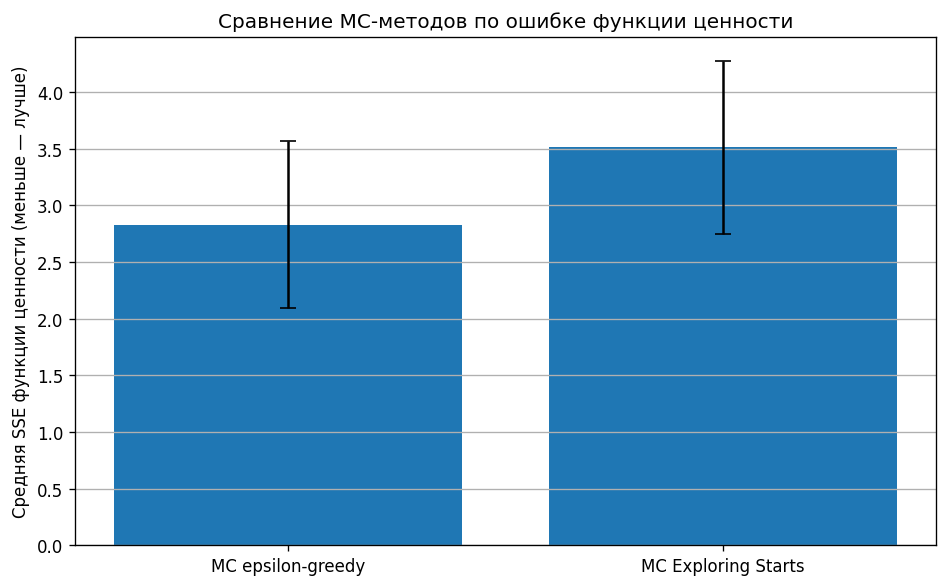

In [97]:
plt.figure(figsize=(8, 5), dpi=120)

plt.bar(
    df_mc_methods_main["method"],
    df_mc_methods_main["mean_value_sse"],
    yerr=df_mc_methods_main["std_value_sse"],
    capsize=5,
)

plt.ylabel("Средняя SSE функции ценности (меньше — лучше)")
plt.title("Сравнение MC-методов по ошибке функции ценности")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

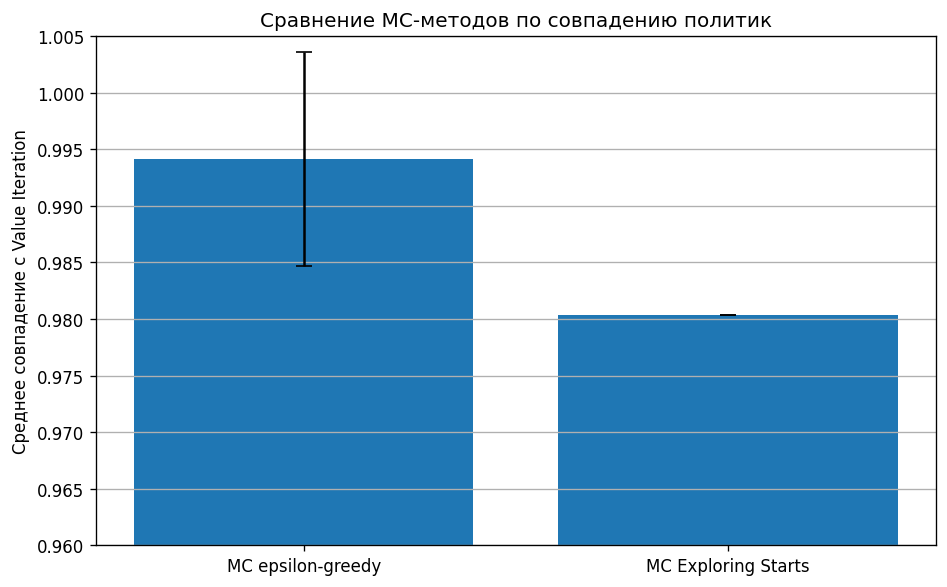

In [98]:
plt.figure(figsize=(8, 5), dpi=120)

plt.bar(
    df_mc_methods_main["method"],
    df_mc_methods_main["mean_policy_match"],
    yerr=df_mc_methods_main["std_policy_match"],
    capsize=5,
)

plt.ylim(0.96, 1.005)

plt.ylabel("Среднее совпадение с Value Iteration")
plt.title("Сравнение MC-методов по совпадению политик")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

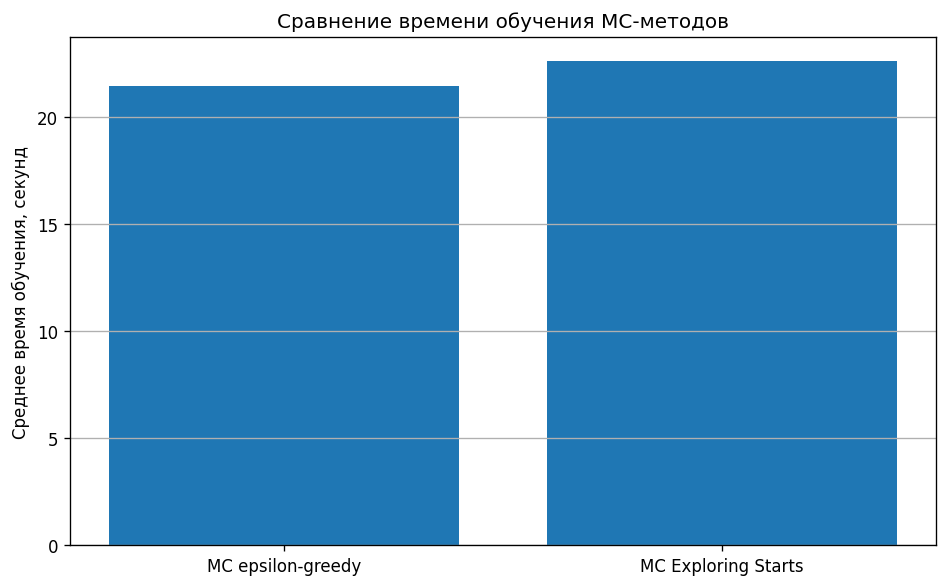

In [99]:
plt.figure(figsize=(8, 5), dpi=120)

plt.bar(
    df_mc_methods_main["method"],
    df_mc_methods_main["mean_training_time"],
)

plt.ylabel("Среднее время обучения, секунд")
plt.title("Сравнение времени обучения MC-методов")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

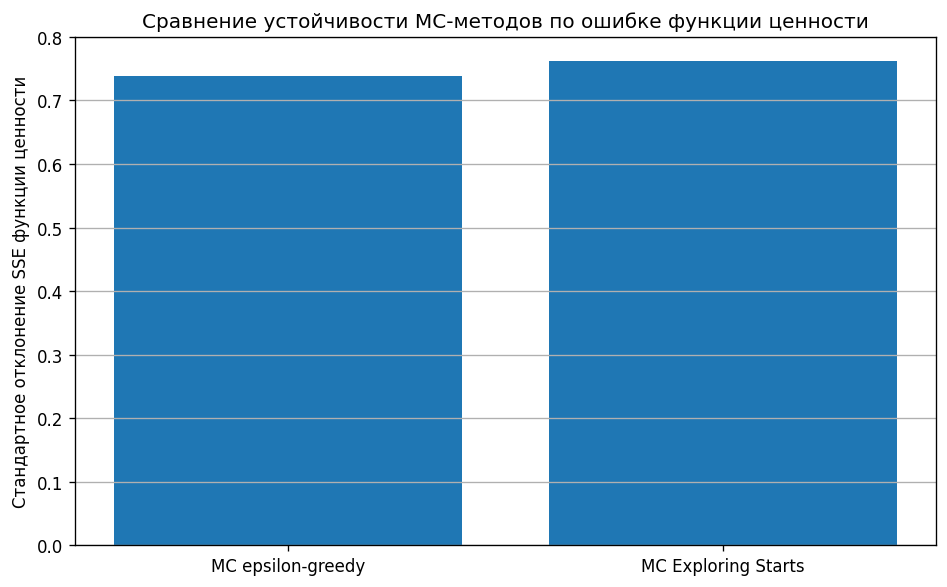

In [100]:
plt.figure(figsize=(8, 5), dpi=120)

plt.bar(
    df_mc_methods_main["method"],
    df_mc_methods_main["std_value_sse"],
)

plt.ylabel("Стандартное отклонение SSE функции ценности")
plt.title("Сравнение устойчивости MC-методов по ошибке функции ценности")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [101]:
mc_eps = df_mc_methods_comparison.loc[
    df_mc_methods_comparison["method"] == "MC epsilon-greedy"
].iloc[0]

mc_es = df_mc_methods_comparison.loc[
    df_mc_methods_comparison["method"] == "MC Exploring Starts"
].iloc[0]

sse_improvement = mc_es["mean_value_sse"] - mc_eps["mean_value_sse"]
sse_improvement_percent = (
    sse_improvement / mc_es["mean_value_sse"] * 100
)

policy_match_diff = (
    mc_eps["mean_policy_match"] - mc_es["mean_policy_match"]
)

time_diff = (
    mc_eps["mean_training_time"] - mc_es["mean_training_time"]
)

time_diff_percent = (
    time_diff / mc_es["mean_training_time"] * 100
)

print("Сравнение MC epsilon-greedy с MC Exploring Starts")
print("-" * 60)
print(f"Уменьшение средней ошибки SSE: {sse_improvement:.5f}")
print(
    "Относительное уменьшение ошибки SSE, %: "
    f"{sse_improvement_percent:.2f}"
)
print(f"Разница в совпадении политик: {policy_match_diff:.5f}")
print(f"Разница во времени обучения, секунд: {time_diff:.3f}")
print(f"Относительная разница времени, %: {time_diff_percent:.2f}")

Сравнение MC epsilon-greedy с MC Exploring Starts
------------------------------------------------------------
Уменьшение средней ошибки SSE: 0.68453
Относительное уменьшение ошибки SSE, %: 19.48
Разница в совпадении политик: 0.01373
Разница во времени обучения, секунд: -1.157
Относительная разница времени, %: -5.12


#### Вывод по итоговому сравнению методов Monte Carlo

Итоговое сравнение показало, что метод off-policy Monte Carlo с weighted importance sampling существенно уступает двум другим методам. Его средняя ошибка функции ценности составила

$$
mean\_value\_sse \approx 28874.12,
$$

а среднее совпадение найденной политики с политикой Value Iteration равно только

$$
mean\_policy\_match \approx 0.507.
$$

Это означает, что метод с разделёнными политиками восстанавливает эталонную политику только примерно в половине состояний. При этом ошибка функции ценности у него на несколько порядков больше, чем у двух других методов Monte Carlo. Поэтому данный метод был исследован, но для рассматриваемой задачи управления очередью оказался практически непригодным.

Далее были отдельно сравнены два метода, показавшие хорошее качество: Monte Carlo с исследовательскими стартами и Monte Carlo с единой $\varepsilon$-жадной политикой.

По основной метрике $\mathrm{SSE}_V$ лучший результат показал метод Monte Carlo с единой $\varepsilon$-жадной политикой. Для него средняя ошибка функции ценности составила

$$
mean\_value\_sse \approx 2.83.
$$

Для метода Monte Carlo с исследовательскими стартами ошибка оказалась немного больше:

$$
mean\_value\_sse \approx 3.51.
$$

Таким образом, метод MC $\varepsilon$-greedy уменьшает среднюю ошибку функции ценности примерно на

$$
0.6845,
$$

что соответствует относительному уменьшению ошибки примерно на

$$
19.48\%.
$$

По дополнительной метрике совпадения политик метод MC $\varepsilon$-greedy также оказался лучше. Для него

$$
mean\_policy\_match \approx 0.994,
$$

тогда как для метода MC Exploring Starts:

$$
mean\_policy\_match \approx 0.980.
$$

Это означает, что $\varepsilon$-жадный метод чаще выбирает те же действия, что и оптимальная политика, найденная методом Value Iteration.

По времени обучения метод MC $\varepsilon$-greedy также оказался немного лучше. Его среднее время обучения составило примерно

$$
21.44
$$

секунды, а для метода MC Exploring Starts:

$$
22.60
$$

секунды. Разница составляет около

$$
1.16
$$

секунды, то есть примерно

$$
5.12\%.
$$

По устойчивости результаты двух методов близки. Стандартное отклонение ошибки функции ценности у метода MC $\varepsilon$-greedy немного меньше:

$$
std\_value\_sse \approx 0.739,
$$

а у MC Exploring Starts:

$$
std\_value\_sse \approx 0.762.
$$

Следовательно, по основной метрике, по совпадению политик, по времени обучения и по устойчивости относительно ошибки функции ценности лучшим среди рассмотренных методов оказался Monte Carlo с единой $\varepsilon$-жадной политикой.

Таким образом, для данной задачи управления очередью итоговым выбранным методом является Monte Carlo с единой $\varepsilon$-жадной политикой с параметрами

$$
num\_episodes = 3000, \qquad
\alpha = 0.01, \qquad
\varepsilon = 0.01, \qquad
max\_steps = 150.
$$

Этот метод лучше всего приближает оптимальную функцию ценности, почти полностью совпадает с политикой Value Iteration и при этом не требует большего времени обучения по сравнению с методом Monte Carlo с исследовательскими стартами.